# Ergebnis- und Diskussionsanalyse fuer die H/k-Agentenexperimente

Dieses Notebook ist als auswertungsnahe Grundlage fuer das Kapitel `Ergebnisse` sowie den anschliessenden Abschnitt `Diskussion und Limitationen` gedacht. Es baut auf `notebooks/final_analysis.ipynb` und der Hard-Subset-EDA aus `notebooks/Archiv/11_webarena_verified_hard_eda.ipynb` auf, fasst die Versuchsdaten aber entlang der Thesis-Gliederung neu zusammen. Die Zellen erzeugen Tabellen, Grafiken und kurze datenbasierte Textbausteine, die nach Ausfuehrung des Notebooks in den Ergebnisteil uebernommen werden koennen.



In [1]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except Exception as exc:  # pragma: no cover - notebook convenience
    plt = None
    warnings.warn(f"Matplotlib unavailable: {exc}")

try:
    import seaborn as sns
except Exception as exc:  # pragma: no cover - notebook convenience
    sns = None
    warnings.warn(f"Seaborn unavailable: {exc}")

from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

EXPERIMENT_NAME = "hk-agent-browsergym-planact-main-v02_basis_v3"
SUMMARY_PATH = ROOT / "runs" / "hk-agent" / EXPERIMENT_NAME / "summary.csv"
SUMMARY_JSON_PATH = ROOT / "runs" / "hk-agent" / EXPERIMENT_NAME / "summary.json"
DATASET_PATH = ROOT / "external" / "webarena-verified" / "assets" / "dataset" / "webarena-verified.json"
HARD_SUBSET_PATH = ROOT / "external" / "webarena-verified" / "assets" / "dataset" / "webarna-verfied-hard.json"

# Kostenannahmen fuer den API-Kostenproxy. Vor finaler Abgabe gegen die aktuelle Google/Vertex-Preisseite pruefen.
INPUT_PRICE_PER_1M_USD = 0.15
OUTPUT_PRICE_PER_1M_USD = 0.60
CACHE_HIT_PRICE_PER_1M_USD = 0.015
CACHE_HIT_RATE = 0.0

PREFERRED_HK_ORDER = [0, 2, 5, 10]
SITE_ORDER = ["gitlab", "reddit", "shopping", "shopping_admin", "wikipedia", "map"]
TASK_TYPE_ORDER = ["NAVIGATE", "RETRIEVE", "MUTATE", "POLICY", "NETWORK_OR_UI", "UNKNOWN"]

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 240)
pd.set_option("display.width", 240)

if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Summary not found: {SUMMARY_PATH}")

def as_bool(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series.fillna(False)
    return series.astype(str).str.lower().isin({"true", "1", "yes", "success"})

def hk_label(h: Any, k: Any) -> str:
    return f"h{int(h)}/k{int(k)}"

def hk_sort_key(label: str) -> tuple[int, int]:
    h_part, k_part = label.replace("h", "").split("/k")
    return int(h_part), int(k_part)

def intent_bucket_from_length(length: int) -> str:
    if length < 60:
        return "short"
    if length < 140:
        return "medium"
    return "long"

def infer_dataset_task_type(task: dict[str, Any]) -> str:
    values = []
    for evaluator in task.get("eval", []) or []:
        expected = evaluator.get("expected", {}) or {}
        if expected.get("task_type"):
            values.append(str(expected["task_type"]).upper())
    if values:
        return "+".join(sorted(set(values)))
    if task.get("eval"):
        return "NETWORK_OR_UI"
    return "UNKNOWN"

def load_task_metadata() -> pd.DataFrame:
    if not DATASET_PATH.exists():
        warnings.warn(f"Dataset not found: {DATASET_PATH}")
        return pd.DataFrame()
    dataset = json.loads(DATASET_PATH.read_text(encoding="utf-8"))
    hard_ids = set()
    if HARD_SUBSET_PATH.exists():
        hard_info = json.loads(HARD_SUBSET_PATH.read_text(encoding="utf-8"))
        if isinstance(hard_info, dict):
            raw_ids = hard_info.get("task_ids", [])
        elif isinstance(hard_info, list):
            raw_ids = [row.get("task_id") if isinstance(row, dict) else row for row in hard_info]
        else:
            raw_ids = []
        hard_ids = {int(task_id) for task_id in raw_ids if task_id is not None}
    rows = []
    for task in dataset:
        task_id = int(task.get("task_id"))
        sites = task.get("sites") or []
        intent = str(task.get("intent") or "")
        rows.append({
            "task_id": task_id,
            "dataset_sites": sites,
            "dataset_site": sites[0] if len(sites) == 1 else "+".join(sites),
            "dataset_task_type": infer_dataset_task_type(task),
            "intent": intent,
            "intent_length": len(intent),
            "intent_word_count": len(intent.split()),
            "intent_bucket": intent_bucket_from_length(len(intent)),
            "hard_subset": task_id in hard_ids,
            "single_site": len(sites) == 1,
            "evaluator_names": "+".join(e.get("evaluator", "") for e in task.get("eval", []) or []),
        })
    return pd.DataFrame(rows)

def load_eval_df() -> pd.DataFrame:
    df = pd.read_csv(SUMMARY_PATH)
    df["success"] = as_bool(df.get("official_success", pd.Series(False, index=df.index)))
    df["official_success_bool"] = df["success"]
    df["h"] = pd.to_numeric(df["h"], errors="coerce").fillna(-1).astype(int)
    df["k"] = pd.to_numeric(df["k"], errors="coerce").fillna(-1).astype(int)
    df["hk"] = [hk_label(h, k) for h, k in zip(df["h"], df["k"])]
    df["hk_sort"] = list(zip(df["h"], df["k"]))
    for col in [
        "total_tokens", "prompt_tokens", "completion_tokens", "planner_tokens", "executor_tokens",
        "total_runtime_ms", "planner_calls", "executor_calls", "runtime_replans",
        "runtime_no_progress_events", "runtime_invalid_actions", "runtime_loop_events", "total_steps",
    ]:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df["total_runtime_s"] = df["total_runtime_ms"] / 1000.0
    df["task_type"] = df.get("task_type", "UNKNOWN").fillna("UNKNOWN").astype(str).str.upper()
    meta = load_task_metadata()
    if not meta.empty:
        df = df.merge(meta.drop(columns=["intent"], errors="ignore"), on="task_id", how="left")
        df["summary_task_type"] = df["task_type"]
        df["task_type"] = df["dataset_task_type"].fillna(df["summary_task_type"]).astype(str).str.upper()
    else:
        df["intent_length"] = df.get("intent", "").fillna("").astype(str).str.len()
        df["intent_word_count"] = df.get("intent", "").fillna("").astype(str).str.split().str.len()
        df["intent_bucket"] = df["intent_length"].map(intent_bucket_from_length)
    return df



def read_jsonl_file(path: Path) -> list[dict[str, Any]]:
    if not path.exists():
        return []
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            value = json.loads(line)
            if isinstance(value, dict):
                rows.append(value)
        except json.JSONDecodeError:
            continue
    return rows

def output_dir_path(value: Any) -> Path | None:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    path = Path(str(value))
    if not path.is_absolute():
        path = ROOT / path
    return path

def bootstrap_task_success_ci(df: pd.DataFrame, group_cols: list[str], n_boot: int = 1000, seed: int = 42) -> pd.DataFrame:
    """Task-level bootstrap CIs for success rates, preserving paired run blocks per task."""
    rng = np.random.default_rng(seed)
    tasks = df["task_id"].dropna().unique()
    if len(tasks) == 0:
        return pd.DataFrame()
    observed = df.groupby(group_cols)["success"].mean().rename("success_rate").reset_index()
    boot_values: dict[tuple, list[float]] = {}
    by_task = {task_id: group for task_id, group in df.groupby("task_id")}
    for _ in range(n_boot):
        sampled_tasks = rng.choice(tasks, size=len(tasks), replace=True)
        sample = pd.concat([by_task[task_id] for task_id in sampled_tasks], ignore_index=True)
        rates = sample.groupby(group_cols)["success"].mean()
        for key, value in rates.items():
            if not isinstance(key, tuple):
                key = (key,)
            boot_values.setdefault(key, []).append(float(value))
    rows = []
    for _, row in observed.iterrows():
        key = tuple(row[col] for col in group_cols)
        values = boot_values.get(key, [])
        rows.append({
            **{col: row[col] for col in group_cols},
            "success_rate": row["success_rate"],
            "ci_low": float(np.quantile(values, 0.025)) if values else np.nan,
            "ci_high": float(np.quantile(values, 0.975)) if values else np.nan,
        })
    return pd.DataFrame(rows)

summary_df = load_eval_df()
experiment_info = json.loads(SUMMARY_JSON_PATH.read_text(encoding="utf-8")) if SUMMARY_JSON_PATH.exists() else {}

ordered_hks = sorted(summary_df["hk"].dropna().unique(), key=hk_sort_key)
print(f"Loaded {len(summary_df):,} rows from {SUMMARY_PATH.relative_to(ROOT)}")
print(f"Treatments: {', '.join(ordered_hks)}")
print(f"Tasks: {summary_df['task_id'].nunique()} | Sites: {summary_df['site'].nunique()}")


Loaded 3,360 rows from runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/summary.csv
Treatments: h0/k0, h0/k2, h0/k5, h0/k10, h2/k0, h2/k2, h2/k5, h2/k10, h5/k0, h5/k2, h5/k5, h5/k10, h10/k0, h10/k2, h10/k5, h10/k10
Tasks: 210 | Sites: 4


/var/folders/k3/z_svrdgd6sb9lc9bqdfzp_k00000gn/T/ipykernel_55630/3072439186.py:22: UserWarning: Seaborn unavailable: No module named 'seaborn'
  warnings.warn(f"Seaborn unavailable: {exc}")


## Überblick über die Versuchsdaten

Dieser Abschnitt beschreibt die empirische Basis der Auswertung: Anzahl der Runs, Tasks, Treatments, Sites, Tasktypen und Intent-Laengen. Die aus der Hard-EDA uebernommene Kategorisierung nutzt die offizielle Taskdefinition, insbesondere die Evaluator-Metadaten fuer Tasktyp und die Intent-Laenge fuer `short`, `medium` und `long`.



In [2]:
overview = pd.DataFrame([
    {"Kennzahl": "Experiment", "Wert": EXPERIMENT_NAME},
    {"Kennzahl": "Runs / Zeilen", "Wert": len(summary_df)},
    {"Kennzahl": "Eindeutige Tasks", "Wert": summary_df["task_id"].nunique()},
    {"Kennzahl": "Treatments H/k", "Wert": summary_df["hk"].nunique()},
    {"Kennzahl": "Sites", "Wert": summary_df["site"].nunique()},
    {"Kennzahl": "Globale Success Rate", "Wert": f"{summary_df['success'].mean():.1%}"},
    {"Kennzahl": "Median Tokens pro Run", "Wert": f"{summary_df['total_tokens'].median():,.0f}"},
    {"Kennzahl": "Median Laufzeit pro Run", "Wert": f"{summary_df['total_runtime_s'].median():,.1f} s"},
])
display(overview)

baseline_vs_hk_adjusted = summary_df.assign(
    treatment_group=np.where(summary_df["hk"].eq("h0/k0"), "Baseline h0/k0", "H/k-Anpassungen (alle anderen)")
).groupby("treatment_group").agg(
    runs=("task_id", "count"),
    tasks=("task_id", "nunique"),
    treatments=("hk", "nunique"),
    success_rate=("success", "mean"),
    mean_tokens=("total_tokens", "mean"),
    median_tokens=("total_tokens", "median"),
    mean_runtime_s=("total_runtime_s", "mean"),
    median_runtime_s=("total_runtime_s", "median"),
    mean_steps=("total_steps", "mean"),
    mean_planner_calls=("planner_calls", "mean"),
    mean_executor_calls=("executor_calls", "mean"),
    mean_runtime_replans=("runtime_replans", "mean"),
).reset_index()
baseline_vs_hk_adjusted["success_rate_pct"] = baseline_vs_hk_adjusted["success_rate"] * 100
baseline_vs_hk_adjusted = baseline_vs_hk_adjusted.sort_values("treatment_group", ascending=False)
display(baseline_vs_hk_adjusted)

def hk_configuration_group(row: pd.Series) -> str:
    h_value = int(row["h"])
    k_value = int(row["k"])
    if h_value == 0 and k_value == 0:
        return "H_P=0, k=0"
    if h_value == 0 and k_value > 0:
        return "H_P=0, k>0"
    if h_value > 0 and k_value == 0:
        return "H_P>0, k=0"
    return "H_P>0, k>0"

configuration_order = ["H_P=0, k=0", "H_P=0, k>0", "H_P>0, k=0", "H_P>0, k>0"]
configuration_meaning = {
    "H_P=0, k=0": "Full-Horizon, keine planmaessige Pruefung",
    "H_P=0, k>0": "Full-Horizon mit planmaessiger Pruefung",
    "H_P>0, k=0": "begrenzter Planungshorizont ohne planmaessige Pruefung",
    "H_P>0, k>0": "begrenzter Planungshorizont mit planmaessiger Pruefung",
}

configuration_groups = summary_df.assign(configuration=summary_df.apply(hk_configuration_group, axis=1))
configuration_success = (
    configuration_groups.groupby("configuration")
    .agg(
        runs=("task_id", "count"),
        tasks=("task_id", "nunique"),
        treatments=("hk", "nunique"),
        success_rate=("success", "mean"),
        mean_tokens=("total_tokens", "mean"),
        median_tokens=("total_tokens", "median"),
        mean_runtime_s=("total_runtime_s", "mean"),
        median_runtime_s=("total_runtime_s", "median"),
        mean_planner_calls=("planner_calls", "mean"),
        mean_executor_calls=("executor_calls", "mean"),
        mean_runtime_replans=("runtime_replans", "mean"),
    )
    .reindex(configuration_order)
    .reset_index()
)
configuration_success["Bedeutung"] = configuration_success["configuration"].map(configuration_meaning)
configuration_success["success_rate_pct"] = configuration_success["success_rate"] * 100
configuration_success = configuration_success[[
    "configuration", "Bedeutung", "runs", "tasks", "treatments", "success_rate", "success_rate_pct",
    "mean_tokens", "median_tokens", "mean_runtime_s", "median_runtime_s",
    "mean_planner_calls", "mean_executor_calls", "mean_runtime_replans",
]]
display(configuration_success)

by_site_type = (
    summary_df.groupby(["site", "task_type"], dropna=False)
    .agg(runs=("task_id", "count"), tasks=("task_id", "nunique"), success_rate=("success", "mean"))
    .reset_index()
    .sort_values(["site", "task_type"])
)
by_site_type["success_rate_pct"] = by_site_type["success_rate"] * 100
display(by_site_type)

bucket_table = pd.crosstab(summary_df["site"], summary_df["intent_bucket"], values=summary_df["task_id"], aggfunc="nunique").fillna(0).astype(int)
display(bucket_table)

intent_bucket_success = (
    summary_df.groupby(["intent_bucket"], dropna=False)
    .agg(
        runs=("task_id", "count"),
        tasks=("task_id", "nunique"),
        mean_intent_length=("intent_length", "mean"),
        mean_intent_word_count=("intent_word_count", "mean"),
        success_rate=("success", "mean"),
    )
    .reset_index()
    .sort_values("mean_intent_length")
)
intent_bucket_success["success_rate_pct"] = intent_bucket_success["success_rate"] * 100
display(intent_bucket_success)

intent_bucket_by_hk = (
    summary_df.groupby(["intent_bucket", "h", "k", "hk"], dropna=False)
    .agg(runs=("task_id", "count"), tasks=("task_id", "nunique"), success_rate=("success", "mean"))
    .reset_index()
    .sort_values(["intent_bucket", "h", "k"])
)
intent_bucket_by_hk["success_rate_pct"] = intent_bucket_by_hk["success_rate"] * 100
display(intent_bucket_by_hk)

display(Markdown(
    f"""
**Textbaustein.** Die Auswertung basiert auf `{len(summary_df):,}` Run-Zeilen aus dem Experiment `{EXPERIMENT_NAME}`.
Diese umfassen `{summary_df['task_id'].nunique()}` eindeutige Tasks, `{summary_df['hk'].nunique()}` H/k-Treatments und `{summary_df['site'].nunique()}` Webanwendungen.
Die globale Task Success Rate liegt bei `{summary_df['success'].mean():.1%}`. Ergaenzend kontrastiert die zweite Tabelle die Baseline `h0/k0` mit allen Treatment-Kombinationen, in denen mindestens eine H/k-Anpassung aktiv ist. Die dritte Tabelle fasst die Treatments zudem in vier konzeptionelle Konfigurationsgruppen zusammen: Full-Horizon ohne Pruefung, Full-Horizon mit Pruefung, begrenzter Horizont ohne Pruefung und begrenzter Horizont mit Pruefung. Die Verteilung nach Site, Tasktyp und Intent-Laenge wird anschliessend deskriptiv ausgewiesen; die Intent-Laenge wird dabei nicht als eigenstaendige Hauptmetrik interpretiert.
""".strip()
))


,Kennzahl,Wert
0,Experiment,hk-agent-browsergym-planact-main-v02_basis_v3
1,Runs / Zeilen,3360
2,Eindeutige Tasks,210
3,Treatments H/k,16
4,Sites,4
5,Globale Success Rate,22.9%
6,Median Tokens pro Run,"302,172"
7,Median Laufzeit pro Run,124.5 s


,treatment_group,runs,tasks,treatments,success_rate,mean_tokens,median_tokens,mean_runtime_s,median_runtime_s,mean_steps,mean_planner_calls,mean_executor_calls,mean_runtime_replans,success_rate_pct
1,H/k-Anpassungen (alle anderen),3150,210,15,0.241587,729527.880000,369383.5,269.821784,147.6780,21.122222,6.847619,16.863175,5.194603,24.158730
0,Baseline h0/k0,210,210,1,0.042857,113106.528571,107802.0,60.247648,44.5525,4.066667,1.519048,3.252381,0.519048,4.285714


,configuration,Bedeutung,runs,tasks,treatments,success_rate,success_rate_pct,mean_tokens,median_tokens,mean_runtime_s,median_runtime_s,mean_planner_calls,mean_executor_calls,mean_runtime_replans
0,"H_P=0, k=0","Full-Horizon, keine planmaessige Pruefung",210,210,1,0.042857,4.285714,113106.528571,107802.0,60.247648,44.5525,1.519048,3.252381,0.519048
1,"H_P=0, k>0",Full-Horizon mit planmaessiger Pruefung,630,210,3,0.260317,26.031746,754253.731746,460546.5,287.020313,161.4935,6.519048,17.458730,5.576190
2,"H_P>0, k=0",begrenzter Planungshorizont ohne planmaessige Pruefung,630,210,3,0.131746,13.174603,366253.536508,138400.5,145.214211,56.7860,5.269841,8.665079,1.484127
3,"H_P>0, k>0",begrenzter Planungshorizont mit planmaessiger Pruefung,1890,210,9,0.271958,27.195767,842377.377249,600713.0,305.624798,222.1885,7.483069,19.397354,6.304233


,site,task_type,runs,tasks,success_rate,success_rate_pct
0,gitlab,MUTATE,576,36,0.182292,18.229167
1,gitlab,NAVIGATE,96,6,0.531250,53.125000
2,gitlab,RETRIEVE,240,15,0.141667,14.166667
3,reddit,MUTATE,576,36,0.484375,48.437500
4,reddit,RETRIEVE,96,6,0.343750,34.375000
5,shopping,MUTATE,336,21,0.226190,22.619048
6,shopping,NAVIGATE,160,10,0.406250,40.625000
7,shopping,RETRIEVE,400,25,0.035000,3.500000
8,shopping_admin,MUTATE,416,26,0.098558,9.855769
9,shopping_admin,NAVIGATE,96,6,0.447917,44.791667


intent_bucket,long,medium,short
site,,,
gitlab,15,29,13
reddit,13,22,7
shopping,18,29,9
shopping_admin,15,24,16


,intent_bucket,runs,tasks,mean_intent_length,mean_intent_word_count,success_rate,success_rate_pct
2,short,720,45,45.977778,8.844444,0.315278,31.527778
1,medium,1664,104,97.259615,17.028846,0.230168,23.016827
0,long,976,61,188.967213,32.311475,0.163934,16.393443


,intent_bucket,h,k,hk,runs,tasks,success_rate,success_rate_pct
0,long,0,0,h0/k0,61,61,0.032787,3.278689
1,long,0,2,h0/k2,61,61,0.163934,16.393443
2,long,0,5,h0/k5,61,61,0.196721,19.672131
3,long,0,10,h0/k10,61,61,0.163934,16.393443
4,long,2,0,h2/k0,61,61,0.163934,16.393443
5,long,2,2,h2/k2,61,61,0.196721,19.672131
6,long,2,5,h2/k5,61,61,0.213115,21.311475
7,long,2,10,h2/k10,61,61,0.229508,22.950820
8,long,5,0,h5/k0,61,61,0.049180,4.918033
9,long,5,2,h5/k2,61,61,0.180328,18.032787


**Textbaustein.** Die Auswertung basiert auf `3,360` Run-Zeilen aus dem Experiment `hk-agent-browsergym-planact-main-v02_basis_v3`.
Diese umfassen `210` eindeutige Tasks, `16` H/k-Treatments und `4` Webanwendungen.
Die globale Task Success Rate liegt bei `22.9%`. Ergaenzend kontrastiert die zweite Tabelle die Baseline `h0/k0` mit allen Treatment-Kombinationen, in denen mindestens eine H/k-Anpassung aktiv ist. Die dritte Tabelle fasst die Treatments zudem in vier konzeptionelle Konfigurationsgruppen zusammen: Full-Horizon ohne Pruefung, Full-Horizon mit Pruefung, begrenzter Horizont ohne Pruefung und begrenzter Horizont mit Pruefung. Die Verteilung nach Site, Tasktyp und Intent-Laenge wird anschliessend deskriptiv ausgewiesen; die Intent-Laenge wird dabei nicht als eigenstaendige Hauptmetrik interpretiert.

## Vollstaendigkeit, Evaluatorstatus und balanciertes Design

Vor der Interpretation der Treatment-Unterschiede wird geprueft, ob alle geplanten Kombinationen aus Task und Treatment vorliegen und ob die offiziellen Evaluatorstatus verwertbar sind. Diese Kontrolle ist wichtig, weil die spaeteren gepaarten Vergleiche voraussetzen, dass dieselben Tasks in allen Treatments enthalten sind.



In [3]:
expected_treatments = summary_df[["h", "k", "hk"]].drop_duplicates().sort_values(["h", "k"])
expected_num_treatments = len(expected_treatments)

task_treatment_counts = (
    summary_df.groupby("task_id")
    .agg(
        observed_treatments=("hk", "nunique"),
        runs=("hk", "count"),
        site=("site", "first"),
        task_type=("task_type", "first"),
        intent_bucket=("intent_bucket", "first"),
    )
    .reset_index()
)
task_treatment_counts["complete_16_treatments"] = task_treatment_counts["observed_treatments"].eq(expected_num_treatments)

evaluator_status = (
    summary_df.groupby(["official_eval_status"], dropna=False)
    .agg(runs=("task_id", "count"), success_rate=("success", "mean"))
    .reset_index()
    .sort_values("runs", ascending=False)
)

completeness = pd.DataFrame([
    {"Kennzahl": "Erwartete Treatments", "Wert": expected_num_treatments},
    {"Kennzahl": "Tasks mit vollstaendiger Treatmentabdeckung", "Wert": int(task_treatment_counts["complete_16_treatments"].sum())},
    {"Kennzahl": "Tasks mit fehlenden Treatments", "Wert": int((~task_treatment_counts["complete_16_treatments"]).sum())},
    {"Kennzahl": "Minimum Treatments pro Task", "Wert": int(task_treatment_counts["observed_treatments"].min())},
    {"Kennzahl": "Maximum Treatments pro Task", "Wert": int(task_treatment_counts["observed_treatments"].max())},
])
display(completeness)
display(evaluator_status)

evaluator_status_success_crosstab = pd.crosstab(
    summary_df["official_eval_status"].fillna("missing"),
    summary_df["success"],
    margins=True,
)
evaluator_status_success_crosstab.columns = ["not_success" if col is False else "success" if col is True else col for col in evaluator_status_success_crosstab.columns]
display(evaluator_status_success_crosstab)

official_success_total = int(summary_df["success"].sum())
status_success_total = int(summary_df["official_eval_status"].fillna("missing").eq("success").sum())
status_failure_but_success_total = int((summary_df["success"] & summary_df["official_eval_status"].fillna("missing").eq("failure")).sum())

non_success_status_successes = summary_df[
    summary_df["success"]
    & ~summary_df["official_eval_status"].fillna("missing").eq("success")
]
if not non_success_status_successes.empty:
    display(
        non_success_status_successes[[
            "task_id", "site", "task_type", "hk", "official_eval_status",
            "failure_category", "near_miss_score", "output_dir",
        ]].sort_values(["official_eval_status", "site", "task_id", "hk"])
    )

missing_design = task_treatment_counts[~task_treatment_counts["complete_16_treatments"]]
if not missing_design.empty:
    display(missing_design.sort_values("observed_treatments"))

display(Markdown(
    f"""
**Textbaustein.** Fuer `{int(task_treatment_counts['complete_16_treatments'].sum())}` von `{len(task_treatment_counts)}` Tasks liegen alle `{expected_num_treatments}` Treatments vor.
Damit kann die Auswertung die gepaarte Struktur des Experiments nutzen: Treatment-Unterschiede werden auf denselben Tasks beobachtet und sind nicht nur Unterschiede zwischen unabhaengigen Stichproben.
Insgesamt sind `{official_success_total}` Laeufe im finalen Ergebnisfeld `official_success` als erfolgreich gekennzeichnet. Der technische bzw. rohe Evaluatorstatus `success` tritt `{status_success_total}`-mal auf; `{status_failure_but_success_total}` Laeufe haben dagegen `official_eval_status = failure`, aber `official_success = true`. Diese Abweichung wird separat angezeigt und muss in der finalen Methodik als Status-/Bewertungssemantik, nachtraegliche Korrektur oder Datenbereinigungsregel dokumentiert werden; bis dahin sollte nicht geschrieben werden, dass alle `{official_success_total}` Erfolge den Evaluatorstatus `success` besitzen.
""".strip()
))


,Kennzahl,Wert
0,Erwartete Treatments,16
1,Tasks mit vollstaendiger Treatmentabdeckung,210
2,Tasks mit fehlenden Treatments,0
3,Minimum Treatments pro Task,16
4,Maximum Treatments pro Task,16


,official_eval_status,runs,success_rate
1,failure,2611,0.013405
2,success,735,1.000000
0,error,11,0.000000
3,NaN,3,0.000000


,not_success,success,All
official_eval_status,,,
error,11,0,11
failure,2576,35,2611
missing,3,0,3
success,0,735,735
All,2590,770,3360


,task_id,site,task_type,hk,official_eval_status,failure_category,near_miss_score,output_dir
1157,615,reddit,MUTATE,h2/k2,failure,official_success,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/615/h2_k2/615
1158,615,reddit,MUTATE,h2/k5,failure,official_success,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/615/h2_k5/615
1163,615,reddit,MUTATE,h5/k10,failure,official_success,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/615/h5_k10/615
1171,617,reddit,MUTATE,h0/k10,failure,official_success,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/617/h0_k10/617
1169,617,reddit,MUTATE,h0/k2,failure,official_success,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/617/h0_k2/617
1170,617,reddit,MUTATE,h0/k5,failure,official_success,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/617/h0_k5/617
1183,617,reddit,MUTATE,h10/k10,failure,official_success,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/617/h10_k10/617
1182,617,reddit,MUTATE,h10/k5,failure,official_success,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/617/h10_k5/617
1172,617,reddit,MUTATE,h2/k0,failure,official_success,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/617/h2_k0/617
1175,617,reddit,MUTATE,h2/k10,failure,official_success,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-agent/hk-agent-browsergym-planact-main-v02_basis_v3/reddit/617/h2_k10/617


**Textbaustein.** Fuer `210` von `210` Tasks liegen alle `16` Treatments vor.
Damit kann die Auswertung die gepaarte Struktur des Experiments nutzen: Treatment-Unterschiede werden auf denselben Tasks beobachtet und sind nicht nur Unterschiede zwischen unabhaengigen Stichproben.
Insgesamt sind `770` Laeufe im finalen Ergebnisfeld `official_success` als erfolgreich gekennzeichnet. Der technische bzw. rohe Evaluatorstatus `success` tritt `735`-mal auf; `35` Laeufe haben dagegen `official_eval_status = failure`, aber `official_success = true`. Diese Abweichung wird separat angezeigt und muss in der finalen Methodik als Status-/Bewertungssemantik, nachtraegliche Korrektur oder Datenbereinigungsregel dokumentiert werden; bis dahin sollte nicht geschrieben werden, dass alle `770` Erfolge den Evaluatorstatus `success` besitzen.

## Marginale Success Rates nach H und k

Neben der vollstaendigen Treatmentmatrix sind marginale Success Rates hilfreich. Sie zeigen, wie sich der Planungshorizont `H` im Mittel ueber alle `k`-Werte und wie sich das Kontrollintervall `k` im Mittel ueber alle `H`-Werte verhaelt.



In [4]:
marginal_h = (
    summary_df.groupby("h")
    .agg(runs=("task_id", "count"), tasks=("task_id", "nunique"), success_rate=("success", "mean"), mean_tokens=("total_tokens", "mean"), mean_runtime_s=("total_runtime_s", "mean"))
    .reset_index()
    .sort_values("h")
)
marginal_h["success_rate_pct"] = marginal_h["success_rate"] * 100

marginal_k = (
    summary_df.groupby("k")
    .agg(runs=("task_id", "count"), tasks=("task_id", "nunique"), success_rate=("success", "mean"), mean_tokens=("total_tokens", "mean"), mean_runtime_s=("total_runtime_s", "mean"))
    .reset_index()
    .sort_values("k")
)
marginal_k["success_rate_pct"] = marginal_k["success_rate"] * 100

display(marginal_h)
display(marginal_k)

best_h = marginal_h.sort_values("success_rate", ascending=False).iloc[0]
best_k = marginal_k.sort_values("success_rate", ascending=False).iloc[0]
display(Markdown(
    f"""
**Textbaustein.** Marginal ueber alle Kontrollintervalle erreicht `H={int(best_h['h'])}` mit `{best_h['success_rate']:.1%}` die hoechste beobachtete Erfolgsrate.
Marginal ueber alle Planungshorizonte erreicht `k={int(best_k['k'])}` mit `{best_k['success_rate']:.1%}` die hoechste beobachtete Erfolgsrate.
Diese Aussagen bleiben deskriptiv; die kausale Interpretation des moeglichen Ausgleichs zwischen Fehlererkennung und Kontrollaufwand gehoert in die Diskussion.
""".strip()
))


,h,runs,tasks,success_rate,mean_tokens,mean_runtime_s,success_rate_pct
0,0,840,210,0.205952,593966.930952,230.327146,20.595238
1,2,840,210,0.263095,856777.619048,312.484431,26.309524
2,5,840,210,0.229762,697780.415476,253.614136,22.976190
3,10,840,210,0.217857,615481.216667,230.467888,21.785714


,k,runs,tasks,success_rate,mean_tokens,mean_runtime_s,success_rate_pct
0,0,840,210,0.109524,302966.784524,123.972570,10.952381
1,2,840,210,0.255952,773048.727381,303.847307,25.595238
2,5,840,210,0.285714,836603.559524,298.611537,28.571429
3,10,840,210,0.265476,851387.110714,300.462187,26.547619


**Textbaustein.** Marginal ueber alle Kontrollintervalle erreicht `H=2` mit `26.3%` die hoechste beobachtete Erfolgsrate.
Marginal ueber alle Planungshorizonte erreicht `k=5` mit `28.6%` die hoechste beobachtete Erfolgsrate.
Diese Aussagen bleiben deskriptiv; die kausale Interpretation des moeglichen Ausgleichs zwischen Fehlererkennung und Kontrollaufwand gehoert in die Diskussion.

## Success Rate nach Treatment

Hier wird die zentrale Effektivitaetsmetrik ausgewertet. `official_success` stammt aus der nachgelagerten WebArena-Verified-Evaluation und ist deshalb von den Runtime-Verifier-Signalen zu unterscheiden.



In [5]:
hk_success = (
    summary_df.groupby(["h", "k", "hk"], dropna=False)
    .agg(
        runs=("task_id", "count"),
        tasks=("task_id", "nunique"),
        successes=("success", "sum"),
        success_rate=("success", "mean"),
    )
    .reset_index()
    .sort_values(["h", "k"])
)
hk_success["success_rate_pct"] = hk_success["success_rate"] * 100
display(hk_success.style.hide(axis="index"))

site_hk_success = (
    summary_df.groupby(["site", "h", "k", "hk"], dropna=False)
    .agg(runs=("task_id", "count"), tasks=("task_id", "nunique"), success_rate=("success", "mean"))
    .reset_index()
)
site_hk_success["success_rate_pct"] = site_hk_success["success_rate"] * 100
display(site_hk_success.sort_values(["site", "h", "k"]).style.hide(axis="index"))

if plt is not None and sns is not None:
    pivot = hk_success.pivot(index="h", columns="k", values="success_rate") * 100
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Greens", ax=ax, cbar_kws={"label": "Success Rate (%)"})
    ax.set_title("Success Rate nach H/k-Treatment")
    ax.set_xlabel("k")
    ax.set_ylabel("H")
    plt.show()

best_success = hk_success.sort_values(["success_rate", "runs"], ascending=[False, False]).iloc[0]
worst_success = hk_success.sort_values(["success_rate", "runs"], ascending=[True, False]).iloc[0]
display(Markdown(
    f"""
**Textbaustein.** Die hoechste aggregierte Success Rate erzielt `{best_success['hk']}` mit `{best_success['success_rate']:.1%}` ueber `{int(best_success['runs'])}` Runs.
Die niedrigste aggregierte Success Rate liegt bei `{worst_success['hk']}` mit `{worst_success['success_rate']:.1%}`.
Fuer die Interpretation ist relevant, ob diese globalen Unterschiede auch innerhalb der einzelnen Sites und Tasktypen stabil auftreten oder durch eine bestimmte Aufgabenklasse getrieben werden.
""".strip()
))


h,k,hk,runs,tasks,successes,success_rate,success_rate_pct
0,0,h0/k0,210,210,9,0.042857,4.285714
0,2,h0/k2,210,210,50,0.238095,23.809524
0,5,h0/k5,210,210,61,0.290476,29.047619
0,10,h0/k10,210,210,53,0.252381,25.238095
2,0,h2/k0,210,210,44,0.209524,20.952381
2,2,h2/k2,210,210,59,0.280952,28.095238
2,5,h2/k5,210,210,60,0.285714,28.571429
2,10,h2/k10,210,210,58,0.276190,27.619048
5,0,h5/k0,210,210,20,0.095238,9.523810
5,2,h5/k2,210,210,56,0.266667,26.666667


site,h,k,hk,runs,tasks,success_rate,success_rate_pct
gitlab,0,0,h0/k0,57,57,0.052632,5.263158
gitlab,0,2,h0/k2,57,57,0.192982,19.298246
gitlab,0,5,h0/k5,57,57,0.245614,24.561404
gitlab,0,10,h0/k10,57,57,0.192982,19.298246
gitlab,2,0,h2/k0,57,57,0.192982,19.298246
gitlab,2,2,h2/k2,57,57,0.228070,22.807018
gitlab,2,5,h2/k5,57,57,0.245614,24.561404
gitlab,2,10,h2/k10,57,57,0.263158,26.315789
gitlab,5,0,h5/k0,57,57,0.157895,15.789474
gitlab,5,2,h5/k2,57,57,0.280702,28.070175


**Textbaustein.** Die hoechste aggregierte Success Rate erzielt `h5/k5` mit `31.4%` ueber `210` Runs.
Die niedrigste aggregierte Success Rate liegt bei `h0/k0` mit `4.3%`.
Fuer die Interpretation ist relevant, ob diese globalen Unterschiede auch innerhalb der einzelnen Sites und Tasktypen stabil auftreten oder durch eine bestimmte Aufgabenklasse getrieben werden.

## Taskbezogene Verteilung der Success Ratee ueber Treatments

Diese Perspektive zaehlt fuer jede Task, in wie vielen der 16 Treatments sie erfolgreich war. Dadurch wird sichtbar, ob Treatment-Unterschiede breit ueber viele Tasks auftreten oder vor allem bei einer kleinen Gruppe ohnehin loesbarer bzw. ohnehin unloesbarer Aufgaben.



,success_bin,tasks,mean_successes
0,0 von 16,113,0.000000
1,1-4 von 16,33,2.545455
2,5-8 von 16,14,6.285714
3,9-12 von 16,27,10.370370
4,13-15 von 16,20,13.500000
5,16 von 16,3,16.000000


success_bin,0 von 16,1-4 von 16,5-8 von 16,9-12 von 16,13-15 von 16,16 von 16
site,,,,,,
gitlab,32,9,6,3,6,1
reddit,12,3,3,15,9,0
shopping,33,9,5,5,2,2
shopping_admin,36,12,0,4,3,0


success_bin,0 von 16,1-4 von 16,5-8 von 16,9-12 von 16,13-15 von 16,16 von 16
task_type,,,,,,
MUTATE,62,14,7,21,15,0
NAVIGATE,4,5,3,5,2,3
RETRIEVE,47,14,4,1,3,0


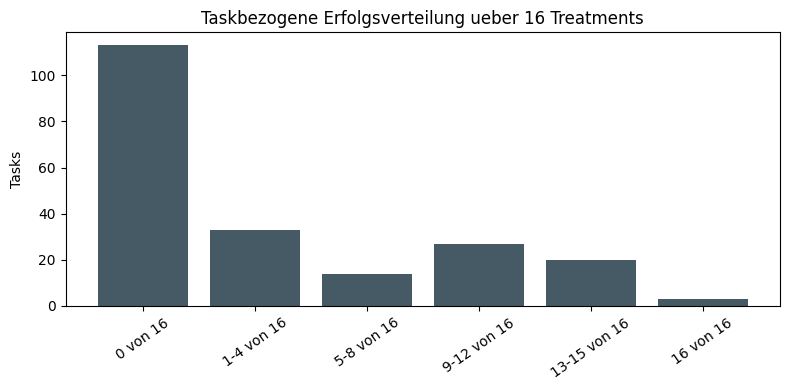

**Textbaustein.** `113` Tasks waren in keinem der `16` Treatments erfolgreich, waehrend `3` Tasks in allen Treatments erfolgreich waren.
Die uebrigen Tasks bilden den eigentlich informativen Bereich fuer Treatmentvergleiche, weil hier die Wahl von `H` und `k` mit unterschiedlichem Erfolg verbunden ist.

In [6]:
task_success_counts = (
    summary_df.groupby("task_id")
    .agg(
        successes=("success", "sum"),
        treatments=("hk", "nunique"),
        site=("site", "first"),
        task_type=("task_type", "first"),
        intent_bucket=("intent_bucket", "first"),
    )
    .reset_index()
)

def success_bin(successes: int, treatments: int) -> str:
    successes = int(successes)
    if successes == 0:
        return "0 von 16"
    if 1 <= successes <= 4:
        return "1-4 von 16"
    if 5 <= successes <= 8:
        return "5-8 von 16"
    if 9 <= successes <= 12:
        return "9-12 von 16"
    if 13 <= successes <= 15:
        return "13-15 von 16"
    if successes == treatments:
        return "16 von 16"
    return f"{successes} von {treatments}"

task_success_counts["success_bin"] = [success_bin(s, t) for s, t in zip(task_success_counts["successes"], task_success_counts["treatments"])]
bin_order = ["0 von 16", "1-4 von 16", "5-8 von 16", "9-12 von 16", "13-15 von 16", "16 von 16"]
solvability = (
    task_success_counts.groupby("success_bin")
    .agg(tasks=("task_id", "count"), mean_successes=("successes", "mean"))
    .reindex(bin_order)
    .fillna({"tasks": 0, "mean_successes": 0})
    .reset_index()
)
solvability["tasks"] = solvability["tasks"].astype(int)
display(solvability)

display(pd.crosstab(task_success_counts["site"], task_success_counts["success_bin"]).reindex(columns=bin_order, fill_value=0))
display(pd.crosstab(task_success_counts["task_type"], task_success_counts["success_bin"]).reindex(columns=bin_order, fill_value=0))

if plt is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(solvability["success_bin"], solvability["tasks"], color="#455a64")
    ax.set_title("Taskbezogene Erfolgsverteilung ueber 16 Treatments")
    ax.set_ylabel("Tasks")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()

zero_tasks = int(solvability.loc[solvability["success_bin"].eq("0 von 16"), "tasks"].iloc[0])
all_tasks = int(solvability.loc[solvability["success_bin"].eq("16 von 16"), "tasks"].iloc[0])
display(Markdown(
    f"""
**Textbaustein.** `{zero_tasks}` Tasks waren in keinem der `{expected_num_treatments}` Treatments erfolgreich, waehrend `{all_tasks}` Tasks in allen Treatments erfolgreich waren.
Die uebrigen Tasks bilden den eigentlich informativen Bereich fuer Treatmentvergleiche, weil hier die Wahl von `H` und `k` mit unterschiedlichem Erfolg verbunden ist.
""".strip()
))


## Paarweise Win-Loss-Vergleiche wichtiger Treatments

Da dieselben Tasks in allen Treatments vorkommen, koennen zwei Treatments paarweise verglichen werden. Die Tabelle zaehlt fuer jedes Treatmentpaar, wie oft A gewinnt, B gewinnt, beide erfolgreich oder beide erfolglos sind.



In [7]:
def pairwise_win_loss(df: pd.DataFrame, treatment_a: str, treatment_b: str) -> dict[str, Any]:
    pivot = df.pivot_table(index="task_id", columns="hk", values="success", aggfunc="max")
    if treatment_a not in pivot.columns or treatment_b not in pivot.columns:
        raise ValueError(f"Missing treatment in pivot: {treatment_a}, {treatment_b}")
    pair = pivot[[treatment_a, treatment_b]].dropna().astype(bool)
    a = pair[treatment_a]
    b = pair[treatment_b]
    return {
        "treatment_a": treatment_a,
        "treatment_b": treatment_b,
        "paired_tasks": len(pair),
        "a_success_b_fail": int((a & ~b).sum()),
        "b_success_a_fail": int((b & ~a).sum()),
        "both_success": int((a & b).sum()),
        "both_fail": int((~a & ~b).sum()),
        "net_wins_a_minus_b": int((a & ~b).sum() - (b & ~a).sum()),
    }

comparison_pairs = []
preferred_pairs = [("h5/k5", "h0/k0"), ("h5/k5", "h0/k5"), ("h5/k5", "h10/k10"), ("h0/k5", "h0/k0"), ("h10/k10", "h10/k0")]
for a, b in preferred_pairs:
    if a in ordered_hks and b in ordered_hks:
        comparison_pairs.append(pairwise_win_loss(summary_df, a, b))
win_loss_table = pd.DataFrame(comparison_pairs)
display(win_loss_table)

pivot_success = summary_df.pivot_table(index="task_id", columns="hk", values="success", aggfunc="max").reindex(columns=ordered_hks)
net_matrix = pd.DataFrame(index=ordered_hks, columns=ordered_hks, dtype=float)
for a in ordered_hks:
    for b in ordered_hks:
        if a == b:
            net_matrix.loc[a, b] = 0
            continue
        pair = pivot_success[[a, b]].dropna().astype(bool)
        net_matrix.loc[a, b] = int((pair[a] & ~pair[b]).sum() - (pair[b] & ~pair[a]).sum())
display(net_matrix.astype(int))

if not win_loss_table.empty:
    main_pair = win_loss_table.iloc[0]
    display(Markdown(
        f"""
**Textbaustein.** Im gepaarten Vergleich `{main_pair['treatment_a']}` gegen `{main_pair['treatment_b']}` gibt es `{int(main_pair['a_success_b_fail'])}` Tasks, die nur unter `{main_pair['treatment_a']}` erfolgreich sind, und `{int(main_pair['b_success_a_fail'])}` Tasks, die nur unter `{main_pair['treatment_b']}` erfolgreich sind.
Bei `{int(main_pair['both_success'])}` Tasks sind beide Treatments erfolgreich, bei `{int(main_pair['both_fail'])}` Tasks scheitern beide.
Diese Darstellung nutzt die Blockstruktur des Experiments direkter als ein Vergleich globaler Mittelwerte.
""".strip()
    ))


,treatment_a,treatment_b,paired_tasks,a_success_b_fail,b_success_a_fail,both_success,both_fail,net_wins_a_minus_b
0,h5/k5,h0/k0,210,58,1,8,143,57
1,h5/k5,h0/k5,210,11,6,55,138,5
2,h5/k5,h10/k10,210,15,10,51,134,5
3,h0/k5,h0/k0,210,54,2,7,147,52
4,h10/k10,h10/k0,210,49,7,12,142,42


,h0/k0,h0/k2,h0/k5,h0/k10,h2/k0,h2/k2,h2/k5,h2/k10,h5/k0,h5/k2,h5/k5,h5/k10,h10/k0,h10/k2,h10/k5,h10/k10
h0/k0,0,-41,-52,-44,-35,-50,-51,-49,-11,-47,-57,-42,-10,-41,-44,-52
h0/k2,41,0,-11,-3,6,-9,-10,-8,30,-6,-16,-1,31,0,-3,-11
h0/k5,52,11,0,8,17,2,1,3,41,5,-5,10,42,11,8,0
h0/k10,44,3,-8,0,9,-6,-7,-5,33,-3,-13,2,34,3,0,-8
h2/k0,35,-6,-17,-9,0,-15,-16,-14,24,-12,-22,-7,25,-6,-9,-17
h2/k2,50,9,-2,6,15,0,-1,1,39,3,-7,8,40,9,6,-2
h2/k5,51,10,-1,7,16,1,0,2,40,4,-6,9,41,10,7,-1
h2/k10,49,8,-3,5,14,-1,-2,0,38,2,-8,7,39,8,5,-3
h5/k0,11,-30,-41,-33,-24,-39,-40,-38,0,-36,-46,-31,1,-30,-33,-41
h5/k2,47,6,-5,3,12,-3,-4,-2,36,0,-10,5,37,6,3,-5


**Textbaustein.** Im gepaarten Vergleich `h5/k5` gegen `h0/k0` gibt es `58` Tasks, die nur unter `h5/k5` erfolgreich sind, und `1` Tasks, die nur unter `h0/k0` erfolgreich sind.
Bei `8` Tasks sind beide Treatments erfolgreich, bei `143` Tasks scheitern beide.
Diese Darstellung nutzt die Blockstruktur des Experiments direkter als ein Vergleich globaler Mittelwerte.

## Bootstrap-Konfidenzintervalle fuer Success Rates

Die Konfidenzintervalle werden auf Taskebene gebootstrappt. Dadurch werden nicht einzelne Runs als unabhaengig behandelt, sondern Tasks als wiederholte experimentelle Einheiten respektiert.



In [8]:
hk_success_ci = bootstrap_task_success_ci(summary_df, ["h", "k", "hk"], n_boot=1000, seed=42).sort_values(["h", "k"])
hk_success_ci["success_rate_pct"] = hk_success_ci["success_rate"] * 100
hk_success_ci["ci_low_pct"] = hk_success_ci["ci_low"] * 100
hk_success_ci["ci_high_pct"] = hk_success_ci["ci_high"] * 100
display(hk_success_ci)

def bootstrap_pair_diff(df: pd.DataFrame, a: str, b: str, n_boot: int = 1000, seed: int = 43) -> dict[str, Any]:
    pivot = df.pivot_table(index="task_id", columns="hk", values="success", aggfunc="max")[[a, b]].dropna().astype(float)
    rng = np.random.default_rng(seed)
    tasks = pivot.index.to_numpy()
    diffs = []
    for _ in range(n_boot):
        sample_tasks = rng.choice(tasks, size=len(tasks), replace=True)
        sample = pivot.loc[sample_tasks]
        diffs.append(float(sample[a].mean() - sample[b].mean()))
    observed = float(pivot[a].mean() - pivot[b].mean())
    return {"treatment_a": a, "treatment_b": b, "diff_a_minus_b": observed, "ci_low": float(np.quantile(diffs, 0.025)), "ci_high": float(np.quantile(diffs, 0.975)), "paired_tasks": len(pivot)}

pair_ci_rows = [bootstrap_pair_diff(summary_df, a, b) for a, b in preferred_pairs if a in ordered_hks and b in ordered_hks]
pair_ci = pd.DataFrame(pair_ci_rows)
display(pair_ci)


,h,k,hk,success_rate,ci_low,ci_high,success_rate_pct,ci_low_pct,ci_high_pct
0,0,0,h0/k0,0.042857,0.019048,0.071429,4.285714,1.904762,7.142857
1,0,2,h0/k2,0.238095,0.176190,0.290476,23.809524,17.619048,29.047619
2,0,5,h0/k5,0.290476,0.228571,0.347619,29.047619,22.857143,34.761905
3,0,10,h0/k10,0.252381,0.195119,0.314286,25.238095,19.511905,31.428571
4,2,0,h2/k0,0.209524,0.152381,0.266667,20.952381,15.238095,26.666667
5,2,2,h2/k2,0.280952,0.219048,0.338214,28.095238,21.904762,33.821429
6,2,5,h2/k5,0.285714,0.223810,0.342857,28.571429,22.380952,34.285714
7,2,10,h2/k10,0.276190,0.214286,0.338095,27.619048,21.428571,33.809524
8,5,0,h5/k0,0.095238,0.057143,0.133333,9.523810,5.714286,13.333333
9,5,2,h5/k2,0.266667,0.204762,0.319048,26.666667,20.476190,31.904762


,treatment_a,treatment_b,diff_a_minus_b,ci_low,ci_high,paired_tasks
0,h5/k5,h0/k0,0.271429,0.209524,0.328571,210
1,h5/k5,h0/k5,0.023810,-0.014286,0.061905,210
2,h5/k5,h10/k10,0.023810,-0.019048,0.066667,210
3,h0/k5,h0/k0,0.247619,0.180952,0.304762,210
4,h10/k10,h10/k0,0.200000,0.133333,0.266667,210


## Tokenverbrauch und API-Kostenproxy

Der Tokenverbrauch wird als Effizienzmetrik betrachtet. Die API-Kosten werden nicht als exakte Rechnung, sondern als transparenter Kostenproxy aus Prompt- und Completion-Tokens modelliert; die Preisparameter sind explizite Annahmen und sollten vor der finalen Abgabe gegen die aktuelle Preisseite des verwendeten Google-Vertex-Modells geprueft werden.



In [9]:
def add_cost_proxy(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    input_tokens = out["prompt_tokens"].where(out["prompt_tokens"] > 0, out["total_tokens"])
    output_tokens = out["completion_tokens"].where(out["completion_tokens"] > 0, 0)
    cache_hit_tokens = input_tokens * CACHE_HIT_RATE
    billable_input_tokens = input_tokens - cache_hit_tokens
    out["billable_input_tokens_est"] = billable_input_tokens
    out["output_tokens_est"] = output_tokens
    out["cache_hit_tokens_est"] = cache_hit_tokens
    out["estimated_token_cost_usd"] = (
        billable_input_tokens / 1_000_000 * INPUT_PRICE_PER_1M_USD
        + output_tokens / 1_000_000 * OUTPUT_PRICE_PER_1M_USD
        + cache_hit_tokens / 1_000_000 * CACHE_HIT_PRICE_PER_1M_USD
    )
    return out

cost_df = add_cost_proxy(summary_df)

cost_by_hk = (
    cost_df.groupby(["h", "k", "hk"])
    .agg(
        runs=("task_id", "count"),
        mean_tokens=("total_tokens", "mean"),
        median_tokens=("total_tokens", "median"),
        iqr_tokens=("total_tokens", lambda s: s.quantile(0.75) - s.quantile(0.25)),
        mean_prompt_tokens=("prompt_tokens", "mean"),
        mean_completion_tokens=("completion_tokens", "mean"),
        mean_cost_usd=("estimated_token_cost_usd", "mean"),
        total_cost_usd=("estimated_token_cost_usd", "sum"),
    )
    .reset_index()
    .sort_values(["h", "k"])
)
display(cost_by_hk)

if plt is not None and sns is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    token_pivot = cost_by_hk.pivot(index="h", columns="k", values="mean_tokens") / 1000
    cost_pivot = cost_by_hk.pivot(index="h", columns="k", values="mean_cost_usd")
    sns.heatmap(token_pivot, annot=True, fmt=".1f", cmap="Blues", ax=axes[0], cbar_kws={"label": "Tsd. Tokens"})
    axes[0].set_title("Durchschnittlicher Tokenverbrauch")
    sns.heatmap(cost_pivot, annot=True, fmt=".4f", cmap="Purples", ax=axes[1], cbar_kws={"label": "USD / Run"})
    axes[1].set_title("API-Kostenproxy pro Run")
    for ax in axes:
        ax.set_xlabel("k")
        ax.set_ylabel("H")
    plt.tight_layout()
    plt.show()

min_cost = cost_by_hk.sort_values("mean_cost_usd").iloc[0]
max_cost = cost_by_hk.sort_values("mean_cost_usd", ascending=False).iloc[0]
display(Markdown(
    f"""
**Textbaustein.** Der niedrigste durchschnittliche Kostenproxy tritt bei `{min_cost['hk']}` mit `{min_cost['mean_cost_usd']:.4f}` USD pro Run auf.
Der hoechste durchschnittliche Kostenproxy tritt bei `{max_cost['hk']}` mit `{max_cost['mean_cost_usd']:.4f}` USD pro Run auf.
Da die Schaetzung auf Tokenzaehlern und expliziten Preisannahmen basiert, wird sie als vergleichender Effizienzproxy und nicht als abrechnungsgenaue Kostenmessung interpretiert.
""".strip()
))


,h,k,hk,runs,mean_tokens,median_tokens,iqr_tokens,mean_prompt_tokens,mean_completion_tokens,mean_cost_usd,total_cost_usd
0,0,0,h0/k0,210,113106.528571,107802.0,65336.25,112203.133333,903.395238,0.017373,3.648226
1,0,2,h0/k2,210,675730.195238,320319.0,840877.25,670432.647619,5297.547619,0.103743,21.786119
2,0,5,h0/k5,210,774737.604762,534458.0,1000345.00,769666.047619,5071.557143,0.118493,24.883497
3,0,10,h0/k10,210,812293.395238,628396.5,1011451.25,807275.985714,5017.409524,0.124102,26.061387
4,2,0,h2/k0,210,762556.423810,372503.5,1025483.25,756089.666667,6466.757143,0.117294,24.631636
5,2,2,h2/k2,210,897020.633333,656841.5,1161751.75,890324.195238,6696.438095,0.137566,28.888963
6,2,5,h2/k5,210,883059.023810,772106.5,1077242.00,877412.004762,5647.019048,0.135000,28.350003
7,2,10,h2/k10,210,884474.395238,876737.5,1061504.75,879266.823810,5207.571429,0.135015,28.353059
8,5,0,h5/k0,210,215393.238095,121715.0,92364.50,213755.576190,1637.661905,0.033046,6.939646
9,5,2,h5/k2,210,813980.819048,445979.0,1044481.25,807442.066667,6538.752381,0.125040,26.258308


**Textbaustein.** Der niedrigste durchschnittliche Kostenproxy tritt bei `h0/k0` mit `0.0174` USD pro Run auf.
Der hoechste durchschnittliche Kostenproxy tritt bei `h2/k2` mit `0.1376` USD pro Run auf.
Da die Schaetzung auf Tokenzaehlern und expliziten Preisannahmen basiert, wird sie als vergleichender Effizienzproxy und nicht als abrechnungsgenaue Kostenmessung interpretiert.

## Laufzeit und Modellaufrufe

Dieser Abschnitt betrachtet Wall-Clock Time, Planner-Calls, Executor-Calls und ausgefuehrte Browseraktionen. Dadurch wird sichtbar, ob ein Treatment zwar erfolgreich ist, aber deutlich mehr Modellaufrufe oder Laufzeit benoetigt.



In [10]:
runtime_by_hk = (
    summary_df.groupby(["h", "k", "hk"])
    .agg(
        runs=("task_id", "count"),
        mean_runtime_s=("total_runtime_s", "mean"),
        median_runtime_s=("total_runtime_s", "median"),
        iqr_runtime_s=("total_runtime_s", lambda s: s.quantile(0.75) - s.quantile(0.25)),
        mean_steps=("total_steps", "mean"),
        mean_planner_calls=("planner_calls", "mean"),
        mean_executor_calls=("executor_calls", "mean"),
    )
    .reset_index()
    .sort_values(["h", "k"])
)
display(runtime_by_hk)

if plt is not None and sns is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, metric, title, fmt in [
        (axes[0], "mean_runtime_s", "Mittlere Laufzeit (s)", ".0f"),
        (axes[1], "mean_planner_calls", "Mittlere Planner-Calls", ".1f"),
        (axes[2], "mean_executor_calls", "Mittlere Executor-Calls", ".1f"),
    ]:
        pivot = runtime_by_hk.pivot(index="h", columns="k", values=metric)
        sns.heatmap(pivot, annot=True, fmt=fmt, cmap="YlGnBu", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("k")
        ax.set_ylabel("H")
    plt.tight_layout()
    plt.show()

fastest = runtime_by_hk.sort_values("median_runtime_s").iloc[0]
slowest = runtime_by_hk.sort_values("median_runtime_s", ascending=False).iloc[0]
display(Markdown(
    f"""
**Textbaustein.** Die kuerzeste mediane Laufzeit zeigt `{fastest['hk']}` mit `{fastest['median_runtime_s']:.1f}` Sekunden pro Run.
Die laengste mediane Laufzeit zeigt `{slowest['hk']}` mit `{slowest['median_runtime_s']:.1f}` Sekunden.
Fuer die Diskussion ist relevant, ob hoehere Laufzeit durch mehr Planner-Aufrufe, mehr Executor-Schritte oder technische Wiederholungen erklaert wird.
""".strip()
))


,h,k,hk,runs,mean_runtime_s,median_runtime_s,iqr_runtime_s,mean_steps,mean_planner_calls,mean_executor_calls
0,0,0,h0/k0,210,60.247648,44.5525,26.36700,4.066667,1.519048,3.252381
1,0,2,h0/k2,210,291.428081,111.7285,262.67050,18.400000,7.766667,14.838095
2,0,5,h0/k5,210,279.663910,176.1790,351.99050,22.571429,6.309524,18.071429
3,0,10,h0/k10,210,289.968948,215.4780,381.94775,24.347619,5.480952,19.466667
4,2,0,h2/k0,210,287.319005,158.3615,357.62100,21.104762,12.076190,16.709524
5,2,2,h2/k2,210,351.111538,236.5085,430.36525,24.442857,11.119048,19.600000
6,2,5,h2/k5,210,304.713890,241.2195,400.32600,26.095238,7.519048,20.714286
7,2,10,h2/k10,210,306.793290,241.4825,376.66925,26.428571,6.123810,20.942857
8,5,0,h5/k0,210,85.155924,50.2955,41.76300,6.919048,2.166667,5.719048
9,5,2,h5/k2,210,304.365590,168.4690,415.36350,22.076190,9.319048,17.666667


**Textbaustein.** Die kuerzeste mediane Laufzeit zeigt `h0/k0` mit `44.6` Sekunden pro Run.
Die laengste mediane Laufzeit zeigt `h5/k10` mit `249.2` Sekunden.
Fuer die Diskussion ist relevant, ob hoehere Laufzeit durch mehr Planner-Aufrufe, mehr Executor-Schritte oder technische Wiederholungen erklaert wird.

## Prozessmetriken und Fehlerbilder

Prozessmetriken erklaeren, warum Runs erfolgreich oder nicht erfolgreich waren. Sie ersetzen nicht die offizielle Success Rate, helfen aber bei der Interpretation von No-Progress, Loops, Aktionsfehlern, Step-Budget-Grenzen und tasktypischen Failure Classes.



## Definition und Priorisierung der Failure-Kategorien

Die Failure-Kategorie ist eine diagnostische Einordnung aus `hk_agent.diagnostics`. Pro Run wird genau eine Hauptkategorie gespeichert; wenn mehrere Signale gleichzeitig vorliegen, entscheidet die im Diagnosecode implementierte Prioritaetsreihenfolge.



In [11]:
FAILURE_CATEGORY_DEFINITIONS = [
    ("official_success", "Der offizielle WebArena-Verified-Evaluator bewertet den Lauf als erfolgreich."),
    ("contamination_suffix_near_miss", "Near-Miss durch bekannte Suffix-/Kontaminationsfaelle; diagnostisch markiert, aber nicht identisch mit rohem official_success."),
    ("repeated_llm_timeout", "Wiederholte LLM-Timeouts fuehrten zum Abbruch."),
    ("repeated_repair_failure", "Eine Repair-Variante diagnostizierte wiederholt dieselbe nicht behobene Fehlerklasse."),
    ("runtime_exception", "Der Runner scheiterte technisch vor vollstaendiger offizieller Evaluation."),
    ("llm_json_or_action_parse_failure", "Planner oder Executor lieferten keine parsebare JSON-/Action-Struktur."),
    ("bad_route_or_not_found", "Der Lauf erreichte eine ungueltige Route oder eine Not-Found-Seite."),
    ("missing_action_not_allowed", "Eine Policy-/Permission-Aufgabe haette ACTION_NOT_ALLOWED_ERROR benoetigt, die finale Antwort tat dies aber nicht."),
    ("missing_retrieved_data", "Ein RETRIEVE-Task wurde finalisiert, ohne die erwarteten Daten zurueckzugeben."),
    ("schema_or_value_mismatch", "Der Agent gab Daten zurueck, aber Wert oder Schema wurden vom offiziellen Evaluator abgelehnt."),
    ("gitlab_mr_reply_ambiguous_assignment", "GitLab-Merge-Request-Reply-Aufgabe scheiterte wahrscheinlich an ambiger MR-Auswahl oder falschem Reply-Ziel."),
    ("gitlab_invite_multi_user_incomplete", "GitLab-Invite erreichte den Invite-Flow, uebermittelte aber nur einen Teil der geforderten Nutzer."),
    ("premature_mutation_success", "MUTATE SUCCESS wurde gemeldet, bevor eine zustandsveraendernde Aktion beobachtet wurde."),
    ("missing_required_mutation", "Ein MUTATE-Task wurde finalisiert, aber der offizielle Evaluator beobachtete die erforderliche Mutation nicht."),
    ("policy_mutation_eval_mismatch", "MUTATE-foermiger Policy-/Permission-Fall mit mismatch zwischen finaler Antwort und Evaluatorvertrag."),
    ("planner_call_budget_exhausted", "Das Planner-Call-Budget wurde ohne akzeptiertes finales Ergebnis erreicht."),
    ("step_budget_exhausted", "Das Step-Budget wurde ohne akzeptiertes finales Ergebnis erreicht."),
    ("loop_or_no_progress", "Runtime-Signale deuten auf Schleife oder fehlenden beobachtbaren Fortschritt."),
    ("official_eval_mismatch", "Sammelkategorie: Lauf ist strukturell abgeschlossen, wurde aber vom offiziellen Evaluator abgelehnt."),
]
failure_definitions_df = pd.DataFrame(FAILURE_CATEGORY_DEFINITIONS, columns=["failure_category", "definition"])
display(failure_definitions_df)

display(Markdown(
    """
**Prioritaetsregel.** Die Diagnose prueft zuerst offiziellen Erfolg und bekannte Near-Miss-/Kontaminationsfaelle, danach harte Abbrueche und technische Fehler, danach Format-/Routen-/Policy-/Retrieve-/Mutation-spezifische Fehler, anschliessend Budget- und Loop-Kategorien und zuletzt `official_eval_mismatch` als Sammelkategorie. `official_eval_mismatch` ist deshalb kein einzelner technischer Fehler, sondern eine Restkategorie fuer offiziell abgelehnte Laeufe, die nicht durch eine spezifischere Regel erklaert wurden.
""".strip()
))


,failure_category,definition
0,official_success,Der offizielle WebArena-Verified-Evaluator bewertet den Lauf als erfolgreich.
1,contamination_suffix_near_miss,"Near-Miss durch bekannte Suffix-/Kontaminationsfaelle; diagnostisch markiert, aber nicht identisch mit rohem official_success."
2,repeated_llm_timeout,Wiederholte LLM-Timeouts fuehrten zum Abbruch.
3,repeated_repair_failure,Eine Repair-Variante diagnostizierte wiederholt dieselbe nicht behobene Fehlerklasse.
4,runtime_exception,Der Runner scheiterte technisch vor vollstaendiger offizieller Evaluation.
5,llm_json_or_action_parse_failure,Planner oder Executor lieferten keine parsebare JSON-/Action-Struktur.
6,bad_route_or_not_found,Der Lauf erreichte eine ungueltige Route oder eine Not-Found-Seite.
7,missing_action_not_allowed,"Eine Policy-/Permission-Aufgabe haette ACTION_NOT_ALLOWED_ERROR benoetigt, die finale Antwort tat dies aber nicht."
8,missing_retrieved_data,"Ein RETRIEVE-Task wurde finalisiert, ohne die erwarteten Daten zurueckzugeben."
9,schema_or_value_mismatch,"Der Agent gab Daten zurueck, aber Wert oder Schema wurden vom offiziellen Evaluator abgelehnt."


**Prioritaetsregel.** Die Diagnose prueft zuerst offiziellen Erfolg und bekannte Near-Miss-/Kontaminationsfaelle, danach harte Abbrueche und technische Fehler, danach Format-/Routen-/Policy-/Retrieve-/Mutation-spezifische Fehler, anschliessend Budget- und Loop-Kategorien und zuletzt `official_eval_mismatch` als Sammelkategorie. `official_eval_mismatch` ist deshalb kein einzelner technischer Fehler, sondern eine Restkategorie fuer offiziell abgelehnte Laeufe, die nicht durch eine spezifischere Regel erklaert wurden.

,h,k,hk,runs,mean_runtime_replans,mean_no_progress,mean_invalid_actions,mean_loop_events,step_budget_rate,planner_budget_rate,mean_step_errors
0,0,0,h0/k0,210,0.519048,0.523810,0.523810,0.414286,0.004762,0.000000,0.523810
1,0,2,h0/k2,210,6.814286,6.995238,4.100000,5.161905,0.242857,0.038095,2.900000
2,0,5,h0/k5,210,5.371429,5.595238,4.061905,4.409524,0.352381,0.052381,3.671429
3,0,10,h0/k10,210,4.542857,4.795238,4.157143,3.757143,0.471429,0.057143,3.942857
4,2,0,h2/k0,210,3.204762,3.266667,3.266667,2.638095,0.333333,0.028571,3.261905
5,2,2,h2/k2,210,8.819048,9.042857,5.319048,6.709524,0.428571,0.014286,4.061905
6,2,5,h2/k5,210,6.128571,6.433333,4.742857,5.195238,0.519048,0.004762,4.276190
7,2,10,h2/k10,210,5.023810,5.328571,4.566667,4.228571,0.533333,0.000000,4.347619
8,5,0,h5/k0,210,0.671429,0.671429,0.671429,0.533333,0.028571,0.004762,0.671429
9,5,2,h5/k2,210,8.338095,8.552381,4.614286,6.328571,0.314286,0.042857,3.466667


,failure_category,runs
11,step_budget_exhausted,1007
8,official_eval_mismatch,528
3,llm_json_or_action_parse_failure,417
6,missing_required_mutation,165
10,schema_or_value_mismatch,107
7,missing_retrieved_data,101
5,missing_action_not_allowed,73
4,loop_or_no_progress,55
9,planner_call_budget_exhausted,53
2,gitlab_mr_reply_ambiguous_assignment,47


,run_endstate_or_failure,runs,success_rate
12,step_budget_exhausted,1007,0.0
9,official_success,770,1.0
8,official_eval_mismatch,528,0.0
3,llm_json_or_action_parse_failure,417,0.0
6,missing_required_mutation,165,0.0
11,schema_or_value_mismatch,107,0.0
7,missing_retrieved_data,101,0.0
5,missing_action_not_allowed,73,0.0
4,loop_or_no_progress,55,0.0
10,planner_call_budget_exhausted,53,0.0


failure_category,bad_route_or_not_found,gitlab_invite_multi_user_incomplete,gitlab_mr_reply_ambiguous_assignment,llm_json_or_action_parse_failure,loop_or_no_progress,missing_action_not_allowed,missing_required_mutation,missing_retrieved_data,official_eval_mismatch,planner_call_budget_exhausted,schema_or_value_mismatch,step_budget_exhausted
site,,,,,,,,,,,,
gitlab,6,29,47,27,22,43,63,18,121,23,23,300
reddit,0,0,0,16,8,0,64,1,123,6,1,141
shopping,1,0,0,223,21,30,30,70,173,10,25,158
shopping_admin,1,0,0,151,4,0,8,12,111,14,58,408


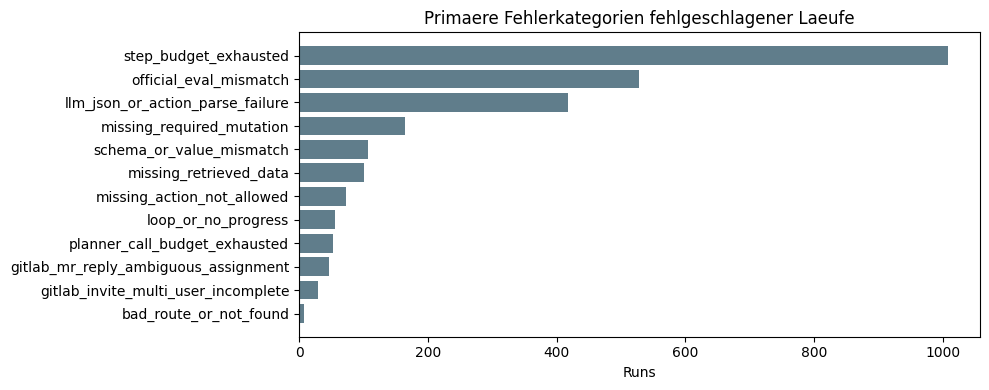

**Textbaustein.** Unter den fehlgeschlagenen Laeufen ist `step_budget_exhausted` mit `1007` Runs die haeufigste primaere Fehlerkategorie.
Runtime-Signale wie No-Progress oder Loop-Events sind als Prozessindikatoren zu lesen: Sie zeigen, wo der Agent waehrend der Ausfuehrung Schwierigkeiten hatte, sind aber nicht identisch mit der offiziellen Erfolgsbewertung.

In [12]:
process_cols = [
    "runtime_replans", "runtime_no_progress_events", "runtime_invalid_actions", "runtime_loop_events",
    "step_budget_reached", "planner_call_budget_reached", "num_step_errors", "mutation_action_count",
]
for col in process_cols:
    if col not in summary_df.columns:
        summary_df[col] = 0
    if summary_df[col].dtype == object:
        if col.endswith("reached"):
            summary_df[col] = as_bool(summary_df[col]).astype(int)
        else:
            summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce").fillna(0)

process_by_hk = (
    summary_df.groupby(["h", "k", "hk"])
    .agg(
        runs=("task_id", "count"),
        mean_runtime_replans=("runtime_replans", "mean"),
        mean_no_progress=("runtime_no_progress_events", "mean"),
        mean_invalid_actions=("runtime_invalid_actions", "mean"),
        mean_loop_events=("runtime_loop_events", "mean"),
        step_budget_rate=("step_budget_reached", "mean"),
        planner_budget_rate=("planner_call_budget_reached", "mean"),
        mean_step_errors=("num_step_errors", "mean"),
    )
    .reset_index()
    .sort_values(["h", "k"])
)
display(process_by_hk)

failed_runs = summary_df.loc[~summary_df["success"]].copy()
failed_runs["failure_category"] = failed_runs.get("failure_category", "unknown").fillna("unknown")

failure_summary = (
    failed_runs.groupby(["failure_category"], dropna=False)
    .agg(runs=("task_id", "count"))
    .reset_index()
    .sort_values("runs", ascending=False)
)
display(failure_summary)

run_endstate_summary = (
    summary_df.assign(run_endstate_or_failure=summary_df.get("failure_category", "unknown").fillna("success_or_unknown"))
    .groupby(["run_endstate_or_failure"], dropna=False)
    .agg(runs=("task_id", "count"), success_rate=("success", "mean"))
    .reset_index()
    .sort_values("runs", ascending=False)
)
display(run_endstate_summary)

failure_by_site = pd.crosstab(
    failed_runs["site"],
    failed_runs["failure_category"],
)
display(failure_by_site)

if plt is not None:
    fig, ax = plt.subplots(figsize=(10, 4))
    top_failures = failure_summary.head(12).sort_values("runs")
    ax.barh(top_failures["failure_category"], top_failures["runs"], color="#607d8b")
    ax.set_title("Primaere Fehlerkategorien fehlgeschlagener Laeufe")
    ax.set_xlabel("Runs")
    plt.tight_layout()
    plt.show()

most_common_failure = failure_summary.iloc[0]
display(Markdown(
    f"""
**Textbaustein.** Unter den fehlgeschlagenen Laeufen ist `{most_common_failure['failure_category']}` mit `{int(most_common_failure['runs'])}` Runs die haeufigste primaere Fehlerkategorie.
Runtime-Signale wie No-Progress oder Loop-Events sind als Prozessindikatoren zu lesen: Sie zeigen, wo der Agent waehrend der Ausfuehrung Schwierigkeiten hatte, sind aber nicht identisch mit der offiziellen Erfolgsbewertung.
""".strip()
))


## Fehlerkategorien und Prozesssignale nach Site, Tasktyp und Treatment

Die vollstaendigen Tabellen sind eher Anhangsmaterial. Im Haupttext sollten nur die auffaelligsten Unterschiede berichtet werden, etwa bestimmte Site-spezifische Fehlerhaeufungen oder systematische Unterschiede zwischen erfolgreichen und erfolglosen Runs.



In [13]:
failure_by_task_type = pd.crosstab(
    summary_df["task_type"],
    summary_df.get("failure_category", pd.Series("unknown", index=summary_df.index)).fillna("success_or_unknown"),
)
display(failure_by_task_type)

failure_by_treatment = pd.crosstab(
    summary_df["hk"],
    summary_df.get("failure_category", pd.Series("unknown", index=summary_df.index)).fillna("success_or_unknown"),
).reindex(ordered_hks)
display(failure_by_treatment)

process_by_success = (
    summary_df.groupby("success")
    .agg(
        runs=("task_id", "count"),
        mean_steps=("total_steps", "mean"),
        mean_runtime_replans=("runtime_replans", "mean"),
        mean_no_progress=("runtime_no_progress_events", "mean"),
        mean_invalid_actions=("runtime_invalid_actions", "mean"),
        mean_loop_events=("runtime_loop_events", "mean"),
        mean_planner_calls=("planner_calls", "mean"),
        mean_executor_calls=("executor_calls", "mean"),
        mean_tokens=("total_tokens", "mean"),
        mean_runtime_s=("total_runtime_s", "mean"),
    )
    .reset_index()
)
process_by_success["success_label"] = process_by_success["success"].map({True: "erfolgreich", False: "nicht erfolgreich"})
display(process_by_success)

if "near_miss_score" in summary_df.columns:
    near_miss_by_failure = (
        summary_df[~summary_df["success"]]
        .groupby("failure_category", dropna=False)
        .agg(runs=("task_id", "count"), mean_near_miss_score=("near_miss_score", "mean"), median_near_miss_score=("near_miss_score", "median"))
        .reset_index()
        .sort_values("runs", ascending=False)
    )
    display(near_miss_by_failure)

display(Markdown(
    """
**Textbaustein.** Erfolgreiche und erfolglose Laeufe unterscheiden sich nicht nur im offiziellen Endergebnis, sondern auch in Prozessmerkmalen wie Anzahl der Steps, Replans, No-Progress-Signale und Modellaufrufe. Diese Tabellen sollten deskriptiv gelesen werden, weil Replanning sowohl Ursache als auch Folge von schwierigen Laufzustaenden sein kann.
""".strip()
))


failure_category,bad_route_or_not_found,gitlab_invite_multi_user_incomplete,gitlab_mr_reply_ambiguous_assignment,llm_json_or_action_parse_failure,loop_or_no_progress,missing_action_not_allowed,missing_required_mutation,missing_retrieved_data,official_eval_mismatch,official_success,planner_call_budget_exhausted,schema_or_value_mismatch,step_budget_exhausted
task_type,,,,,,,,,,,,,
MUTATE,8,29,47,218,18,73,165,0,302,501,32,0,511
NAVIGATE,0,0,0,54,9,0,0,0,81,159,0,0,49
RETRIEVE,0,0,0,145,28,0,0,101,145,110,21,107,447


failure_category,bad_route_or_not_found,gitlab_invite_multi_user_incomplete,gitlab_mr_reply_ambiguous_assignment,llm_json_or_action_parse_failure,loop_or_no_progress,missing_action_not_allowed,missing_required_mutation,missing_retrieved_data,official_eval_mismatch,official_success,planner_call_budget_exhausted,schema_or_value_mismatch,step_budget_exhausted
hk,,,,,,,,,,,,,
h0/k0,0,0,3,12,4,6,0,4,164,9,0,5,3
h0/k2,0,3,3,25,7,4,10,9,12,50,8,6,73
h0/k5,1,3,3,29,3,4,9,5,5,61,8,8,71
h0/k10,1,1,3,32,1,5,12,6,5,53,8,8,75
h2/k0,1,1,3,27,1,4,13,9,31,44,3,10,63
h2/k2,0,2,3,31,8,5,14,7,3,59,2,6,70
h2/k5,3,0,3,26,2,3,11,7,5,60,1,5,84
h2/k10,1,0,3,27,0,3,13,4,6,58,0,4,91
h5/k0,0,3,3,18,2,6,4,10,111,20,0,10,23


,success,runs,mean_steps,mean_runtime_replans,mean_no_progress,mean_invalid_actions,mean_loop_events,mean_planner_calls,mean_executor_calls,mean_tokens,mean_runtime_s,success_label
0,False,2590,23.254826,5.953282,6.193436,4.509266,4.828185,7.683012,18.498456,810662.169112,302.507343,nicht erfolgreich
1,True,770,9.297403,1.367532,1.372727,0.758442,0.851948,2.584416,7.650649,288506.720779,102.722866,erfolgreich


,failure_category,runs,mean_near_miss_score,median_near_miss_score
11,step_budget_exhausted,1007,0.541460,0.45
8,official_eval_mismatch,528,0.598958,0.65
3,llm_json_or_action_parse_failure,417,0.450839,0.40
6,missing_required_mutation,165,0.743939,0.75
10,schema_or_value_mismatch,107,0.945327,0.95
7,missing_retrieved_data,101,0.692079,0.70
5,missing_action_not_allowed,73,0.555479,0.55
4,loop_or_no_progress,55,0.530909,0.50
9,planner_call_budget_exhausted,53,0.550943,0.65
2,gitlab_mr_reply_ambiguous_assignment,47,0.707447,0.75


**Textbaustein.** Erfolgreiche und erfolglose Laeufe unterscheiden sich nicht nur im offiziellen Endergebnis, sondern auch in Prozessmerkmalen wie Anzahl der Steps, Replans, No-Progress-Signale und Modellaufrufe. Diese Tabellen sollten deskriptiv gelesen werden, weil Replanning sowohl Ursache als auch Folge von schwierigen Laufzustaenden sein kann.

## Replanning-Verhalten

Hier wird untersucht, ob und in welchen Treatments Replanning haeufiger auftritt. Dabei ist wichtig: `k` triggert die Runtime-Pruefung nach einer Anzahl ausgefuehrter Actions; Replanning erfolgt erst danach, wenn der Controller auf Basis des Runtime-Signals eine Replanning-Entscheidung trifft.



In [14]:
replan_by_hk = (
    summary_df.groupby(["h", "k", "hk"])
    .agg(
        runs=("task_id", "count"),
        runs_with_replan=("runtime_replans", lambda s: int((s > 0).sum())),
        replan_rate=("runtime_replans", lambda s: float((s > 0).mean())),
        mean_replans=("runtime_replans", "mean"),
        median_replans=("runtime_replans", "median"),
        mean_no_progress=("runtime_no_progress_events", "mean"),
        mean_loop_events=("runtime_loop_events", "mean"),
    )
    .reset_index()
    .sort_values(["h", "k"])
)
replan_by_hk["replan_rate_pct"] = replan_by_hk["replan_rate"] * 100
display(replan_by_hk)

replan_by_site = (
    summary_df.groupby(["site", "h", "k", "hk"])
    .agg(runs=("task_id", "count"), replan_rate=("runtime_replans", lambda s: float((s > 0).mean())), mean_replans=("runtime_replans", "mean"))
    .reset_index()
    .sort_values(["site", "h", "k"])
)
replan_by_site["replan_rate_pct"] = replan_by_site["replan_rate"] * 100
display(replan_by_site)

if plt is not None and sns is not None:
    pivot = replan_by_hk.pivot(index="h", columns="k", values="replan_rate") * 100
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Oranges", ax=ax, cbar_kws={"label": "Runs mit Replan (%)"})
    ax.set_title("Replanning-Rate nach H/k")
    ax.set_xlabel("k")
    ax.set_ylabel("H")
    plt.show()

max_replan = replan_by_hk.sort_values("replan_rate", ascending=False).iloc[0]
display(Markdown(
    f"""
**Textbaustein.** Die hoechste Replanning-Rate zeigt `{max_replan['hk']}` mit `{max_replan['replan_rate']:.1%}` der Runs.
Bei der Interpretation ist zu beachten, dass ein niedriger `k`-Wert haeufigere Pruefpunkte erzeugen kann, waehrend ein groesserer `H`-Wert groessere Plansegmente zwischen Planner-Aufrufen erlaubt.
Wenn ein k-Pruefpunkt mit dem Ende eines Planungshorizonts zusammenfaellt, wird zuerst der Zustand evaluiert; ein neuer Plan entsteht danach entweder feedbackgetrieben durch den Controller oder horizonterzwungen, wenn keine weiteren Subgoals verbleiben.
""".strip()
))


,h,k,hk,runs,runs_with_replan,replan_rate,mean_replans,median_replans,mean_no_progress,mean_loop_events,replan_rate_pct
0,0,0,h0/k0,210,20,0.095238,0.519048,0.0,0.523810,0.414286,9.523810
1,0,2,h0/k2,210,166,0.790476,6.814286,2.0,6.995238,5.161905,79.047619
2,0,5,h0/k5,210,154,0.733333,5.371429,2.0,5.595238,4.409524,73.333333
3,0,10,h0/k10,210,130,0.619048,4.542857,1.0,4.795238,3.757143,61.904762
4,2,0,h2/k0,210,85,0.404762,3.204762,0.0,3.266667,2.638095,40.476190
5,2,2,h2/k2,210,173,0.823810,8.819048,3.0,9.042857,6.709524,82.380952
6,2,5,h2/k5,210,155,0.738095,6.128571,2.0,6.433333,5.195238,73.809524
7,2,10,h2/k10,210,127,0.604762,5.023810,1.0,5.328571,4.228571,60.476190
8,5,0,h5/k0,210,30,0.142857,0.671429,0.0,0.671429,0.533333,14.285714
9,5,2,h5/k2,210,180,0.857143,8.338095,3.0,8.552381,6.328571,85.714286


,site,h,k,hk,runs,replan_rate,mean_replans,replan_rate_pct
0,gitlab,0,0,h0/k0,57,0.052632,0.070175,5.263158
1,gitlab,0,2,h0/k2,57,0.877193,8.228070,87.719298
2,gitlab,0,5,h0/k5,57,0.666667,4.421053,66.666667
3,gitlab,0,10,h0/k10,57,0.596491,3.964912,59.649123
4,gitlab,2,0,h2/k0,57,0.438596,3.035088,43.859649
5,gitlab,2,2,h2/k2,57,0.912281,10.894737,91.228070
6,gitlab,2,5,h2/k5,57,0.719298,6.964912,71.929825
7,gitlab,2,10,h2/k10,57,0.614035,4.982456,61.403509
8,gitlab,5,0,h5/k0,57,0.122807,0.491228,12.280702
9,gitlab,5,2,h5/k2,57,0.912281,9.736842,91.228070


**Textbaustein.** Die hoechste Replanning-Rate zeigt `h5/k2` mit `85.7%` der Runs.
Bei der Interpretation ist zu beachten, dass ein niedriger `k`-Wert haeufigere Pruefpunkte erzeugen kann, waehrend ein groesserer `H`-Wert groessere Plansegmente zwischen Planner-Aufrufen erlaubt.
Wenn ein k-Pruefpunkt mit dem Ende eines Planungshorizonts zusammenfaellt, wird zuerst der Zustand evaluiert; ein neuer Plan entsteht danach entweder feedbackgetrieben durch den Controller oder horizonterzwungen, wenn keine weiteren Subgoals verbleiben.

## Planmaessige und ereignisbasierte Runtime-Pruefungen

Diese Auswertung liest die JSONL-Artefakte pro Run und ordnet Runtime-Pruefungen anhand des Schrittindex heuristisch planmaessigen und ereignisbasierten Ausloesern zu. Falls ein Logeintrag ein explizites Feld wie `trigger`, `scheduled`, `event_type` oder `reason_code` enthaelt, sollte dieses Feld fuer die finale Klassifikation bevorzugt werden; andernfalls gilt eine Pruefung naeherungsweise als planmaessig, wenn `step_index` ein Vielfaches von `k` ist. Eine ereignisbasierte Pruefung kann zufaellig auf demselben Schrittindex liegen, deshalb ist diese Spalte keine exakte Messung.



In [15]:
def classify_runtime_check_trigger(signal: dict[str, Any], k_value: int) -> str:
    for key in ("trigger", "scheduled", "event_type", "reason_code"):
        if key in signal and signal.get(key) not in (None, ""):
            value = signal.get(key)
            if isinstance(value, bool):
                return "scheduled" if value else "event_based"
            value_text = str(value).lower()
            if value_text in {"scheduled", "periodic", "interval", "k_interval", "planmaessig"}:
                return "scheduled"
            if value_text in {"event", "event_based", "error", "done", "abort", "final", "action_error"}:
                return "event_based"
    if k_value > 0:
        step_index = int(signal.get("step_index") or -1)
        if step_index > 0 and step_index % k_value == 0:
            return "scheduled_heuristic"
    return "event_based_heuristic"

def runtime_controller_counts_for_row(row: pd.Series) -> dict[str, Any]:
    outdir = output_dir_path(row.get("output_dir"))
    k_value = int(row.get("k") or 0)
    result = {
        "task_id": row.get("task_id"),
        "hk": row.get("hk"),
        "h": row.get("h"),
        "k": row.get("k"),
        "site": row.get("site"),
        "task_type": row.get("task_type"),
        "runtime_checks_total": 0,
        "runtime_checks_scheduled": 0,
        "runtime_checks_scheduled_heuristic": 0,
        "runtime_checks_event_based": 0,
        "runtime_checks_event_based_heuristic": 0,
        "controller_continue": 0,
        "controller_local_replan": 0,
        "controller_global_replan": 0,
        "controller_abort": 0,
        "runtime_checks_with_replan": 0,
        "regular_horizon_planning_est": max(int(row.get("planner_calls") or 0) - int(row.get("runtime_replans") or 0) - 1, 0),
    }
    if outdir is None:
        return result
    signals = read_jsonl_file(outdir / "runtime_evaluator_signals.jsonl")
    decisions = read_jsonl_file(outdir / "controller_decisions.jsonl")
    result["runtime_checks_total"] = len(signals)
    trigger_classes = [classify_runtime_check_trigger(sig, k_value) for sig in signals]
    result["runtime_checks_scheduled"] = sum(1 for trigger in trigger_classes if trigger == "scheduled")
    result["runtime_checks_scheduled_heuristic"] = sum(1 for trigger in trigger_classes if trigger == "scheduled_heuristic")
    result["runtime_checks_event_based"] = sum(1 for trigger in trigger_classes if trigger == "event_based")
    result["runtime_checks_event_based_heuristic"] = sum(1 for trigger in trigger_classes if trigger == "event_based_heuristic")
    decision_counts = pd.Series([str(dec.get("decision") or "unknown") for dec in decisions]).value_counts().to_dict() if decisions else {}
    result["controller_continue"] = int(decision_counts.get("continue", 0))
    result["controller_local_replan"] = int(decision_counts.get("local_replan", 0))
    result["controller_global_replan"] = int(decision_counts.get("global_replan", 0))
    result["controller_abort"] = int(decision_counts.get("abort", 0))
    result["runtime_checks_with_replan"] = result["controller_local_replan"] + result["controller_global_replan"]
    return result

runtime_detail = pd.DataFrame([runtime_controller_counts_for_row(row) for _, row in summary_df.iterrows()])
runtime_detail["replan_per_check"] = np.where(runtime_detail["runtime_checks_total"] > 0, runtime_detail["runtime_checks_with_replan"] / runtime_detail["runtime_checks_total"], np.nan)

runtime_check_by_hk = (
    runtime_detail.groupby(["h", "k", "hk"])
    .agg(
        runs=("task_id", "count"),
        runtime_checks_total=("runtime_checks_total", "sum"),
        scheduled_checks=("runtime_checks_scheduled", "sum"),
        scheduled_checks_heuristic=("runtime_checks_scheduled_heuristic", "sum"),
        event_based_checks=("runtime_checks_event_based", "sum"),
        event_based_checks_heuristic=("runtime_checks_event_based_heuristic", "sum"),
        continue_count=("controller_continue", "sum"),
        local_replan_count=("controller_local_replan", "sum"),
        global_replan_count=("controller_global_replan", "sum"),
        abort_count=("controller_abort", "sum"),
        regular_horizon_planning_est=("regular_horizon_planning_est", "sum"),
    )
    .reset_index()
    .sort_values(["h", "k"])
)
runtime_check_by_hk["replanning_quote_je_pruefung"] = (
    (runtime_check_by_hk["local_replan_count"] + runtime_check_by_hk["global_replan_count"]) / runtime_check_by_hk["runtime_checks_total"].replace(0, np.nan)
)
runtime_check_by_hk["scheduled_total"] = runtime_check_by_hk["scheduled_checks"] + runtime_check_by_hk["scheduled_checks_heuristic"]
runtime_check_by_hk["event_based_total"] = runtime_check_by_hk["event_based_checks"] + runtime_check_by_hk["event_based_checks_heuristic"]
runtime_check_by_hk["scheduled_share"] = runtime_check_by_hk["scheduled_total"] / runtime_check_by_hk["runtime_checks_total"].replace(0, np.nan)
runtime_check_by_hk["heuristic_share"] = (runtime_check_by_hk["scheduled_checks_heuristic"] + runtime_check_by_hk["event_based_checks_heuristic"]) / runtime_check_by_hk["runtime_checks_total"].replace(0, np.nan)
display(runtime_check_by_hk)

trigger_class_totals = runtime_check_by_hk[["scheduled_checks", "scheduled_checks_heuristic", "event_based_checks", "event_based_checks_heuristic"]].sum().rename_axis("trigger_class").reset_index(name="count")
trigger_class_totals["share"] = trigger_class_totals["count"] / trigger_class_totals["count"].sum()
display(trigger_class_totals)

controller_totals = runtime_check_by_hk[["continue_count", "local_replan_count", "global_replan_count", "abort_count"]].sum().rename_axis("controller_decision").reset_index(name="count")
display(controller_totals)

best_replan_per_check = runtime_check_by_hk.sort_values("replanning_quote_je_pruefung", ascending=False).iloc[0]
display(Markdown(
    f"""
**Textbaustein.** Die hoechste Replanning-Quote je Runtime-Pruefung zeigt `{best_replan_per_check['hk']}` mit `{best_replan_per_check['replanning_quote_je_pruefung']:.1%}`.
Diese Kennzahl trennt die reine Anzahl an Pruefungen von der Frage, ob eine Pruefung tatsaechlich zu `local_replan` oder `global_replan` fuehrt.
Die Runtime-Pruefungen wurden anhand vorhandener Triggerangaben und, soweit diese fehlten, heuristisch anhand des Schrittindex klassifiziert. In den ausgewerteten Laeufen wurde keine `global_replan`-Entscheidung protokolliert; saemtliche korrektiven Planner-Aufrufe wurden als `local_replan` ausgeloest. Die Spalte `regular_horizon_planning_est` ist nur eine aus `planner_calls - runtime_replans - 1` abgeleitete Restgroesse und sollte im Haupttext als Schaetzung oder im Anhang berichtet werden. Exakter waere eine direkte Protokollierung der Planner-Aufrufart (`initial_planning`, `continuation_planning`, `local_replan`, `global_replan`).
""".strip()
))


,h,k,hk,runs,runtime_checks_total,scheduled_checks,scheduled_checks_heuristic,event_based_checks,event_based_checks_heuristic,continue_count,local_replan_count,global_replan_count,abort_count,regular_horizon_planning_est,replanning_quote_je_pruefung,scheduled_total,event_based_total,scheduled_share,heuristic_share
0,0,0,h0/k0,210,128,0,0,0,128,18,109,0,1,0,0.851562,0,128,0.000000,1.0
1,0,2,h0/k2,210,2258,0,1903,0,355,777,1431,0,50,0,0.633747,1903,355,0.842781,1.0
2,0,5,h0/k5,210,1586,0,907,0,679,384,1128,0,74,0,0.711223,907,679,0.571879,1.0
3,0,10,h0/k10,210,1282,0,456,0,826,231,954,0,97,0,0.744150,456,826,0.355694,1.0
4,2,0,h2/k0,210,772,0,0,0,772,85,673,0,14,1653,0.871762,0,772,0.000000,1.0
5,2,2,h2/k2,210,3021,0,2538,0,483,1083,1852,0,86,276,0.613042,2538,483,0.840119,1.0
6,2,5,h2/k5,210,1836,0,1059,0,777,440,1287,0,109,86,0.700980,1059,777,0.576797,1.0
7,2,10,h2/k10,210,1411,0,502,0,909,249,1055,0,107,25,0.747697,502,909,0.355776,1.0
8,5,0,h5/k0,210,188,0,0,0,188,47,141,0,0,104,0.750000,0,188,0.000000,1.0
9,5,2,h5/k2,210,2697,0,2293,0,404,882,1751,0,64,8,0.649240,2293,404,0.850204,1.0


,trigger_class,count,share
0,scheduled_checks,0,0.000000
1,scheduled_checks_heuristic,14621,0.611732
2,event_based_checks,0,0.000000
3,event_based_checks_heuristic,9280,0.388268


,controller_decision,count
0,continue_count,6398
1,local_replan_count,16472
2,global_replan_count,0
3,abort_count,1031


**Textbaustein.** Die hoechste Replanning-Quote je Runtime-Pruefung zeigt `h2/k0` mit `87.2%`.
Diese Kennzahl trennt die reine Anzahl an Pruefungen von der Frage, ob eine Pruefung tatsaechlich zu `local_replan` oder `global_replan` fuehrt.
Die Runtime-Pruefungen wurden anhand vorhandener Triggerangaben und, soweit diese fehlten, heuristisch anhand des Schrittindex klassifiziert. In den ausgewerteten Laeufen wurde keine `global_replan`-Entscheidung protokolliert; saemtliche korrektiven Planner-Aufrufe wurden als `local_replan` ausgeloest. Die Spalte `regular_horizon_planning_est` ist nur eine aus `planner_calls - runtime_replans - 1` abgeleitete Restgroesse und sollte im Haupttext als Schaetzung oder im Anhang berichtet werden. Exakter waere eine direkte Protokollierung der Planner-Aufrufart (`initial_planning`, `continuation_planning`, `local_replan`, `global_replan`).

## Utility-basierte Auswertung

Die Utility-Auswertung kombiniert Success Rate, Tokenverbrauch und Laufzeit in einer additiven Nutzenfunktion. Die Normalisierung begrenzt Token- und Laufzeitwerte auf den beobachteten Bereich, wodurch die Gewichte interpretierbar bleiben.

$$
U_{\mathrm{add}}(H,k)=
\alpha \cdot S(H,k)
- \beta \cdot T_{\mathrm{norm}}(H,k)
- \gamma \cdot \tau_{\mathrm{norm}}(H,k)
$$



,h,k,hk,runs,success_rate,avg_tokens,avg_runtime_s,avg_cost_usd,T_norm,runtime_norm,scenario,alpha,beta,gamma,utility,rank
10,5,5,h5/k5,210,0.314286,876820.400000,317.841767,0.134112,0.974232,0.885617,accuracy_first,0.90,0.050,0.050,0.189865,1
2,0,5,h0/k5,210,0.290476,774737.604762,279.663910,0.118493,0.844010,0.754361,accuracy_first,0.90,0.050,0.050,0.181510,2
15,10,10,h10/k10,210,0.290476,823853.447619,297.993248,0.125904,0.906664,0.817378,accuracy_first,0.90,0.050,0.050,0.175226,3
6,2,5,h2/k5,210,0.285714,883059.023810,304.713890,0.135000,0.982190,0.840483,accuracy_first,0.90,0.050,0.050,0.166009,4
7,2,10,h2/k10,210,0.276190,884474.395238,306.793290,0.135015,0.983995,0.847632,accuracy_first,0.90,0.050,0.050,0.156990,5
9,5,2,h5/k2,210,0.266667,813980.819048,304.365590,0.125040,0.894070,0.839286,accuracy_first,0.90,0.050,0.050,0.153332,6
5,2,2,h2/k2,210,0.280952,897020.633333,351.111538,0.137566,1.000000,1.000000,accuracy_first,0.90,0.050,0.050,0.152857,7
3,0,10,h0/k10,210,0.252381,812293.395238,289.968948,0.124102,0.891918,0.789790,accuracy_first,0.90,0.050,0.050,0.143057,8
14,10,5,h10/k5,210,0.252381,811797.209524,292.226581,0.124199,0.891285,0.797552,accuracy_first,0.90,0.050,0.050,0.142701,9
13,10,2,h10/k2,210,0.238095,705463.261905,268.484019,0.108380,0.755640,0.715924,accuracy_first,0.90,0.050,0.050,0.140708,10


,scenario,hk,success_rate,avg_tokens,avg_runtime_s,utility
10,accuracy_first,h5/k5,0.314286,876820.400000,317.841767,0.189865
60,balanced_efficiency,h10/k0,0.090476,120810.947619,63.167705,0.065374
28,cost_sensitive,h10/k0,0.090476,120810.947619,63.167705,0.070405
34,time_sensitive,h0/k5,0.290476,774737.604762,279.663910,0.077026


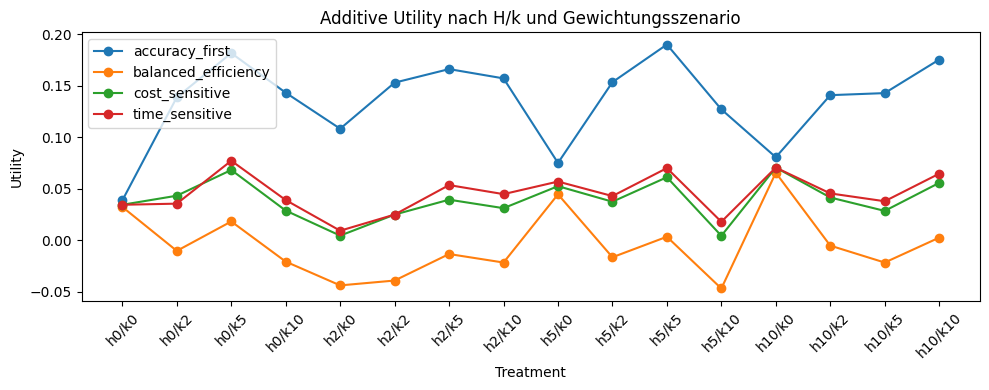

**Textbaustein.** Die Utility-Funktion macht den Zielkonflikt zwischen Erfolg, Tokenverbrauch und Laufzeit explizit. Ein Treatment ist nicht automatisch besser, weil es schneller oder guenstiger ist; es wird nur dann bevorzugt, wenn der Effizienzgewinn den moeglichen Erfolgsverlust gemaess der gewaehlten Gewichte ueberkompensiert.

In [16]:
def minmax_norm(series: pd.Series) -> pd.Series:
    series = pd.to_numeric(series, errors="coerce")
    lo = series.min()
    hi = series.max()
    if pd.isna(lo) or pd.isna(hi) or math.isclose(float(lo), float(hi)):
        return pd.Series(0.0, index=series.index)
    return (series - lo) / (hi - lo)

utility_base = (
    cost_df.groupby(["h", "k", "hk"])
    .agg(
        runs=("task_id", "count"),
        success_rate=("success", "mean"),
        avg_tokens=("total_tokens", "mean"),
        avg_runtime_s=("total_runtime_s", "mean"),
        avg_cost_usd=("estimated_token_cost_usd", "mean"),
    )
    .reset_index()
    .sort_values(["h", "k"])
)
utility_base["T_norm"] = minmax_norm(utility_base["avg_tokens"])
utility_base["runtime_norm"] = minmax_norm(utility_base["avg_runtime_s"])

WEIGHT_SCENARIOS = {
    "accuracy_first": {"alpha": 0.90, "beta": 0.05, "gamma": 0.05},
    "cost_sensitive": {"alpha": 0.80, "beta": 0.15, "gamma": 0.05},
    "time_sensitive": {"alpha": 0.80, "beta": 0.05, "gamma": 0.15},
    "balanced_efficiency": {"alpha": 0.75, "beta": 0.125, "gamma": 0.125},
}

utility_rows = []
for scenario, weights in WEIGHT_SCENARIOS.items():
    tmp = utility_base.copy()
    tmp["scenario"] = scenario
    tmp["alpha"] = weights["alpha"]
    tmp["beta"] = weights["beta"]
    tmp["gamma"] = weights["gamma"]
    tmp["utility"] = (
        tmp["alpha"] * tmp["success_rate"]
        - tmp["beta"] * tmp["T_norm"]
        - tmp["gamma"] * tmp["runtime_norm"]
    )
    utility_rows.append(tmp)
utility_df = pd.concat(utility_rows, ignore_index=True)

utility_rank = utility_df.sort_values(["scenario", "utility"], ascending=[True, False]).copy()
utility_rank["rank"] = utility_rank.groupby("scenario")["utility"].rank(method="first", ascending=False).astype(int)
display(utility_rank.sort_values(["scenario", "rank"]))

winner_table = utility_rank[utility_rank["rank"].eq(1)][["scenario", "hk", "success_rate", "avg_tokens", "avg_runtime_s", "utility"]]
display(winner_table)

if plt is not None:
    fig, ax = plt.subplots(figsize=(10, 4))
    for scenario, group in utility_df.groupby("scenario"):
        ordered = group.sort_values(["h", "k"])
        ax.plot(ordered["hk"], ordered["utility"], marker="o", label=scenario)
    ax.set_title("Additive Utility nach H/k und Gewichtungsszenario")
    ax.set_ylabel("Utility")
    ax.set_xlabel("Treatment")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

display(Markdown(
    "**Textbaustein.** Die Utility-Funktion macht den Zielkonflikt zwischen Erfolg, Tokenverbrauch und Laufzeit explizit. "
    "Ein Treatment ist nicht automatisch besser, weil es schneller oder guenstiger ist; es wird nur dann bevorzugt, wenn der Effizienzgewinn den moeglichen Erfolgsverlust gemaess der gewaehlten Gewichte ueberkompensiert."
))


## Additive Utility als Balkendiagramme

Diese Zusatzsektion visualisiert die additive Utility als Balkendiagramme. Sie ergänzt die marginale Success Rateslogik, indem für aggregierte H- und k-Ausprägungen jeweils Success Rate, Tokenverbrauch und Laufzeit neu aggregiert, normalisiert und anschließend je Gewichtungsszenario bewertet werden.



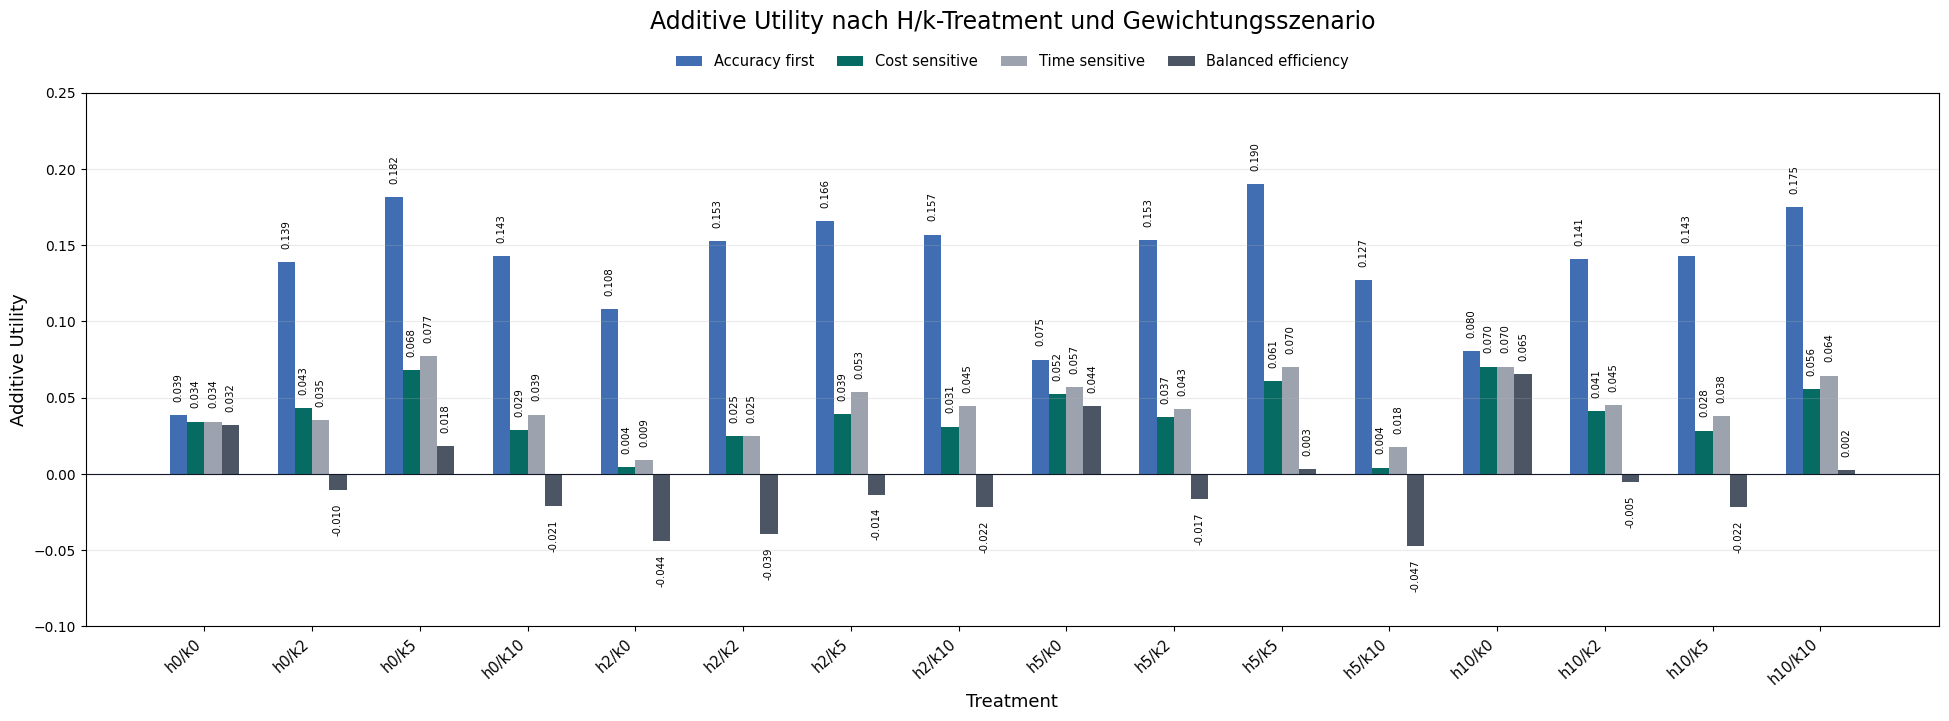

Wrote thesis_results_output/figures/fig_11_additive_utility_hk_bars.png


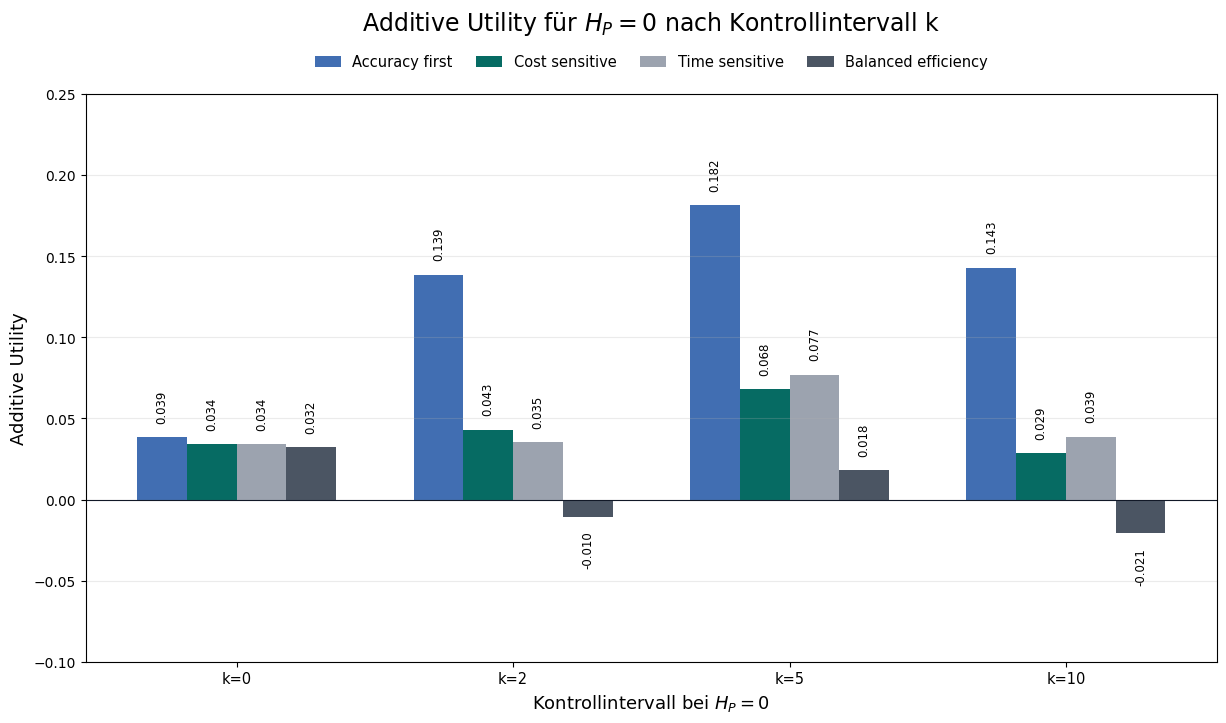

Wrote thesis_results_output/figures/fig_12_additive_utility_h0_by_k_bars.png


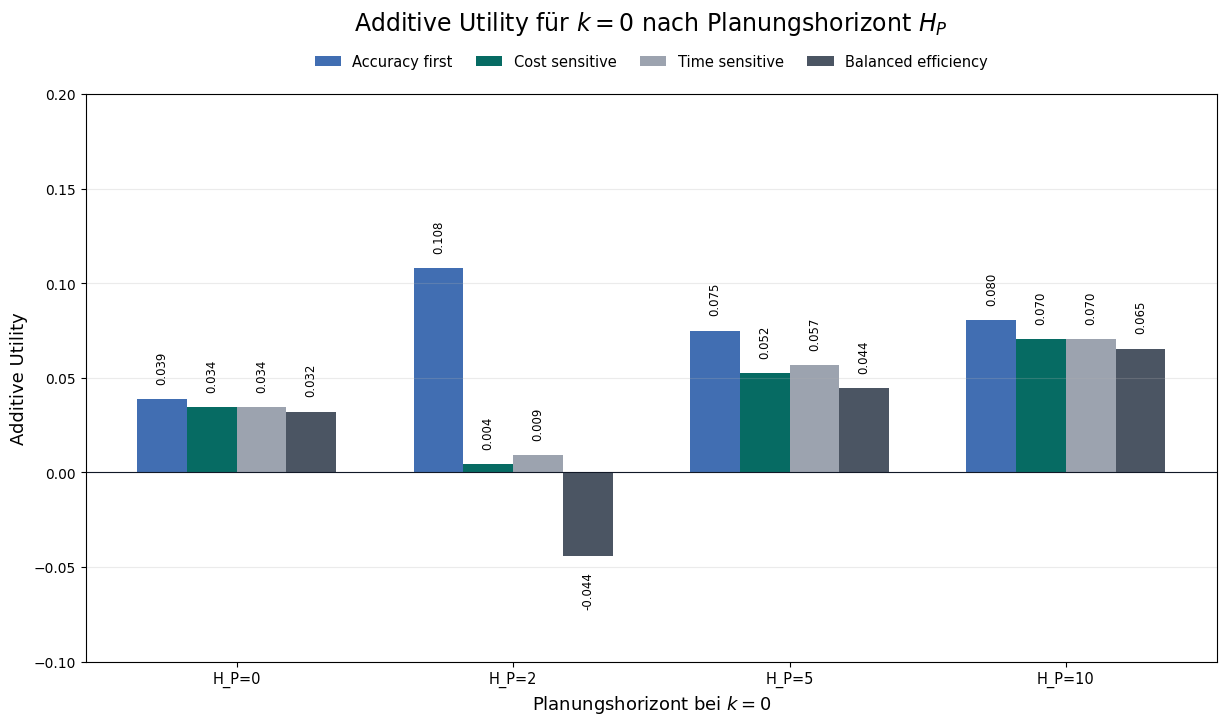

Wrote thesis_results_output/figures/fig_12b_additive_utility_k0_by_h_bars.png


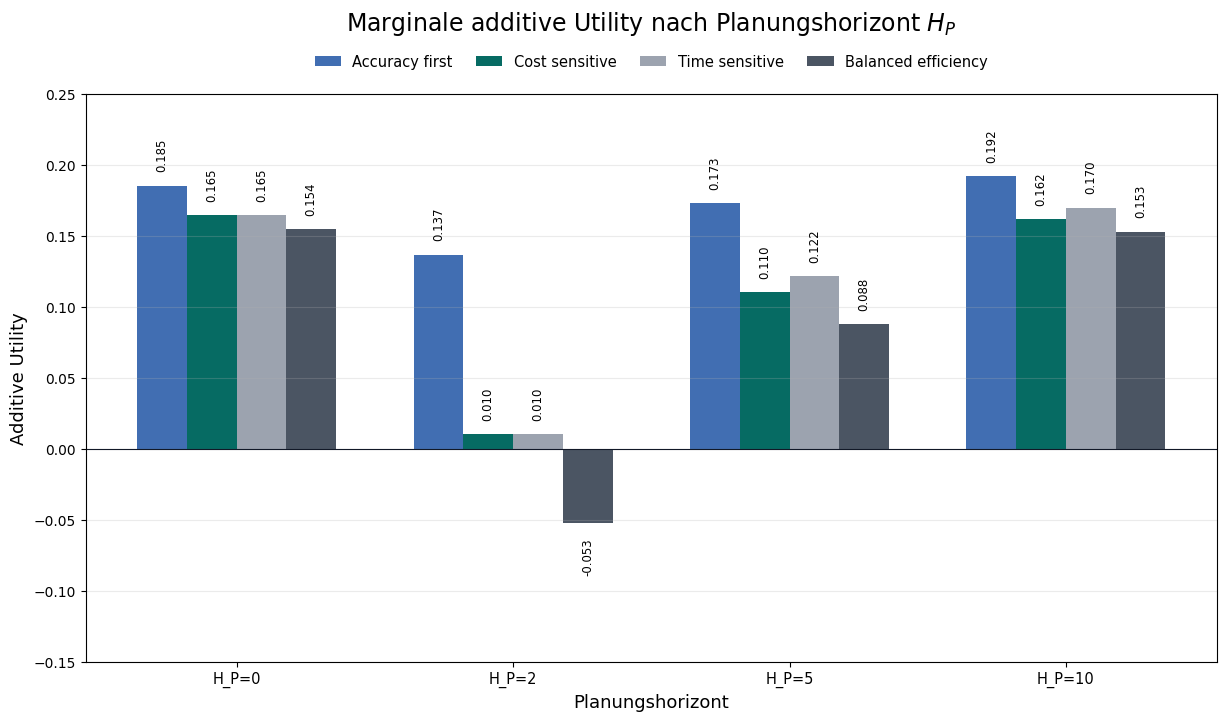

Wrote thesis_results_output/figures/fig_13_additive_utility_marginal_h_bars.png


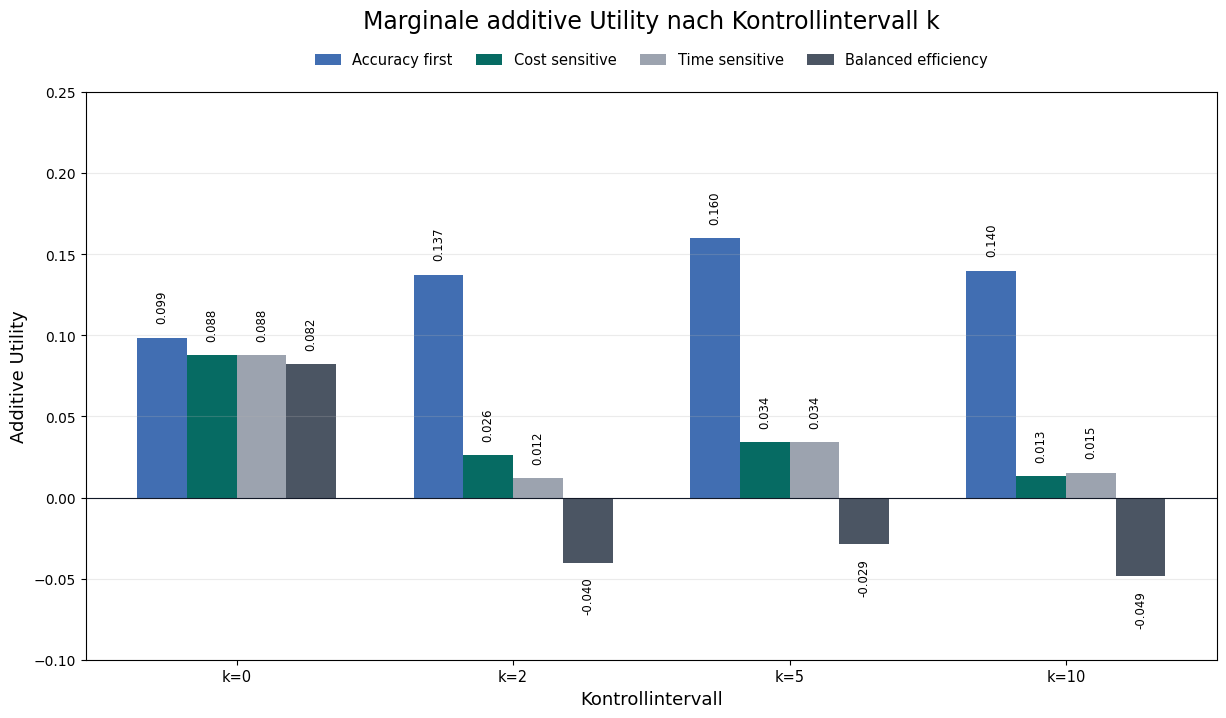

Wrote thesis_results_output/figures/fig_14_additive_utility_marginal_k_bars.png


,scenario,h,success_rate,avg_tokens,avg_runtime_s,T_norm,runtime_norm,utility
0,accuracy_first,0,0.205952,593966.930952,230.327146,0.000000,0.000000,0.185357
1,accuracy_first,2,0.263095,856777.619048,312.484431,1.000000,1.000000,0.136786
2,accuracy_first,5,0.229762,697780.415476,253.614136,0.395012,0.283444,0.172863
3,accuracy_first,10,0.217857,615481.216667,230.467888,0.081862,0.001713,0.191893
12,balanced_efficiency,0,0.205952,593966.930952,230.327146,0.000000,0.000000,0.154464
13,balanced_efficiency,2,0.263095,856777.619048,312.484431,1.000000,1.000000,-0.052679
14,balanced_efficiency,5,0.229762,697780.415476,253.614136,0.395012,0.283444,0.087514
15,balanced_efficiency,10,0.217857,615481.216667,230.467888,0.081862,0.001713,0.152946
4,cost_sensitive,0,0.205952,593966.930952,230.327146,0.000000,0.000000,0.164762
5,cost_sensitive,2,0.263095,856777.619048,312.484431,1.000000,1.000000,0.010476


,scenario,k,success_rate,avg_tokens,avg_runtime_s,T_norm,runtime_norm,utility
0,accuracy_first,0,0.109524,302966.784524,123.972570,0.000000,0.000000,0.098571
1,accuracy_first,2,0.255952,773048.727381,303.847307,0.857156,1.000000,0.137499
2,accuracy_first,5,0.285714,836603.559524,298.611537,0.973043,0.970892,0.159946
3,accuracy_first,10,0.265476,851387.110714,300.462187,1.000000,0.981181,0.139870
12,balanced_efficiency,0,0.109524,302966.784524,123.972570,0.000000,0.000000,0.082143
13,balanced_efficiency,2,0.255952,773048.727381,303.847307,0.857156,1.000000,-0.040180
14,balanced_efficiency,5,0.285714,836603.559524,298.611537,0.973043,0.970892,-0.028706
15,balanced_efficiency,10,0.265476,851387.110714,300.462187,1.000000,0.981181,-0.048540
4,cost_sensitive,0,0.109524,302966.784524,123.972570,0.000000,0.000000,0.087619
5,cost_sensitive,2,0.255952,773048.727381,303.847307,0.857156,1.000000,0.026188


In [17]:
def compute_additive_utility_for_groups(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    grouped = (
        df.groupby(group_cols, dropna=False)
        .agg(
            runs=("task_id", "count"),
            success_rate=("success", "mean"),
            avg_tokens=("total_tokens", "mean"),
            avg_runtime_s=("total_runtime_s", "mean"),
            avg_cost_usd=("estimated_token_cost_usd", "mean"),
        )
        .reset_index()
    )
    grouped["T_norm"] = minmax_norm(grouped["avg_tokens"])
    grouped["runtime_norm"] = minmax_norm(grouped["avg_runtime_s"])

    rows = []
    for scenario, weights in WEIGHT_SCENARIOS.items():
        tmp = grouped.copy()
        tmp["scenario"] = scenario
        tmp["alpha"] = weights["alpha"]
        tmp["beta"] = weights["beta"]
        tmp["gamma"] = weights["gamma"]
        tmp["utility"] = (
            tmp["alpha"] * tmp["success_rate"]
            - tmp["beta"] * tmp["T_norm"]
            - tmp["gamma"] * tmp["runtime_norm"]
        )
        rows.append(tmp)
    return pd.concat(rows, ignore_index=True)

SCENARIO_ORDER = ["accuracy_first", "cost_sensitive", "time_sensitive", "balanced_efficiency"]
SCENARIO_LABELS = {
    "accuracy_first": "Accuracy first",
    "cost_sensitive": "Cost sensitive",
    "time_sensitive": "Time sensitive",
    "balanced_efficiency": "Balanced efficiency",
}
SCENARIO_COLORS = {
    "accuracy_first": "#416eb2",
    "cost_sensitive": "#066b63",
    "time_sensitive": "#9CA3AF",
    "balanced_efficiency": "#4B5563",
}

def grouped_utility_ylim(values: np.ndarray, *, step: float = 0.05, margin: float = 0.05) -> tuple[float, float]:
    finite = values[np.isfinite(values)]
    ymin = float(finite.min())
    ymax = float(finite.max())
    lower = np.floor((ymin - margin) / step) * step if ymin < 0 else 0.0
    upper = np.ceil((ymax + margin) / step) * step
    return lower, max(0.2, upper)

def plot_grouped_utility_bars(
    df: pd.DataFrame,
    *,
    x_col: str,
    order: list[str],
    title: str,
    xlabel: str,
    output_name: str,
) -> None:
    if plt is None:
        return
    pivot = df.pivot(index=x_col, columns="scenario", values="utility").reindex(order)
    pivot = pivot[SCENARIO_ORDER]
    fig_width = max(12.5, len(order) * 1.28)
    fig_height = 8.6 if len(order) <= 6 else 9.2
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    x = np.arange(len(pivot.index))
    width = 0.18 if len(order) <= 6 else 0.16
    offsets = (np.arange(len(SCENARIO_ORDER)) - (len(SCENARIO_ORDER) - 1) / 2) * width
    ymin, ymax = grouped_utility_ylim(pivot.to_numpy(dtype=float))
    ax.set_ylim(ymin, ymax)
    label_offset = max(0.008, (ymax - ymin) * 0.025)
    for i, scenario in enumerate(SCENARIO_ORDER):
        values = pivot[scenario].values
        bars = ax.bar(
            x + offsets[i],
            values,
            width=width,
            label=SCENARIO_LABELS[scenario],
            color=SCENARIO_COLORS[scenario],
        )
        for bar, value in zip(bars, values):
            if pd.isna(value):
                continue
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + (label_offset if value >= 0 else -label_offset),
                f"{value:.3f}",
                ha="center",
                va="bottom" if value >= 0 else "top",
                fontsize=8.5 if len(order) <= 6 else 7.3,
                rotation=90,
                clip_on=False,
            )
    ax.axhline(0, color="#111827", linewidth=0.8)
    ax.set_title(title, fontsize=17, pad=46)
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel("Additive Utility", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(
        pivot.index,
        rotation=42 if len(order) > 6 else 0,
        ha="right" if len(order) > 6 else "center",
        fontsize=10.5,
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend(
        ncol=4,
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        fontsize=10.5,
        columnspacing=1.6,
        handlelength=1.8,
    )
    fig.subplots_adjust(left=0.08, right=0.985, top=0.80, bottom=0.22 if len(order) > 6 else 0.14)
    out_path = FIG_DIR / output_name
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path.relative_to(ROOT)}")

FIG_DIR = ROOT / "thesis_results_output" / "figures"
TABLE_DIR = ROOT / "thesis_results_output" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

hk_utility_bars = compute_additive_utility_for_groups(cost_df, ["h", "k", "hk"]).sort_values(["scenario", "h", "k"])
h0_utility_bars = hk_utility_bars[hk_utility_bars["h"].eq(0)].copy()
h0_utility_bars["k_label"] = "k=" + h0_utility_bars["k"].astype(int).astype(str)

k0_utility_bars = hk_utility_bars[hk_utility_bars["k"].eq(0)].copy()
k0_utility_bars["h_label"] = "H_P=" + k0_utility_bars["h"].astype(int).astype(str)

marginal_h_utility = compute_additive_utility_for_groups(cost_df, ["h"]).sort_values(["scenario", "h"])
marginal_h_utility["h_label"] = "H_P=" + marginal_h_utility["h"].astype(int).astype(str)

marginal_k_utility = compute_additive_utility_for_groups(cost_df, ["k"]).sort_values(["scenario", "k"])
marginal_k_utility["k_label"] = "k=" + marginal_k_utility["k"].astype(int).astype(str)

hk_utility_bars.to_csv(TABLE_DIR / "additive_utility_hk_by_scenario.csv", index=False)
h0_utility_bars.to_csv(TABLE_DIR / "additive_utility_h0_by_k_scenario.csv", index=False)
k0_utility_bars.to_csv(TABLE_DIR / "additive_utility_k0_by_h_scenario.csv", index=False)
marginal_h_utility.to_csv(TABLE_DIR / "additive_utility_marginal_h_scenario.csv", index=False)
marginal_k_utility.to_csv(TABLE_DIR / "additive_utility_marginal_k_scenario.csv", index=False)

plot_grouped_utility_bars(
    hk_utility_bars,
    x_col="hk",
    order=[hk_label(h, k) for h in PREFERRED_HK_ORDER for k in PREFERRED_HK_ORDER],
    title="Additive Utility nach H/k-Treatment und Gewichtungsszenario",
    xlabel="Treatment",
    output_name="fig_11_additive_utility_hk_bars.png",
)
plot_grouped_utility_bars(
    h0_utility_bars,
    x_col="k_label",
    order=["k=0", "k=2", "k=5", "k=10"],
    title="Additive Utility für $H_P=0$ nach Kontrollintervall k",
    xlabel="Kontrollintervall bei $H_P=0$",
    output_name="fig_12_additive_utility_h0_by_k_bars.png",
)
plot_grouped_utility_bars(
    k0_utility_bars,
    x_col="h_label",
    order=["H_P=0", "H_P=2", "H_P=5", "H_P=10"],
    title="Additive Utility für $k=0$ nach Planungshorizont $H_P$",
    xlabel="Planungshorizont bei $k=0$",
    output_name="fig_12b_additive_utility_k0_by_h_bars.png",
)
plot_grouped_utility_bars(
    marginal_h_utility,
    x_col="h_label",
    order=["H_P=0", "H_P=2", "H_P=5", "H_P=10"],
    title="Marginale additive Utility nach Planungshorizont $H_P$",
    xlabel="Planungshorizont",
    output_name="fig_13_additive_utility_marginal_h_bars.png",
)
plot_grouped_utility_bars(
    marginal_k_utility,
    x_col="k_label",
    order=["k=0", "k=2", "k=5", "k=10"],
    title="Marginale additive Utility nach Kontrollintervall k",
    xlabel="Kontrollintervall",
    output_name="fig_14_additive_utility_marginal_k_bars.png",
)

display(marginal_h_utility[["scenario", "h", "success_rate", "avg_tokens", "avg_runtime_s", "T_norm", "runtime_norm", "utility"]])
display(marginal_k_utility[["scenario", "k", "success_rate", "avg_tokens", "avg_runtime_s", "T_norm", "runtime_norm", "utility"]])





## Standard-Utility \(90/5/5\) als Einzelbalkendiagramme

Diese Zusatzgrafiken zeigen nur das Standard-Gewichtungsprofil `accuracy_first` mit `alpha=0.90`, `beta=0.05` und `gamma=0.05`. Dadurch entfallen die gruppierten Balken der Szenariovergleiche und die H/k-Unterschiede sind einfacher lesbar.



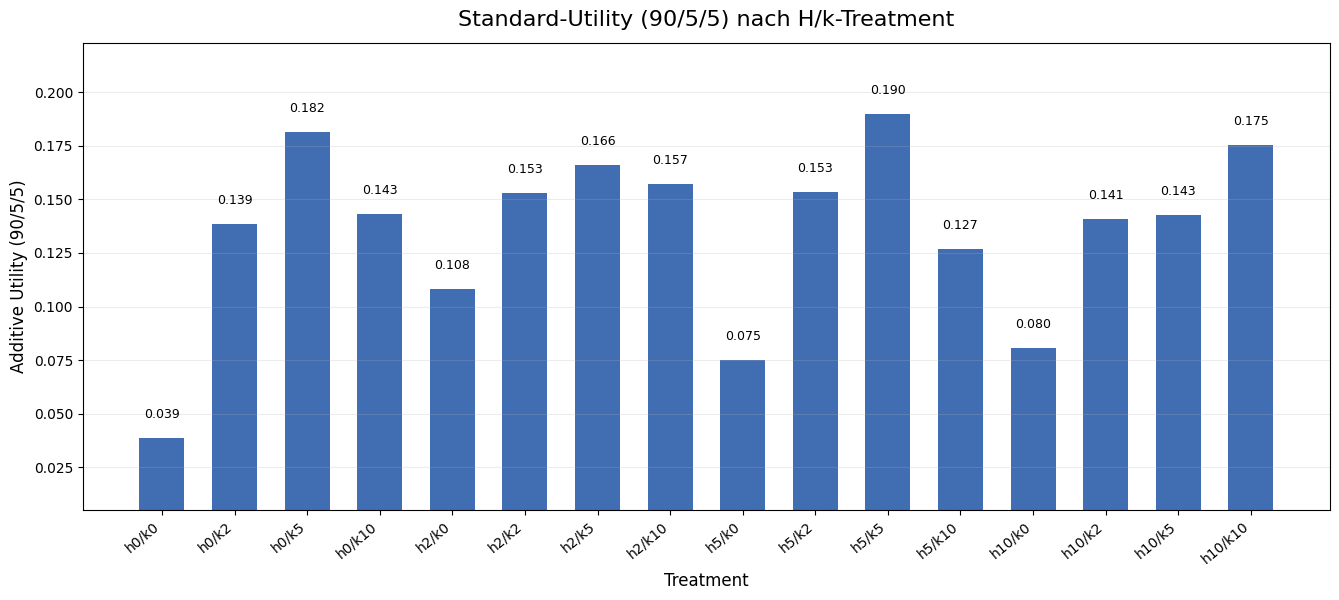

Wrote thesis_results_output/figures/fig_11b_standard_utility_hk_bars.png


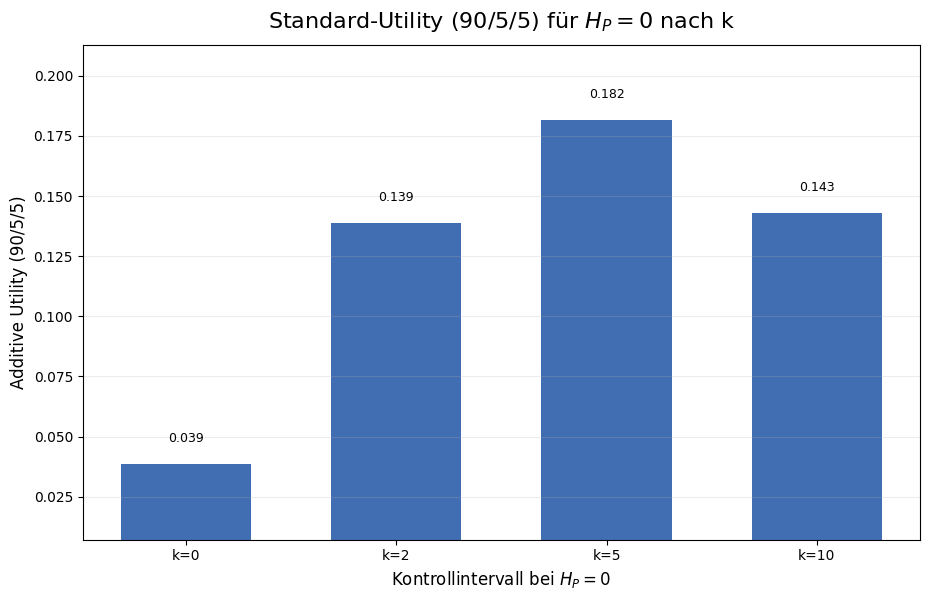

Wrote thesis_results_output/figures/fig_12c_standard_utility_h0_by_k_bars.png


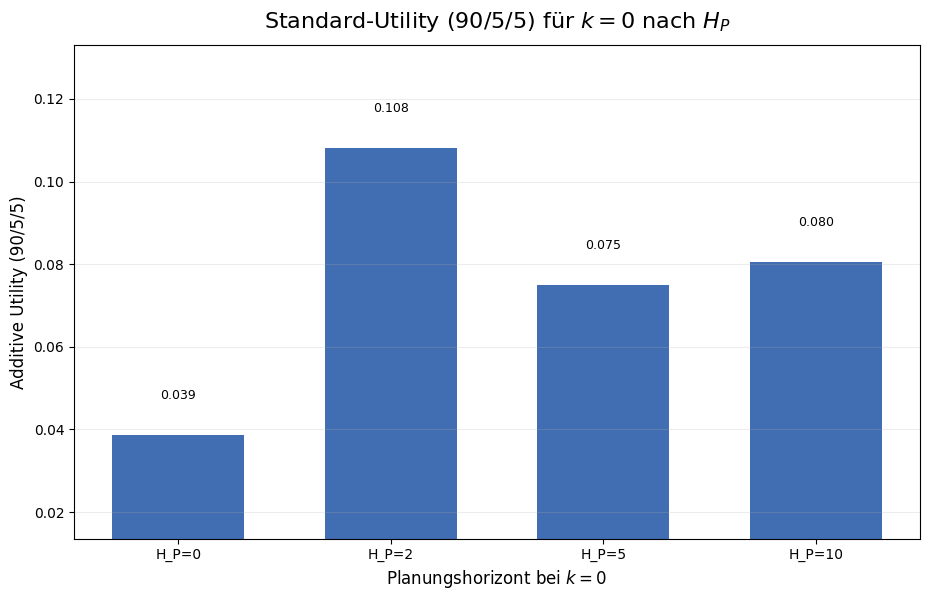

Wrote thesis_results_output/figures/fig_12d_standard_utility_k0_by_h_bars.png


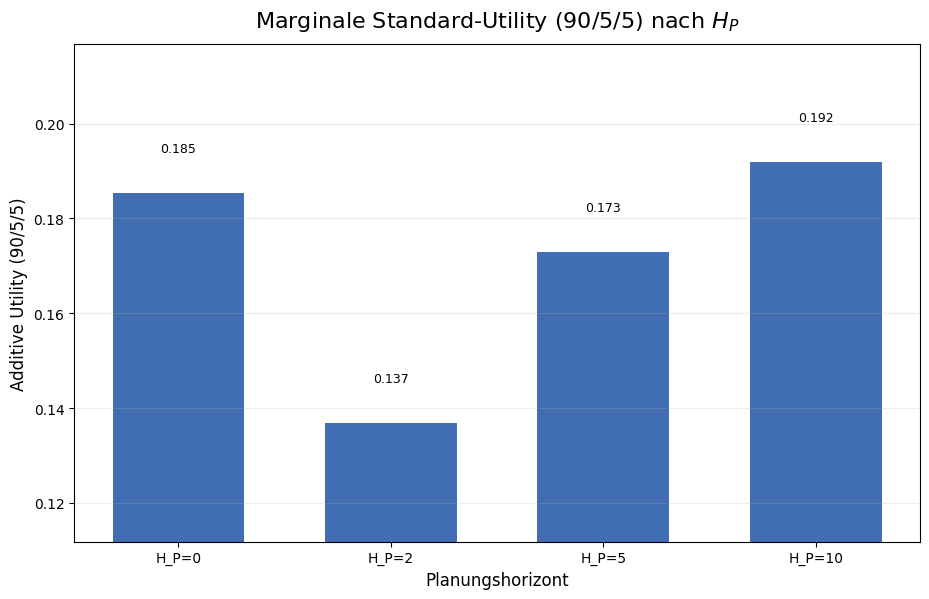

Wrote thesis_results_output/figures/fig_13b_standard_utility_marginal_h_bars.png


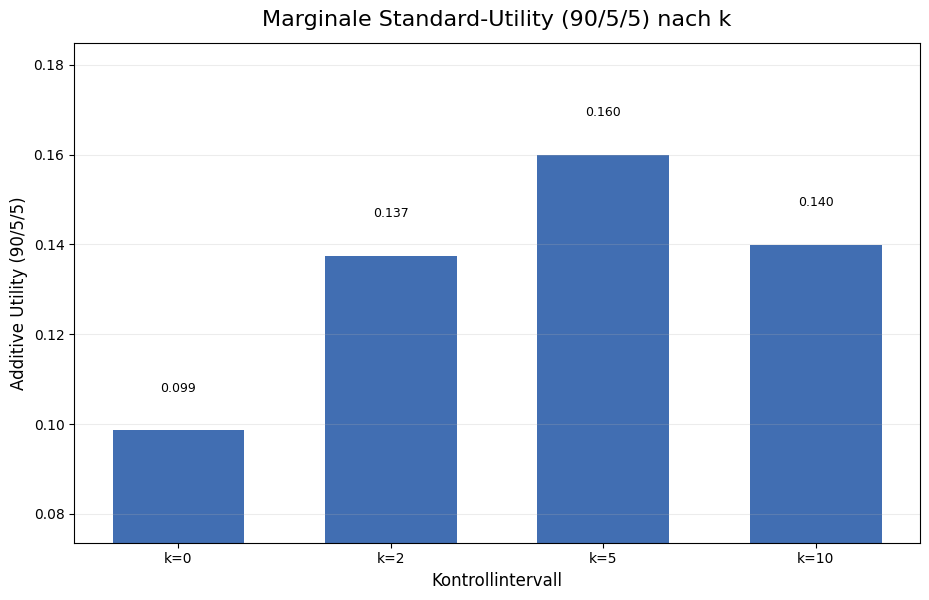

Wrote thesis_results_output/figures/fig_14b_standard_utility_marginal_k_bars.png


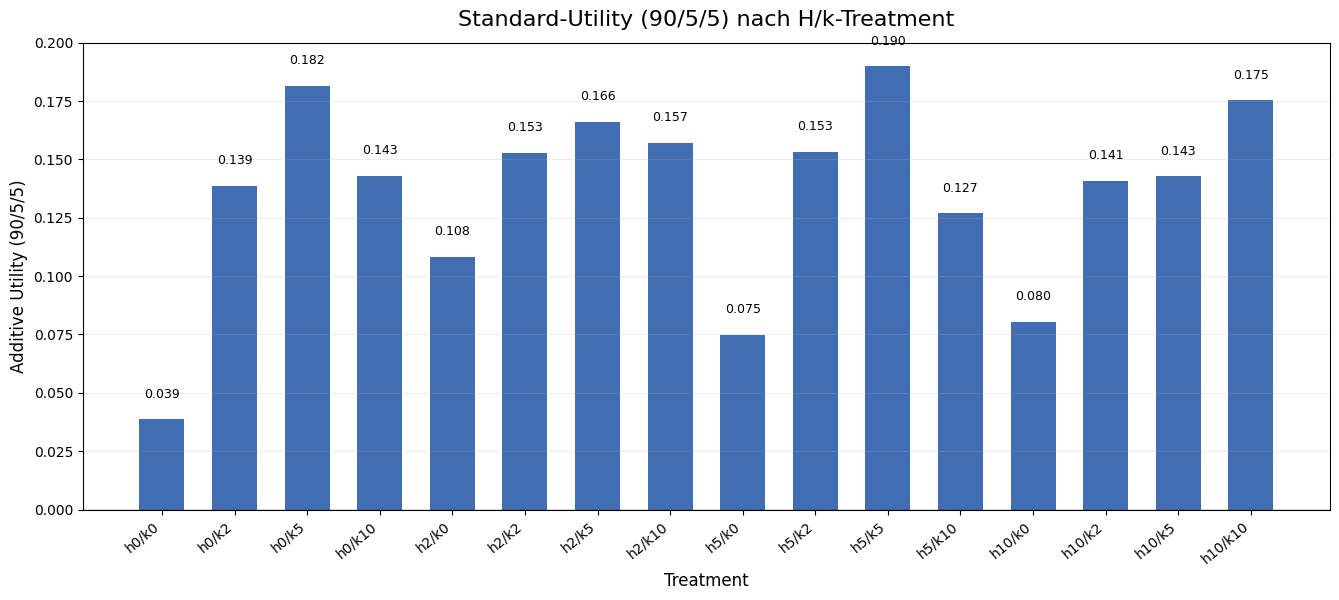

Wrote thesis_results_output/figures/fig_11b_standard_utility_hk_bars.png


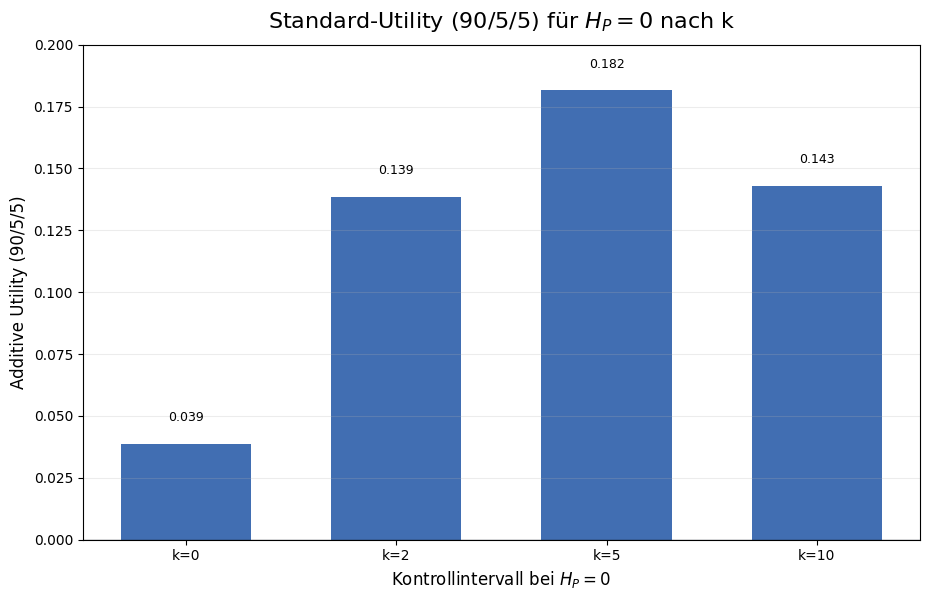

Wrote thesis_results_output/figures/fig_12c_standard_utility_h0_by_k_bars.png


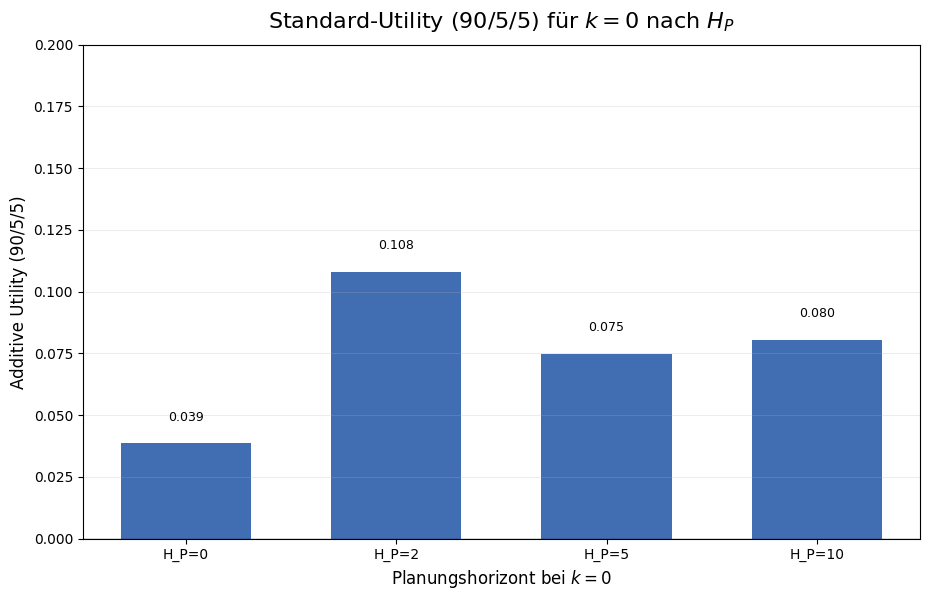

Wrote thesis_results_output/figures/fig_12d_standard_utility_k0_by_h_bars.png


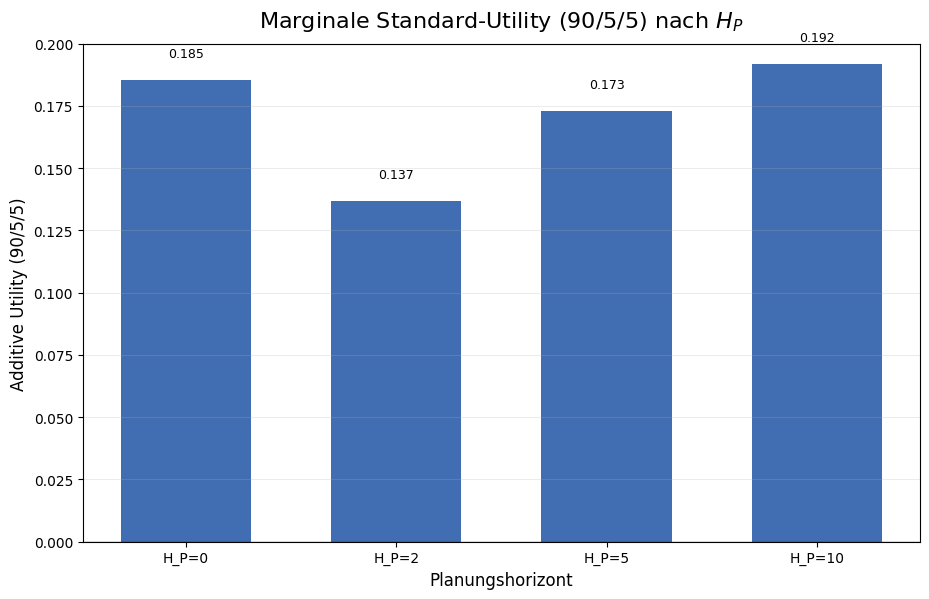

Wrote thesis_results_output/figures/fig_13b_standard_utility_marginal_h_bars.png


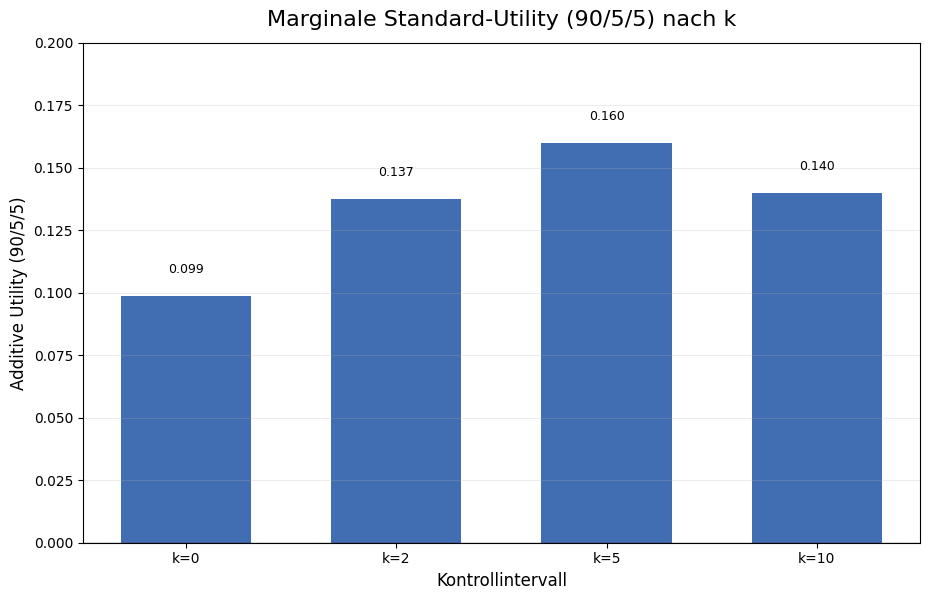

Wrote thesis_results_output/figures/fig_14b_standard_utility_marginal_k_bars.png


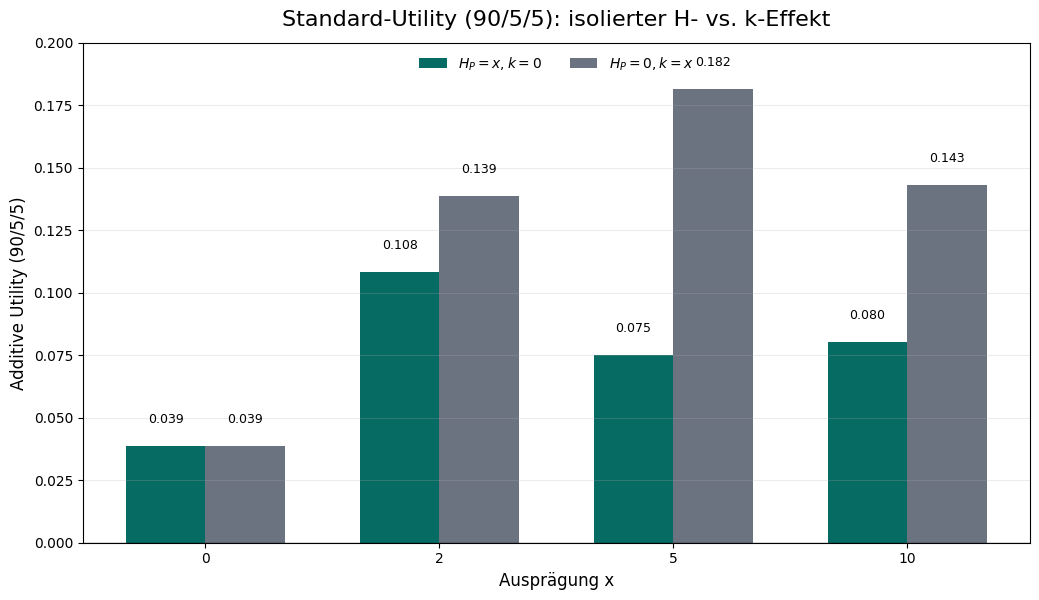

Wrote thesis_results_output/figures/fig_15_standard_utility_axis_zero_comparison_bars.png


,value,series,utility,hk
0,0,"H_P=x, k=0",0.038571,h0/k0
1,0,"H_P=0, k=x",0.038571,h0/k0
2,2,"H_P=x, k=0",0.108114,h2/k0
3,2,"H_P=0, k=x",0.138660,h0/k2
4,5,"H_P=x, k=0",0.074908,h5/k0
5,5,"H_P=0, k=x",0.181510,h0/k5
6,10,"H_P=x, k=0",0.080435,h10/k0
7,10,"H_P=0, k=x",0.143057,h0/k10


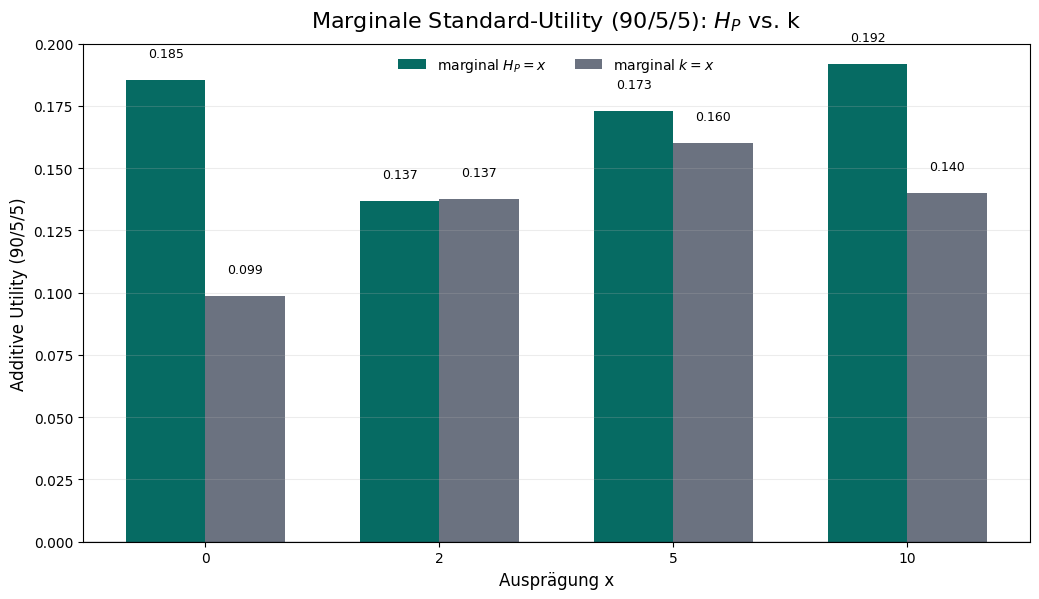

Wrote thesis_results_output/figures/fig_16_standard_utility_marginal_h_vs_k_comparison_bars.png


,value,series,utility,success_rate,avg_tokens,avg_runtime_s
0,0,marginal H_P=x,0.185357,0.205952,593966.930952,230.327146
1,0,marginal k=x,0.098571,0.109524,302966.784524,123.972570
2,2,marginal H_P=x,0.136786,0.263095,856777.619048,312.484431
3,2,marginal k=x,0.137499,0.255952,773048.727381,303.847307
4,5,marginal H_P=x,0.172863,0.229762,697780.415476,253.614136
5,5,marginal k=x,0.159946,0.285714,836603.559524,298.611537
6,10,marginal H_P=x,0.191893,0.217857,615481.216667,230.467888
7,10,marginal k=x,0.139870,0.265476,851387.110714,300.462187


In [18]:
STANDARD_SCENARIO = "accuracy_first"
STANDARD_WEIGHTS = WEIGHT_SCENARIOS[STANDARD_SCENARIO]
STANDARD_COLOR = "#416eb2"

def compute_standard_utility_for_groups(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    grouped = (
        df.groupby(group_cols, dropna=False)
        .agg(
            runs=("task_id", "count"),
            success_rate=("success", "mean"),
            avg_tokens=("total_tokens", "mean"),
            avg_runtime_s=("total_runtime_s", "mean"),
            avg_cost_usd=("estimated_token_cost_usd", "mean"),
        )
        .reset_index()
    )
    grouped["T_norm"] = minmax_norm(grouped["avg_tokens"])
    grouped["runtime_norm"] = minmax_norm(grouped["avg_runtime_s"])
    grouped["scenario"] = STANDARD_SCENARIO
    grouped["alpha"] = STANDARD_WEIGHTS["alpha"]
    grouped["beta"] = STANDARD_WEIGHTS["beta"]
    grouped["gamma"] = STANDARD_WEIGHTS["gamma"]
    grouped["utility"] = (
        grouped["alpha"] * grouped["success_rate"]
        - grouped["beta"] * grouped["T_norm"]
        - grouped["gamma"] * grouped["runtime_norm"]
    )
    return grouped

def plot_single_standard_utility_bars(
    df: pd.DataFrame,
    *,
    x_col: str,
    order: list[str],
    title: str,
    xlabel: str,
    output_name: str,
    fig_width: float | None = None,
) -> None:
    if plt is None:
        return
    plot_df = df.set_index(x_col).reindex(order).reset_index()
    fig, ax = plt.subplots(figsize=(fig_width or max(9.4, len(order) * 0.82), 6.1))
    x = np.arange(len(plot_df))
    values = plot_df["utility"].values
    bars = ax.bar(x, values, color=STANDARD_COLOR, width=0.62)
    ymin = float(np.nanmin(values))
    ymax = float(np.nanmax(values))
    pad = max(0.025, (ymax - ymin) * 0.22)
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + (0.008 if value >= 0 else -0.008),
            f"{value:.3f}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=9,
            clip_on=False,
        )
    ax.axhline(0, color="#111827", linewidth=0.9)
    ax.set_title(title, fontsize=16, pad=12)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Additive Utility (90/5/5)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(
        order,
        rotation=40 if len(order) > 6 else 0,
        ha="right" if len(order) > 6 else "center",
    )
    ax.grid(axis="y", alpha=0.24)
    ax.set_ylim(ymin - pad, ymax + pad)
    fig.tight_layout()
    out_path = FIG_DIR / output_name
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path.relative_to(ROOT)}")

standard_hk_utility = compute_standard_utility_for_groups(cost_df, ["h", "k", "hk"]).sort_values(["h", "k"])
standard_h0_utility = standard_hk_utility[standard_hk_utility["h"].eq(0)].copy()
standard_h0_utility["k_label"] = "k=" + standard_h0_utility["k"].astype(int).astype(str)
standard_k0_utility = standard_hk_utility[standard_hk_utility["k"].eq(0)].copy()
standard_k0_utility["h_label"] = "H_P=" + standard_k0_utility["h"].astype(int).astype(str)
standard_marginal_h_utility = compute_standard_utility_for_groups(cost_df, ["h"]).sort_values("h")
standard_marginal_h_utility["h_label"] = "H_P=" + standard_marginal_h_utility["h"].astype(int).astype(str)
standard_marginal_k_utility = compute_standard_utility_for_groups(cost_df, ["k"]).sort_values("k")
standard_marginal_k_utility["k_label"] = "k=" + standard_marginal_k_utility["k"].astype(int).astype(str)

standard_hk_utility.to_csv(TABLE_DIR / "standard_utility_hk.csv", index=False)
standard_h0_utility.to_csv(TABLE_DIR / "standard_utility_h0_by_k.csv", index=False)
standard_k0_utility.to_csv(TABLE_DIR / "standard_utility_k0_by_h.csv", index=False)
standard_marginal_h_utility.to_csv(TABLE_DIR / "standard_utility_marginal_h.csv", index=False)
standard_marginal_k_utility.to_csv(TABLE_DIR / "standard_utility_marginal_k.csv", index=False)

plot_single_standard_utility_bars(
    standard_hk_utility,
    x_col="hk",
    order=[hk_label(h, k) for h in PREFERRED_HK_ORDER for k in PREFERRED_HK_ORDER],
    title="Standard-Utility (90/5/5) nach H/k-Treatment",
    xlabel="Treatment",
    output_name="fig_11b_standard_utility_hk_bars.png",
    fig_width=13.5,
)
plot_single_standard_utility_bars(
    standard_h0_utility,
    x_col="k_label",
    order=["k=0", "k=2", "k=5", "k=10"],
    title="Standard-Utility (90/5/5) für $H_P=0$ nach k",
    xlabel="Kontrollintervall bei $H_P=0$",
    output_name="fig_12c_standard_utility_h0_by_k_bars.png",
)
plot_single_standard_utility_bars(
    standard_k0_utility,
    x_col="h_label",
    order=["H_P=0", "H_P=2", "H_P=5", "H_P=10"],
    title="Standard-Utility (90/5/5) für $k=0$ nach $H_P$",
    xlabel="Planungshorizont bei $k=0$",
    output_name="fig_12d_standard_utility_k0_by_h_bars.png",
)
plot_single_standard_utility_bars(
    standard_marginal_h_utility,
    x_col="h_label",
    order=["H_P=0", "H_P=2", "H_P=5", "H_P=10"],
    title="Marginale Standard-Utility (90/5/5) nach $H_P$",
    xlabel="Planungshorizont",
    output_name="fig_13b_standard_utility_marginal_h_bars.png",
)
plot_single_standard_utility_bars(
    standard_marginal_k_utility,
    x_col="k_label",
    order=["k=0", "k=2", "k=5", "k=10"],
    title="Marginale Standard-Utility (90/5/5) nach k",
    xlabel="Kontrollintervall",
    output_name="fig_14b_standard_utility_marginal_k_bars.png",
)



def rounded_upper_ylim(ymax: float, *, step: float, minimum: float) -> float:
    return max(minimum, np.ceil(ymax / step) * step)

def standard_utility_common_ylim(*frames: pd.DataFrame) -> tuple[float, float]:
    values = np.concatenate([frame["utility"].dropna().to_numpy() for frame in frames])
    ymin = float(values.min())
    ymax = float(values.max())
    upper = rounded_upper_ylim(ymax, step=0.1, minimum=0.2)
    lower = min(0.0, np.floor((ymin - 0.01) / 0.1) * 0.1)
    return lower, upper

def plot_single_standard_utility_bars_scaled(
    df: pd.DataFrame,
    *,
    x_col: str,
    order: list[str],
    title: str,
    xlabel: str,
    output_name: str,
    ylim: tuple[float, float],
    fig_width: float | None = None,
) -> None:
    if plt is None:
        return
    plot_df = df.set_index(x_col).reindex(order).reset_index()
    fig, ax = plt.subplots(figsize=(fig_width or max(9.4, len(order) * 0.82), 6.1))
    x = np.arange(len(plot_df))
    values = plot_df["utility"].values
    bars = ax.bar(x, values, color=STANDARD_COLOR, width=0.62)
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + (0.008 if value >= 0 else -0.008),
            f"{value:.3f}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=9,
            clip_on=False,
        )
    ax.axhline(0, color="#111827", linewidth=0.9)
    ax.set_title(title, fontsize=16, pad=12)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Additive Utility (90/5/5)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=40 if len(order) > 6 else 0, ha="right" if len(order) > 6 else "center")
    ax.grid(axis="y", alpha=0.24)
    ax.set_ylim(*ylim)
    fig.tight_layout()
    out_path = FIG_DIR / output_name
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path.relative_to(ROOT)}")

def plot_standard_axis_zero_comparison(hk_df: pd.DataFrame, *, ylim: tuple[float, float]) -> pd.DataFrame:
    rows = []
    for value in PREFERRED_HK_ORDER:
        hp_row = hk_df.loc[hk_df["h"].eq(value) & hk_df["k"].eq(0)].iloc[0]
        k_row = hk_df.loc[hk_df["h"].eq(0) & hk_df["k"].eq(value)].iloc[0]
        rows.append({"value": value, "series": "H_P=x, k=0", "utility": hp_row["utility"], "hk": hp_row["hk"]})
        rows.append({"value": value, "series": "H_P=0, k=x", "utility": k_row["utility"], "hk": k_row["hk"]})
    comp = pd.DataFrame(rows)
    comp.to_csv(TABLE_DIR / "standard_utility_axis_zero_comparison.csv", index=False)
    pivot = comp.pivot(index="value", columns="series", values="utility").reindex(PREFERRED_HK_ORDER)
    fig, ax = plt.subplots(figsize=(10.5, 6.1))
    x = np.arange(len(PREFERRED_HK_ORDER))
    width = 0.34
    bars1 = ax.bar(x - width / 2, pivot["H_P=x, k=0"].values, width=width, color="#066b63", label="$H_P=x, k=0$")
    bars2 = ax.bar(x + width / 2, pivot["H_P=0, k=x"].values, width=width, color="#6B7280", label="$H_P=0, k=x$")
    for bars in [bars1, bars2]:
        for bar in bars:
            value = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, value + (0.008 if value >= 0 else -0.008), f"{value:.3f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9, clip_on=False)
    ax.axhline(0, color="#111827", linewidth=0.9)
    ax.set_title("Standard-Utility (90/5/5): isolierter H- vs. k-Effekt", fontsize=16, pad=12)
    ax.set_xlabel("Ausprägung x", fontsize=12)
    ax.set_ylabel("Additive Utility (90/5/5)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([str(value) for value in PREFERRED_HK_ORDER])
    ax.grid(axis="y", alpha=0.24)
    ax.legend(frameon=False, loc="upper center", ncol=2)
    ax.set_ylim(*ylim)
    fig.tight_layout()
    out_path = FIG_DIR / "fig_15_standard_utility_axis_zero_comparison_bars.png"
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path.relative_to(ROOT)}")
    return comp

standard_common_ylim = standard_utility_common_ylim(
    standard_hk_utility,
    standard_h0_utility,
    standard_k0_utility,
    standard_marginal_h_utility,
    standard_marginal_k_utility,
)

plot_single_standard_utility_bars_scaled(
    standard_hk_utility,
    x_col="hk",
    order=[hk_label(h, k) for h in PREFERRED_HK_ORDER for k in PREFERRED_HK_ORDER],
    title="Standard-Utility (90/5/5) nach H/k-Treatment",
    xlabel="Treatment",
    output_name="fig_11b_standard_utility_hk_bars.png",
    ylim=standard_common_ylim,
    fig_width=13.5,
)
plot_single_standard_utility_bars_scaled(
    standard_h0_utility,
    x_col="k_label",
    order=["k=0", "k=2", "k=5", "k=10"],
    title="Standard-Utility (90/5/5) für $H_P=0$ nach k",
    xlabel="Kontrollintervall bei $H_P=0$",
    output_name="fig_12c_standard_utility_h0_by_k_bars.png",
    ylim=standard_common_ylim,
)
plot_single_standard_utility_bars_scaled(
    standard_k0_utility,
    x_col="h_label",
    order=["H_P=0", "H_P=2", "H_P=5", "H_P=10"],
    title="Standard-Utility (90/5/5) für $k=0$ nach $H_P$",
    xlabel="Planungshorizont bei $k=0$",
    output_name="fig_12d_standard_utility_k0_by_h_bars.png",
    ylim=standard_common_ylim,
)
plot_single_standard_utility_bars_scaled(
    standard_marginal_h_utility,
    x_col="h_label",
    order=["H_P=0", "H_P=2", "H_P=5", "H_P=10"],
    title="Marginale Standard-Utility (90/5/5) nach $H_P$",
    xlabel="Planungshorizont",
    output_name="fig_13b_standard_utility_marginal_h_bars.png",
    ylim=standard_common_ylim,
)
plot_single_standard_utility_bars_scaled(
    standard_marginal_k_utility,
    x_col="k_label",
    order=["k=0", "k=2", "k=5", "k=10"],
    title="Marginale Standard-Utility (90/5/5) nach k",
    xlabel="Kontrollintervall",
    output_name="fig_14b_standard_utility_marginal_k_bars.png",
    ylim=standard_common_ylim,
)
standard_axis_zero_comparison = plot_standard_axis_zero_comparison(standard_hk_utility, ylim=standard_common_ylim)
display(standard_axis_zero_comparison)



def plot_standard_marginal_h_vs_k_comparison(
    marginal_h_df: pd.DataFrame,
    marginal_k_df: pd.DataFrame,
    *,
    ylim: tuple[float, float],
) -> pd.DataFrame:
    rows = []
    for value in PREFERRED_HK_ORDER:
        h_row = marginal_h_df.loc[marginal_h_df["h"].eq(value)].iloc[0]
        k_row = marginal_k_df.loc[marginal_k_df["k"].eq(value)].iloc[0]
        rows.append({
            "value": value,
            "series": "marginal H_P=x",
            "utility": h_row["utility"],
            "success_rate": h_row["success_rate"],
            "avg_tokens": h_row["avg_tokens"],
            "avg_runtime_s": h_row["avg_runtime_s"],
        })
        rows.append({
            "value": value,
            "series": "marginal k=x",
            "utility": k_row["utility"],
            "success_rate": k_row["success_rate"],
            "avg_tokens": k_row["avg_tokens"],
            "avg_runtime_s": k_row["avg_runtime_s"],
        })
    comp = pd.DataFrame(rows)
    comp.to_csv(TABLE_DIR / "standard_utility_marginal_h_vs_k_comparison.csv", index=False)
    pivot = comp.pivot(index="value", columns="series", values="utility").reindex(PREFERRED_HK_ORDER)
    fig, ax = plt.subplots(figsize=(10.5, 6.1))
    x = np.arange(len(PREFERRED_HK_ORDER))
    width = 0.34
    bars1 = ax.bar(x - width / 2, pivot["marginal H_P=x"].values, width=width, color="#066b63", label="marginal $H_P=x$")
    bars2 = ax.bar(x + width / 2, pivot["marginal k=x"].values, width=width, color="#6B7280", label="marginal $k=x$")
    for bars in [bars1, bars2]:
        for bar in bars:
            value = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, value + (0.008 if value >= 0 else -0.008), f"{value:.3f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9, clip_on=False)
    ax.axhline(0, color="#111827", linewidth=0.9)
    ax.set_title("Marginale Standard-Utility (90/5/5): $H_P$ vs. k", fontsize=16, pad=12)
    ax.set_xlabel("Ausprägung x", fontsize=12)
    ax.set_ylabel("Additive Utility (90/5/5)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([str(value) for value in PREFERRED_HK_ORDER])
    ax.grid(axis="y", alpha=0.24)
    ax.legend(frameon=False, loc="upper center", ncol=2)
    ax.set_ylim(*ylim)
    fig.tight_layout()
    out_path = FIG_DIR / "fig_16_standard_utility_marginal_h_vs_k_comparison_bars.png"
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path.relative_to(ROOT)}")
    return comp

standard_marginal_h_vs_k_comparison = plot_standard_marginal_h_vs_k_comparison(
    standard_marginal_h_utility,
    standard_marginal_k_utility,
    ylim=standard_common_ylim,
)
display(standard_marginal_h_vs_k_comparison)




## Success-Rate-Grafiken in Prozentdarstellung

Die folgenden Abbildungen zeigen ausschließlich Success Rates in Prozent. Sie werden unter `success_*`-Dateinamen gespeichert; ältere `*_utility*_pct`-Grafiken aus einer missverständlichen Zwischenversion werden beim Ausführen der Zelle entfernt.



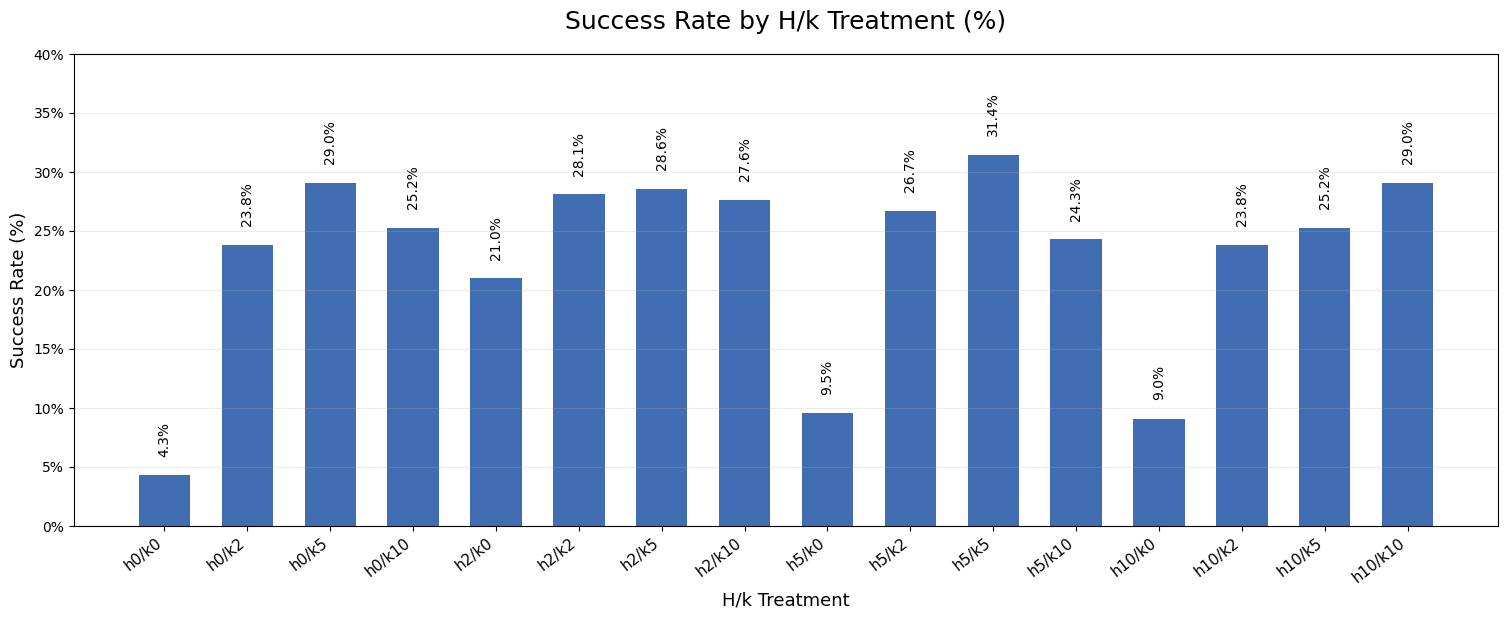

Wrote thesis_results_output/figures/fig_11_success_hk_bars_pct.png


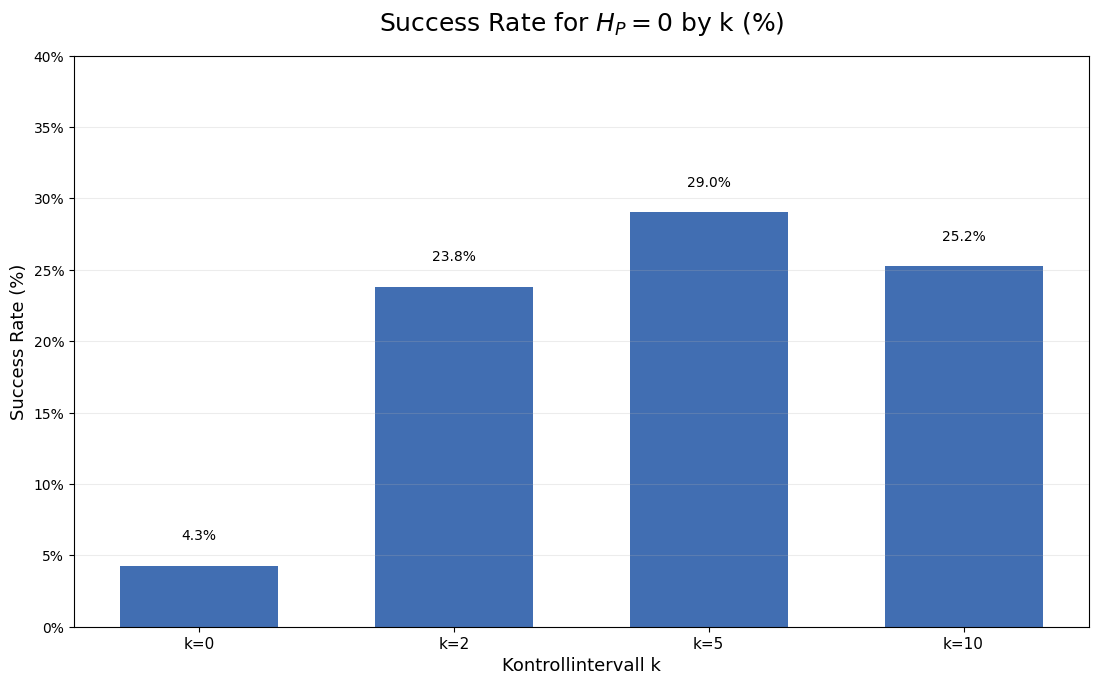

Wrote thesis_results_output/figures/fig_12_success_h0_by_k_bars_pct.png


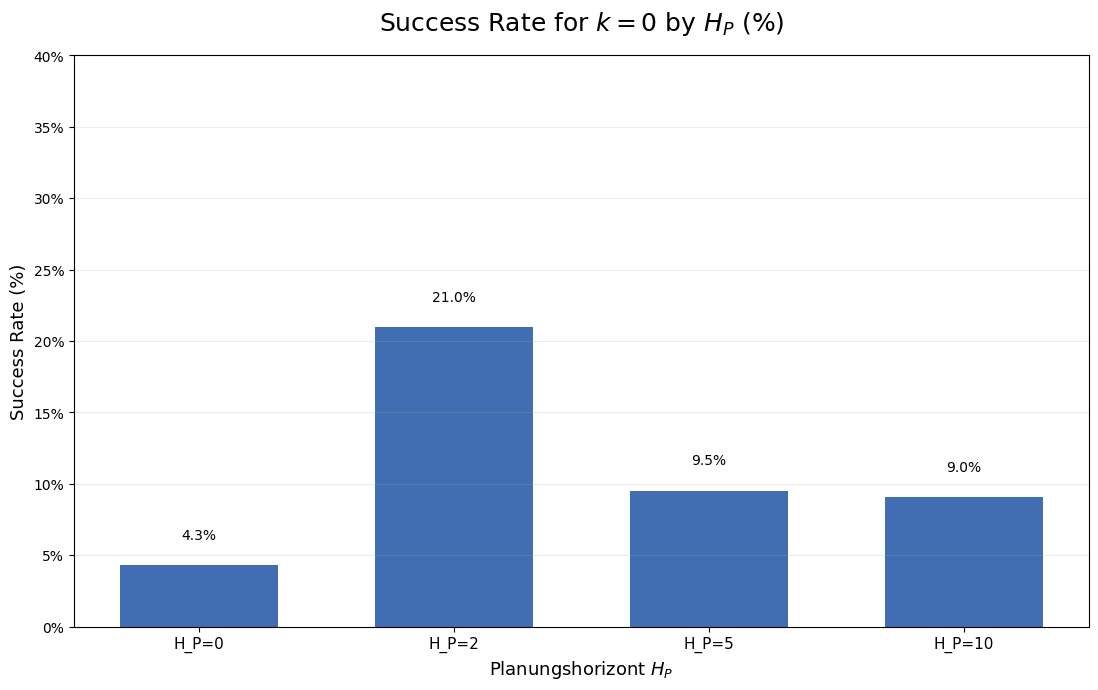

Wrote thesis_results_output/figures/fig_12b_success_k0_by_h_bars_pct.png


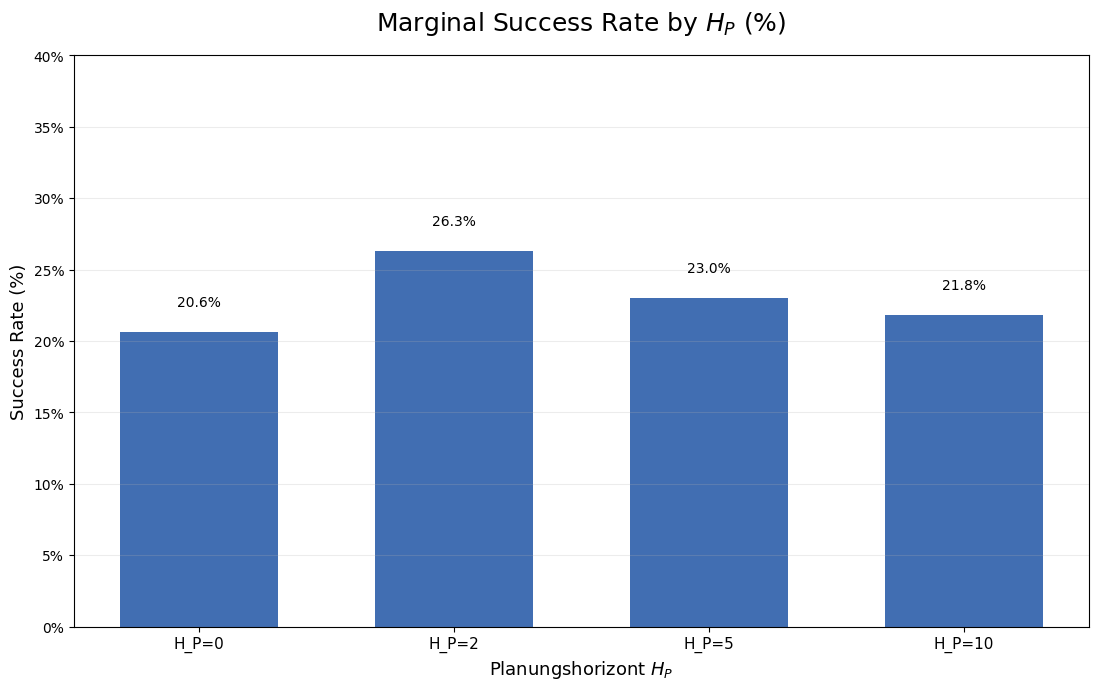

Wrote thesis_results_output/figures/fig_13_success_marginal_h_bars_pct.png


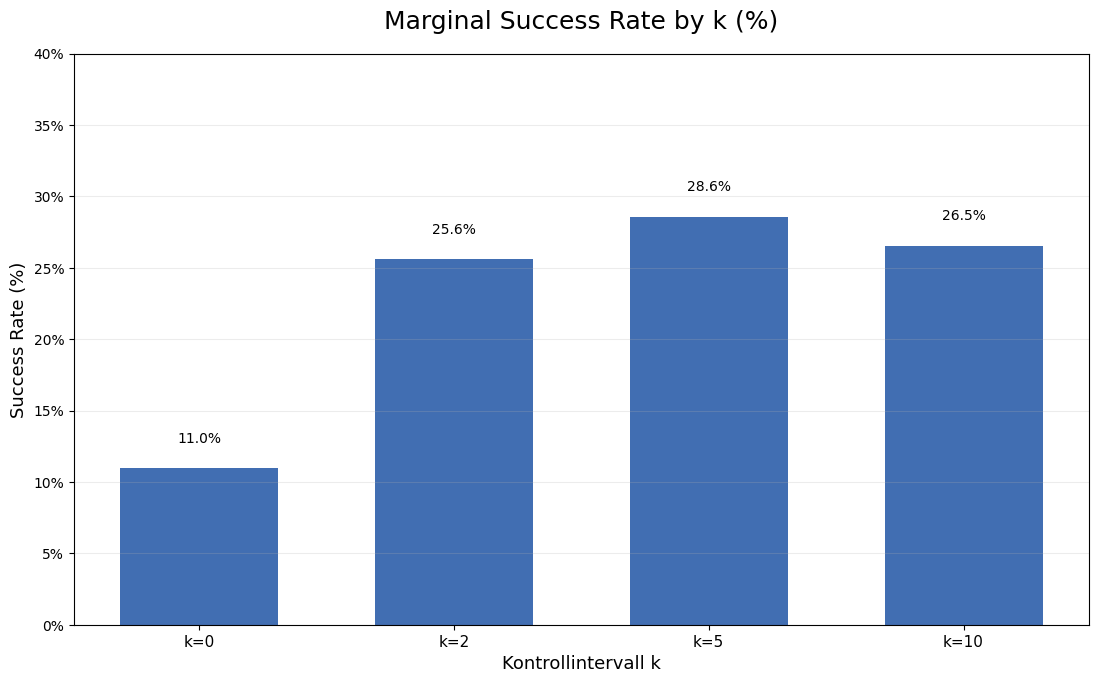

Wrote thesis_results_output/figures/fig_14_success_marginal_k_bars_pct.png


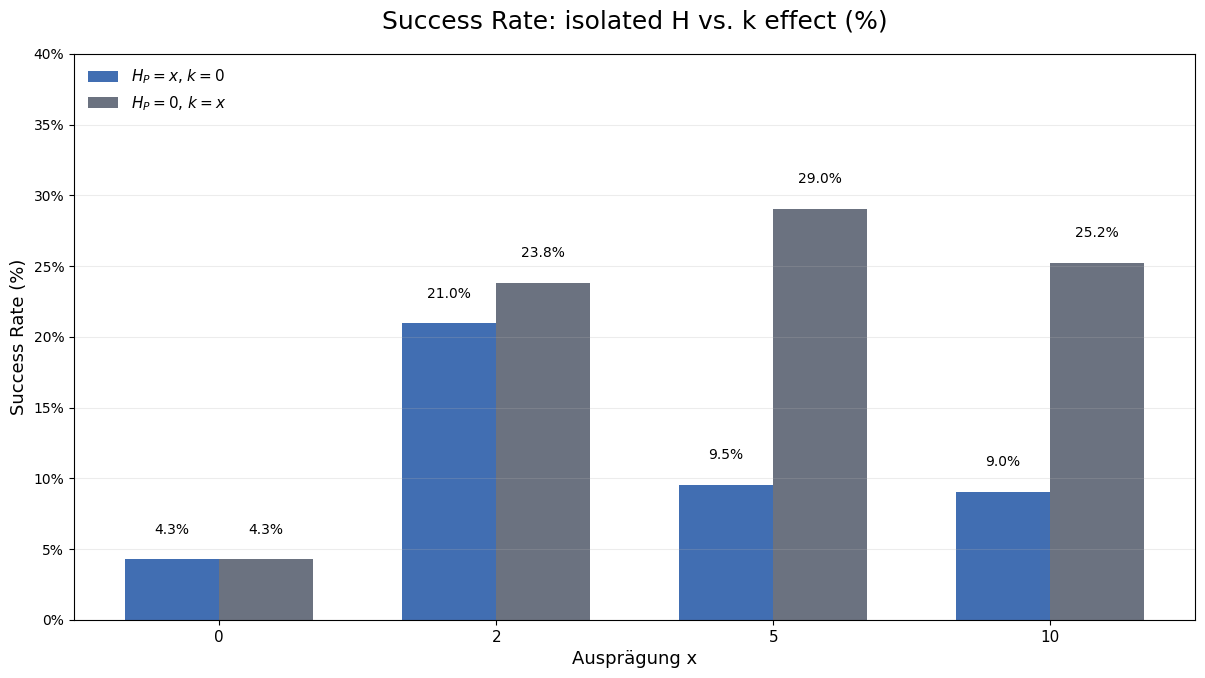

Wrote thesis_results_output/figures/fig_15_success_axis_zero_comparison_bars_pct.png


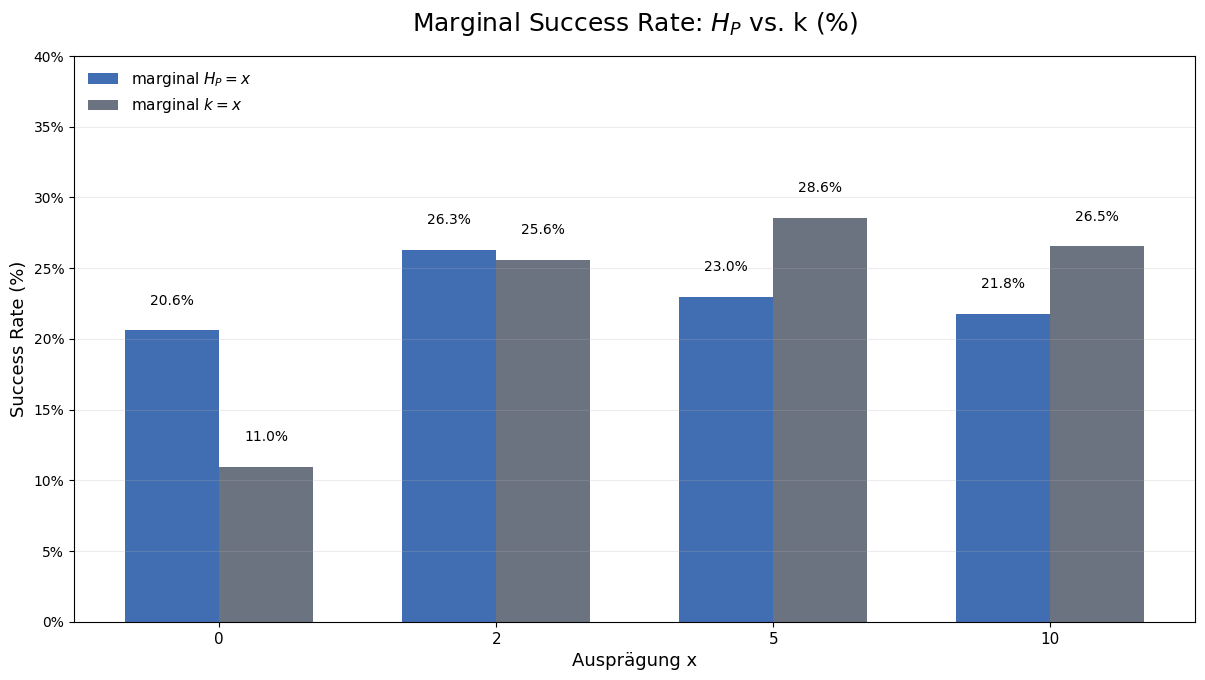

Wrote thesis_results_output/figures/fig_16_success_marginal_h_vs_k_comparison_bars_pct.png


In [19]:
from matplotlib.ticker import FuncFormatter

SUCCESS_PERCENT_FIGURES = True

WRONG_SUCCESS_PERCENT_FIGURES = [
    "fig_11c_additive_utility_hk_bars_pct.png",
    "fig_11d_standard_utility_hk_bars_pct.png",
    "fig_12e_additive_utility_h0_by_k_bars_pct.png",
    "fig_12f_standard_utility_h0_by_k_bars_pct.png",
    "fig_12g_standard_utility_k0_by_h_bars_pct.png",
    "fig_12h_additive_utility_k0_by_h_bars_pct.png",
    "fig_13c_additive_utility_marginal_h_bars_pct.png",
    "fig_13d_standard_utility_marginal_h_bars_pct.png",
    "fig_14c_additive_utility_marginal_k_bars_pct.png",
    "fig_14d_standard_utility_marginal_k_bars_pct.png",
    "fig_15b_standard_utility_axis_zero_comparison_bars_pct.png",
    "fig_16b_standard_utility_marginal_h_vs_k_comparison_bars_pct.png",
]
WRONG_SUCCESS_PERCENT_TABLES = [
    "additive_utility_hk_by_scenario_pct.csv",
    "additive_utility_h0_by_k_scenario_pct.csv",
    "additive_utility_k0_by_h_scenario_pct.csv",
    "additive_utility_marginal_h_scenario_pct.csv",
    "additive_utility_marginal_k_scenario_pct.csv",
    "standard_utility_hk_pct.csv",
    "standard_utility_h0_by_k_pct.csv",
    "standard_utility_k0_by_h_pct.csv",
    "standard_utility_marginal_h_pct.csv",
    "standard_utility_marginal_k_pct.csv",
    "standard_utility_axis_zero_comparison_pct.csv",
    "standard_utility_marginal_h_vs_k_comparison_pct.csv",
]
SUCCESS_OUTPUT_TABLES = [
    "success_hk_pct.csv",
    "success_h0_by_k_pct.csv",
    "success_k0_by_h_pct.csv",
    "success_marginal_h_pct.csv",
    "success_marginal_k_pct.csv",
    "success_axis_zero_comparison_pct.csv",
    "success_marginal_h_vs_k_comparison_pct.csv",
    "comparison_metrics_hk.csv",
    "comparison_metrics_h0_by_k.csv",
    "comparison_metrics_k0_by_h.csv",
    "comparison_metrics_hk.tex",
    "comparison_metrics_h0_by_k.tex",
    "comparison_metrics_k0_by_h.tex",
]
SUCCESS_OUTPUT_FIGURES = [
    "fig_11_success_hk_bars_pct.png",
    "fig_12_success_h0_by_k_bars_pct.png",
    "fig_12b_success_k0_by_h_bars_pct.png",
    "fig_13_success_marginal_h_bars_pct.png",
    "fig_14_success_marginal_k_bars_pct.png",
    "fig_15_success_axis_zero_comparison_bars_pct.png",
    "fig_16_success_marginal_h_vs_k_comparison_bars_pct.png",
]
for name in WRONG_SUCCESS_PERCENT_FIGURES + SUCCESS_OUTPUT_FIGURES:
    (FIG_DIR / name).unlink(missing_ok=True)
for name in WRONG_SUCCESS_PERCENT_TABLES + SUCCESS_OUTPUT_TABLES:
    (TABLE_DIR / name).unlink(missing_ok=True)

def success_percent_table(df: pd.DataFrame, *, subset_cols: list[str]) -> pd.DataFrame:
    cols = subset_cols + ["runs", "success_rate"]
    optional_cols = ["avg_tokens", "avg_runtime_s", "avg_cost_usd", "hk", "h", "k", "h_label", "k_label"]
    keep = []
    for col in cols + optional_cols:
        if col in df.columns and col not in keep:
            keep.append(col)
    out = df[keep].drop_duplicates(subset=subset_cols).copy()
    out["success_rate_pct"] = out["success_rate"] * 100
    return out

def write_table_replace(df: pd.DataFrame, output_name: str) -> pd.DataFrame:
    path = TABLE_DIR / output_name
    path.unlink(missing_ok=True)
    df.to_csv(path, index=False)
    return df

def success_percent_ylim(*frames: pd.DataFrame) -> tuple[float, float]:
    values = pd.concat([frame["success_rate_pct"] for frame in frames], ignore_index=True).dropna()
    ymax = float(values.max())
    upper = np.ceil((ymax + 3.0) / 10.0) * 10.0
    return 0.0, max(10.0, upper)

def format_metrics_table(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    out = df.copy()
    out = out.rename(columns={
        label_col: "Ausprägung",
        "success_rate_pct": "Success Rate (%)",
        "utility": "Utility",
        "avg_tokens": "Tokens Mittelwert",
        "avg_cost_usd": "Kosten Mittelwert USD",
        "avg_runtime_s": "Laufzeit Mittelwert s",
    })
    keep = ["Ausprägung", "Success Rate (%)", "Utility", "Tokens Mittelwert", "Kosten Mittelwert USD", "Laufzeit Mittelwert s"]
    out = out[keep].copy()
    out["Success Rate (%)"] = out["Success Rate (%)"].round(1)
    out["Utility"] = out["Utility"].round(4)
    out["Tokens Mittelwert"] = out["Tokens Mittelwert"].round(0).astype(int)
    out["Kosten Mittelwert USD"] = out["Kosten Mittelwert USD"].round(4)
    out["Laufzeit Mittelwert s"] = out["Laufzeit Mittelwert s"].round(1)
    return out

def tex_metrics_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Success Rate in \\\\%"] = out["Success Rate (%)"].map(lambda value: f"{value:.1f}".replace(".", ","))
    out["Utility"] = out["Utility"].map(lambda value: f"{value:.4f}".replace(".", ","))
    out["Tokens Mittelwert"] = out["Tokens Mittelwert"].map(lambda value: f"{int(value):,}".replace(",", r"\\,"))
    out["Kosten Mittelwert USD"] = out["Kosten Mittelwert USD"].map(lambda value: f"{value:.4f}".replace(".", ","))
    out["Laufzeit Mittelwert s"] = out["Laufzeit Mittelwert s"].map(lambda value: f"{value:.1f}".replace(".", ","))
    out = out.drop(columns=["Success Rate (%)"])
    return out[["Ausprägung", "Success Rate in \\\\%", "Utility", "Tokens Mittelwert", "Kosten Mittelwert USD", "Laufzeit Mittelwert s"]]

def write_metrics_table(df: pd.DataFrame, *, label_col: str, csv_name: str, tex_name: str, caption: str, label: str) -> pd.DataFrame:
    table = format_metrics_table(df, label_col)
    (TABLE_DIR / csv_name).unlink(missing_ok=True)
    (TABLE_DIR / tex_name).unlink(missing_ok=True)
    table.to_csv(TABLE_DIR / csv_name, index=False)
    tex_metrics_table(table).to_latex(
        TABLE_DIR / tex_name,
        index=False,
        escape=False,
        caption=caption,
        label=label,
    )
    return table

def plot_success_percent_bars(
    df: pd.DataFrame,
    *,
    x_col: str,
    order: list[str],
    title: str,
    xlabel: str,
    output_name: str,
    ylim: tuple[float, float],
    color: str = "#416eb2",
    fig_width: float | None = None,
    fig_height: float = 8.4,
) -> None:
    if plt is None:
        return
    plot_df = df.set_index(x_col).reindex(order).reset_index()
    fig, ax = plt.subplots(figsize=(fig_width or max(11.0, len(order) * 0.95), fig_height))
    x = np.arange(len(plot_df))
    values = plot_df["success_rate_pct"].values
    bars = ax.bar(x, values, color=color, width=0.62)
    for bar, value in zip(bars, values):
        if pd.isna(value):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1.6,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            rotation=90 if len(order) > 8 else 0,
            clip_on=False,
        )
    ax.set_title(title, fontsize=18, pad=18)
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel("Success Rate (%)", fontsize=13)
    ax.set_ylim(*ylim)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=38 if len(order) > 6 else 0, ha="right" if len(order) > 6 else "center", fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax.grid(axis="y", alpha=0.24)
    fig.subplots_adjust(left=0.09, right=0.98, top=0.84, bottom=0.25 if len(order) > 6 else 0.16)
    out_path = FIG_DIR / output_name
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path.relative_to(ROOT)}")

def plot_success_percent_comparison(df: pd.DataFrame, *, series_order: list[str], colors: dict[str, str], title: str, output_name: str) -> None:
    if plt is None:
        return
    x_values = sorted(df["value"].unique())
    x = np.arange(len(x_values))
    width = 0.34
    label_map = {
        "H_P=x, k=0": r"$H_P=x$, $k=0$",
        "H_P=0, k=x": r"$H_P=0$, $k=x$",
        "marginal H_P=x": r"marginal $H_P=x$",
        "marginal k=x": r"marginal $k=x$",
    }
    fig, ax = plt.subplots(figsize=(12.6, 8.2))
    for i, series in enumerate(series_order):
        sub = df[df["series"].eq(series)].set_index("value").reindex(x_values)
        values = sub["success_rate_pct"].values
        bars = ax.bar(x + (i - 0.5) * width, values, width=width, color=colors[series], label=label_map.get(series, series))
        for bar, value in zip(bars, values):
            if pd.isna(value):
                continue
            ax.text(bar.get_x() + bar.get_width() / 2, value + 1.6, f"{value:.1f}%", ha="center", va="bottom", fontsize=10, clip_on=False)
    ax.set_title(title, fontsize=18, pad=18)
    ax.set_xlabel("Ausprägung x", fontsize=13)
    ax.set_ylabel("Success Rate (%)", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([str(value) for value in x_values], fontsize=11)
    ax.set_ylim(*success_percent_ylim(df))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax.grid(axis="y", alpha=0.24)
    ax.legend(frameon=False, loc="upper left", fontsize=11)
    fig.subplots_adjust(left=0.09, right=0.98, top=0.84, bottom=0.15)
    out_path = FIG_DIR / output_name
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path.relative_to(ROOT)}")

success_hk_pct = write_table_replace(success_percent_table(standard_hk_utility, subset_cols=["hk"]), "success_hk_pct.csv")
success_h0_by_k_pct = write_table_replace(success_percent_table(standard_h0_utility, subset_cols=["k_label"]), "success_h0_by_k_pct.csv")
success_k0_by_h_pct = write_table_replace(success_percent_table(standard_k0_utility, subset_cols=["h_label"]), "success_k0_by_h_pct.csv")
success_marginal_h_pct = write_table_replace(success_percent_table(standard_marginal_h_utility, subset_cols=["h_label"]), "success_marginal_h_pct.csv")
success_marginal_k_pct = write_table_replace(success_percent_table(standard_marginal_k_utility, subset_cols=["k_label"]), "success_marginal_k_pct.csv")

comparison_metrics_hk = write_metrics_table(standard_hk_utility.assign(success_rate_pct=standard_hk_utility["success_rate"] * 100), label_col="hk", csv_name="comparison_metrics_hk.csv", tex_name="comparison_metrics_hk.tex", caption="Metriken aller H/k-Kombinationen bei Standardgewichtung", label="tab:comparison-metrics-hk")
comparison_metrics_h0_by_k = write_metrics_table(standard_h0_utility.assign(success_rate_pct=standard_h0_utility["success_rate"] * 100), label_col="k_label", csv_name="comparison_metrics_h0_by_k.csv", tex_name="comparison_metrics_h0_by_k.tex", caption="Metriken fuer $H_P=0$ nach Kontrollintervall k", label="tab:comparison-metrics-h0-by-k")
comparison_metrics_k0_by_h = write_metrics_table(standard_k0_utility.assign(success_rate_pct=standard_k0_utility["success_rate"] * 100), label_col="h_label", csv_name="comparison_metrics_k0_by_h.csv", tex_name="comparison_metrics_k0_by_h.tex", caption="Metriken fuer $k=0$ nach Planungshorizont $H_P$", label="tab:comparison-metrics-k0-by-h")

success_axis_zero_comparison_pct = standard_axis_zero_comparison.copy()
if "success_rate" not in success_axis_zero_comparison_pct.columns:
    hk_success_lookup = standard_hk_utility.drop_duplicates("hk").set_index("hk")["success_rate"]
    success_axis_zero_comparison_pct["success_rate"] = success_axis_zero_comparison_pct["hk"].map(hk_success_lookup)
success_axis_zero_comparison_pct = success_axis_zero_comparison_pct.drop(columns=["utility"], errors="ignore")
success_axis_zero_comparison_pct["success_rate_pct"] = success_axis_zero_comparison_pct["success_rate"] * 100
success_axis_zero_comparison_pct = write_table_replace(success_axis_zero_comparison_pct, "success_axis_zero_comparison_pct.csv")

success_marginal_h_vs_k_comparison_pct = standard_marginal_h_vs_k_comparison.copy().drop(columns=["utility"], errors="ignore")
success_marginal_h_vs_k_comparison_pct["success_rate_pct"] = success_marginal_h_vs_k_comparison_pct["success_rate"] * 100
success_marginal_h_vs_k_comparison_pct = write_table_replace(success_marginal_h_vs_k_comparison_pct, "success_marginal_h_vs_k_comparison_pct.csv")

hk_order = [f"h{h}/k{k}" for h in [0, 2, 5, 10] for k in [0, 2, 5, 10]]
success_common_ylim = success_percent_ylim(success_hk_pct, success_h0_by_k_pct, success_k0_by_h_pct, success_marginal_h_pct, success_marginal_k_pct)
plot_success_percent_bars(success_hk_pct, x_col="hk", order=hk_order, title="Success Rate by H/k Treatment (%)", xlabel="H/k Treatment", output_name="fig_11_success_hk_bars_pct.png", ylim=success_common_ylim, fig_width=16.0, fig_height=8.0)
plot_success_percent_bars(success_h0_by_k_pct, x_col="k_label", order=[f"k={k}" for k in [0, 2, 5, 10]], title="Success Rate for $H_P=0$ by k (%)", xlabel="Kontrollintervall k", output_name="fig_12_success_h0_by_k_bars_pct.png", ylim=success_common_ylim, fig_width=11.4)
plot_success_percent_bars(success_k0_by_h_pct, x_col="h_label", order=[f"H_P={h}" for h in [0, 2, 5, 10]], title="Success Rate for $k=0$ by $H_P$ (%)", xlabel="Planungshorizont $H_P$", output_name="fig_12b_success_k0_by_h_bars_pct.png", ylim=success_common_ylim, fig_width=11.4)
plot_success_percent_bars(success_marginal_h_pct, x_col="h_label", order=[f"H_P={h}" for h in [0, 2, 5, 10]], title="Marginal Success Rate by $H_P$ (%)", xlabel="Planungshorizont $H_P$", output_name="fig_13_success_marginal_h_bars_pct.png", ylim=success_common_ylim, fig_width=11.4)
plot_success_percent_bars(success_marginal_k_pct, x_col="k_label", order=[f"k={k}" for k in [0, 2, 5, 10]], title="Marginal Success Rate by k (%)", xlabel="Kontrollintervall k", output_name="fig_14_success_marginal_k_bars_pct.png", ylim=success_common_ylim, fig_width=11.4)
plot_success_percent_comparison(success_axis_zero_comparison_pct, series_order=["H_P=x, k=0", "H_P=0, k=x"], colors={"H_P=x, k=0": "#416eb2", "H_P=0, k=x": "#6B7280"}, title="Success Rate: isolated H vs. k effect (%)", output_name="fig_15_success_axis_zero_comparison_bars_pct.png")
plot_success_percent_comparison(success_marginal_h_vs_k_comparison_pct, series_order=["marginal H_P=x", "marginal k=x"], colors={"marginal H_P=x": "#416eb2", "marginal k=x": "#6B7280"}, title="Marginal Success Rate: $H_P$ vs. k (%)", output_name="fig_16_success_marginal_h_vs_k_comparison_bars_pct.png")




In [20]:
UTILITY_TABLE_SUCCESS_REORDER = True

UTILITY_CSV_TABLES = [
    "additive_utility_hk_by_scenario.csv",
    "additive_utility_h0_by_k_scenario.csv",
    "additive_utility_k0_by_h_scenario.csv",
    "additive_utility_marginal_h_scenario.csv",
    "additive_utility_marginal_k_scenario.csv",
    "standard_utility_hk.csv",
    "standard_utility_h0_by_k.csv",
    "standard_utility_k0_by_h.csv",
    "standard_utility_marginal_h.csv",
    "standard_utility_marginal_k.csv",
    "standard_utility_axis_zero_comparison.csv",
    "standard_utility_marginal_h_vs_k_comparison.csv",
    "configuration_group_utility_standard.csv",
    "configuration_group_utility_by_scenario.csv",
]

def move_column_before(columns: list[str], column: str, before: str) -> list[str]:
    columns = [col for col in columns if col != column]
    if before in columns:
        columns.insert(columns.index(before), column)
    else:
        columns.append(column)
    return columns

def place_success_columns(path: Path) -> None:
    df = pd.read_csv(path)
    columns = list(df.columns)
    if "success_rate" in columns and "utility" in columns:
        columns = move_column_before(columns, "success_rate", "utility")
    if "success_rate_pct" in columns and "utility_pct" in columns:
        columns = move_column_before(columns, "success_rate_pct", "utility_pct")
    df.loc[:, columns].to_csv(path, index=False)

for table_name in UTILITY_CSV_TABLES:
    table_path = TABLE_DIR / table_name
    if table_path.exists():
        place_success_columns(table_path)



## Utility-Normalisierung: global und site-intern

Fuer websiteuebergreifende Vergleiche wird global normalisiert. Fuer die Aussage `bestes Treatment je Site` ist zusaetzlich eine site-interne Normalisierung sinnvoll, weil dort das relativ beste Treatment innerhalb derselben Webanwendung bestimmt wird.



In [21]:
def compute_utility_table(df: pd.DataFrame, *, group_cols: list[str], resource_agg: str = "mean", normalisation_scope: list[str] | None = None, weights: dict[str, float] | None = None) -> pd.DataFrame:
    weights = weights or WEIGHT_SCENARIOS["accuracy_first"]
    aggfunc = "median" if resource_agg == "median" else "mean"
    grouped = (
        df.groupby(group_cols)
        .agg(
            runs=("task_id", "count"),
            success_rate=("success", "mean"),
            tokens=("total_tokens", aggfunc),
            runtime_s=("total_runtime_s", aggfunc),
        )
        .reset_index()
    )
    if normalisation_scope:
        grouped["T_norm"] = grouped.groupby(normalisation_scope)["tokens"].transform(minmax_norm)
        grouped["runtime_norm"] = grouped.groupby(normalisation_scope)["runtime_s"].transform(minmax_norm)
    else:
        grouped["T_norm"] = minmax_norm(grouped["tokens"])
        grouped["runtime_norm"] = minmax_norm(grouped["runtime_s"])
    grouped["utility"] = weights["alpha"] * grouped["success_rate"] - weights["beta"] * grouped["T_norm"] - weights["gamma"] * grouped["runtime_norm"]
    grouped["resource_agg"] = resource_agg
    grouped["normalisation"] = "site_internal" if normalisation_scope else "global"
    return grouped

global_mean_utility = compute_utility_table(cost_df, group_cols=["h", "k", "hk"], resource_agg="mean", normalisation_scope=None)
global_median_utility = compute_utility_table(cost_df, group_cols=["h", "k", "hk"], resource_agg="median", normalisation_scope=None)
site_internal_utility = compute_utility_table(cost_df, group_cols=["site", "h", "k", "hk"], resource_agg="mean", normalisation_scope=["site"])

site_winners = (
    site_internal_utility.sort_values(["site", "utility"], ascending=[True, False])
    .groupby("site")
    .head(1)
    [["site", "hk", "success_rate", "tokens", "runtime_s", "utility", "normalisation"]]
)
display(site_winners)

median_vs_mean = pd.concat([
    global_mean_utility.assign(view="mean_resources"),
    global_median_utility.assign(view="median_resources"),
], ignore_index=True)
median_vs_mean_rank = median_vs_mean.sort_values(["view", "utility"], ascending=[True, False]).copy()
median_vs_mean_rank["rank"] = median_vs_mean_rank.groupby("view")["utility"].rank(method="first", ascending=False).astype(int)
display(median_vs_mean_rank[median_vs_mean_rank["rank"].le(5)].sort_values(["view", "rank"]))

cost_per_success = (
    cost_df.groupby(["h", "k", "hk"])
    .agg(total_cost_usd=("estimated_token_cost_usd", "sum"), successes=("success", "sum"), runs=("task_id", "count"))
    .reset_index()
    .sort_values(["h", "k"])
)
cost_per_success["cost_per_official_success_usd"] = cost_per_success["total_cost_usd"] / cost_per_success["successes"].replace(0, np.nan)
display(cost_per_success)

display(Markdown(
    """
**Textbaustein.** Globale Normalisierung erlaubt den direkten Vergleich der Treatments ueber alle Sites hinweg. Site-interne Normalisierung beantwortet dagegen die andere Frage, welches Treatment innerhalb einer Webanwendung relativ am besten abschneidet. Beide Varianten duerfen nicht vermischt werden, weil sie unterschiedliche Vergleichsraeume verwenden.
""".strip()
))


,site,hk,success_rate,tokens,runtime_s,utility,normalisation
10,gitlab,h5/k5,0.280702,9.672887e+05,255.044632,0.166061,site_internal
26,reddit,h5/k5,0.690476,5.733083e+05,175.504476,0.558648,site_internal
33,shopping,h0/k2,0.214286,4.404166e+05,228.505446,0.147094,site_internal
53,shopping_admin,h2/k2,0.236364,1.141033e+06,494.358491,0.112727,site_internal


,h,k,hk,runs,success_rate,tokens,runtime_s,T_norm,runtime_norm,utility,resource_agg,normalisation,view,rank
10,5,5,h5/k5,210,0.314286,876820.400000,317.841767,0.974232,0.885617,0.189865,mean,global,mean_resources,1
2,0,5,h0/k5,210,0.290476,774737.604762,279.663910,0.844010,0.754361,0.181510,mean,global,mean_resources,2
15,10,10,h10/k10,210,0.290476,823853.447619,297.993248,0.906664,0.817378,0.175226,mean,global,mean_resources,3
6,2,5,h2/k5,210,0.285714,883059.023810,304.713890,0.982190,0.840483,0.166009,mean,global,mean_resources,4
7,2,10,h2/k10,210,0.276190,884474.395238,306.793290,0.983995,0.847632,0.156990,mean,global,mean_resources,5
18,0,5,h0/k5,210,0.290476,534458.000000,176.179000,0.554866,0.643133,0.201529,median,global,median_resources,1
26,5,5,h5/k5,210,0.314286,735761.000000,231.888500,0.816660,0.915332,0.196258,median,global,median_resources,2
25,5,2,h5/k2,210,0.266667,445979.000000,168.469000,0.439799,0.605462,0.187737,median,global,median_resources,3
17,0,2,h0/k2,210,0.238095,320319.000000,111.728500,0.276378,0.328225,0.184056,median,global,median_resources,4
29,10,2,h10/k2,210,0.238095,359214.500000,132.170000,0.326962,0.428103,0.176532,median,global,median_resources,5


,h,k,hk,total_cost_usd,successes,runs,cost_per_official_success_usd
0,0,0,h0/k0,3.648226,9,210,0.405358
1,0,2,h0/k2,21.786119,50,210,0.435722
2,0,5,h0/k5,24.883497,61,210,0.407926
3,0,10,h0/k10,26.061387,53,210,0.491724
4,2,0,h2/k0,24.631636,44,210,0.559810
5,2,2,h2/k2,28.888963,59,210,0.489643
6,2,5,h2/k5,28.350003,60,210,0.472500
7,2,10,h2/k10,28.353059,58,210,0.488846
8,5,0,h5/k0,6.939646,20,210,0.346982
9,5,2,h5/k2,26.258308,56,210,0.468898


**Textbaustein.** Globale Normalisierung erlaubt den direkten Vergleich der Treatments ueber alle Sites hinweg. Site-interne Normalisierung beantwortet dagegen die andere Frage, welches Treatment innerhalb einer Webanwendung relativ am besten abschneidet. Beide Varianten duerfen nicht vermischt werden, weil sie unterschiedliche Vergleichsraeume verwenden.

## Robustheits- und Sensitivitaetsanalysen

Die Sensitivitaetsanalyse prueft, ob die Treatment-Empfehlung von einer einzelnen Gewichtungswahl abhaengt. Dazu wird ein Gitter ueber `beta` und `gamma` betrachtet, waehrend `alpha = 1 - beta - gamma` gilt und Genauigkeit weiterhin dominant bleibt.



,winner_hk,weight_points,mean_winner_utility,win_share_pct
2,h5/k5,136,0.189865,38.746439
1,h10/k0,126,0.067463,35.897436
0,h0/k5,89,0.095062,25.356125


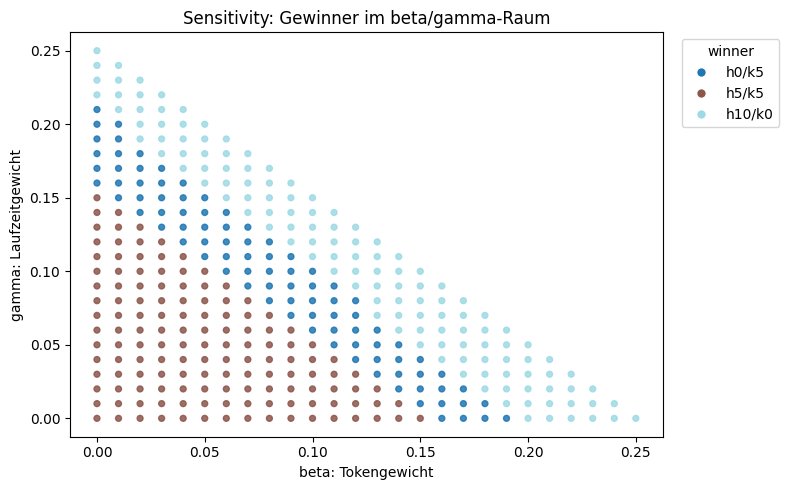

**Textbaustein.** Im betrachteten Gewichtungsraum gewinnt `h5/k5` in `38.7%` der Gewichtungspunkte.
Je staerker sich ein Treatment ueber viele Gewichtungen hinweg durchsetzt, desto robuster ist die Utility-basierte Empfehlung gegenueber plausiblen Annahmen ueber Token- und Laufzeitkosten.

In [22]:
def make_weight_grid(beta_max: float = 0.25, gamma_max: float = 0.25, step: float = 0.01, min_alpha: float = 0.75) -> pd.DataFrame:
    rows = []
    for beta in np.round(np.arange(0.0, beta_max + step / 2, step), 6):
        for gamma in np.round(np.arange(0.0, gamma_max + step / 2, step), 6):
            alpha = round(1.0 - beta - gamma, 6)
            if alpha >= min_alpha and alpha >= 0 and beta >= 0 and gamma >= 0:
                rows.append({"alpha": alpha, "beta": beta, "gamma": gamma})
    return pd.DataFrame(rows)

weights = make_weight_grid()
sensitivity_rows = []
for idx, weight in weights.iterrows():
    tmp = utility_base.copy()
    tmp["utility"] = (
        weight["alpha"] * tmp["success_rate"]
        - weight["beta"] * tmp["T_norm"]
        - weight["gamma"] * tmp["runtime_norm"]
    )
    winner = tmp.sort_values("utility", ascending=False).iloc[0]
    sensitivity_rows.append({
        "weight_id": idx,
        "alpha": weight["alpha"],
        "beta": weight["beta"],
        "gamma": weight["gamma"],
        "winner_hk": winner["hk"],
        "winner_utility": winner["utility"],
        "winner_success_rate": winner["success_rate"],
        "winner_tokens": winner["avg_tokens"],
        "winner_runtime_s": winner["avg_runtime_s"],
    })
sensitivity_df = pd.DataFrame(sensitivity_rows)

winner_share = (
    sensitivity_df.groupby("winner_hk")
    .agg(weight_points=("weight_id", "count"), mean_winner_utility=("winner_utility", "mean"))
    .reset_index()
    .sort_values("weight_points", ascending=False)
)
winner_share["win_share_pct"] = winner_share["weight_points"] / len(sensitivity_df) * 100
display(winner_share)

if plt is not None and not sensitivity_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    codes = {hk: i for i, hk in enumerate(sorted(sensitivity_df["winner_hk"].unique(), key=hk_sort_key))}
    scatter = ax.scatter(
        sensitivity_df["beta"],
        sensitivity_df["gamma"],
        c=sensitivity_df["winner_hk"].map(codes),
        cmap="tab20",
        s=18,
        alpha=0.85,
    )
    ax.set_title("Sensitivity: Gewinner im beta/gamma-Raum")
    ax.set_xlabel("beta: Tokengewicht")
    ax.set_ylabel("gamma: Laufzeitgewicht")
    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=scatter.cmap(scatter.norm(code)), markersize=7, label=hk) for hk, code in codes.items()]
    ax.legend(handles=handles, title="winner", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

stable = winner_share.iloc[0]
display(Markdown(
    f"""
**Textbaustein.** Im betrachteten Gewichtungsraum gewinnt `{stable['winner_hk']}` in `{stable['win_share_pct']:.1f}%` der Gewichtungspunkte.
Je staerker sich ein Treatment ueber viele Gewichtungen hinweg durchsetzt, desto robuster ist die Utility-basierte Empfehlung gegenueber plausiblen Annahmen ueber Token- und Laufzeitkosten.
""".strip()
))


## Sensitivitaet gegenueber alternativen Zielerfuellungsschwellen

Die offizielle WebArena-Verified-Success Ratesdefinition bleibt eine binaere 100-Prozent-Bewertung durch den Benchmark-Evaluator. Die folgenden Schwellen auf Basis von `near_miss_score` sind ausschliesslich diagnostische Zielerfuellungsgrade und duerfen nicht mit official success gleichgesetzt werden.



In [23]:
diagnostic_thresholds = [0.9, 0.8, 0.7]

official_baseline = (
    summary_df.groupby(["h", "k", "hk"])
    .agg(
        runs=("task_id", "count"),
        official_success_rate=("success", "mean"),
        official_success_count=("success", "sum"),
    )
    .reset_index()
    .sort_values(["h", "k"])
)
official_baseline["threshold"] = "official_100"
official_baseline["official_success_rate_pct"] = official_baseline["official_success_rate"] * 100
display(official_baseline)

if "near_miss_score" in summary_df.columns:
    threshold_rows = []
    for threshold in diagnostic_thresholds:
        reached = summary_df["near_miss_score"].fillna(0).ge(threshold)
        tmp = summary_df.assign(_diagnostic_reached=reached)
        by_hk_threshold = (
            tmp.groupby(["h", "k", "hk"])
            .agg(
                runs=("task_id", "count"),
                official_success_rate=("success", "mean"),
                diagnostic_reached_rate=("_diagnostic_reached", "mean"),
                diagnostic_reached_count=("_diagnostic_reached", "sum"),
            )
            .reset_index()
        )
        by_hk_threshold["threshold"] = threshold
        threshold_rows.append(by_hk_threshold)
    target_threshold_sensitivity = pd.concat(threshold_rows, ignore_index=True).sort_values(["threshold", "h", "k"], ascending=[False, True, True])
    target_threshold_sensitivity["official_success_rate_pct"] = target_threshold_sensitivity["official_success_rate"] * 100
    target_threshold_sensitivity["diagnostic_reached_rate_pct"] = target_threshold_sensitivity["diagnostic_reached_rate"] * 100
    display(target_threshold_sensitivity)

    threshold_overview = (
        target_threshold_sensitivity.groupby("threshold")
        .agg(
            mean_official_success_rate=("official_success_rate", "mean"),
            mean_diagnostic_reached_rate=("diagnostic_reached_rate", "mean"),
            best_diagnostic_rate=("diagnostic_reached_rate", "max"),
        )
        .reset_index()
        .sort_values("threshold", ascending=False)
    )
    official_overview = pd.DataFrame([{
        "threshold": "official_100",
        "mean_official_success_rate": official_baseline["official_success_rate"].mean(),
        "mean_diagnostic_reached_rate": np.nan,
        "best_diagnostic_rate": np.nan,
    }])
    threshold_overview = pd.concat([official_overview, threshold_overview], ignore_index=True)
    threshold_overview["mean_official_success_rate_pct"] = threshold_overview["mean_official_success_rate"] * 100
    threshold_overview["mean_diagnostic_reached_rate_pct"] = threshold_overview["mean_diagnostic_reached_rate"] * 100
    threshold_overview["best_diagnostic_rate_pct"] = threshold_overview["best_diagnostic_rate"] * 100
    display(threshold_overview)

    display(Markdown(
        """
**Textbaustein.** Die 100-Prozent-Baseline verwendet ausschliesslich das offizielle Feld `official_success`. Die Schwellen von 90, 80 und 70 Prozent sind dagegen diagnostische Zielerfuellungsgrade auf Basis von `near_miss_score` und werden nicht als alternative offizielle Success Rate interpretiert.
""".strip()
    ))
else:
    target_threshold_sensitivity = pd.DataFrame()
    display(Markdown("`near_miss_score` ist nicht vorhanden; die diagnostische Schwellenanalyse kann fuer diese Summary nicht berechnet werden."))


,h,k,hk,runs,official_success_rate,official_success_count,threshold,official_success_rate_pct
0,0,0,h0/k0,210,0.042857,9,official_100,4.285714
1,0,2,h0/k2,210,0.238095,50,official_100,23.809524
2,0,5,h0/k5,210,0.290476,61,official_100,29.047619
3,0,10,h0/k10,210,0.252381,53,official_100,25.238095
4,2,0,h2/k0,210,0.209524,44,official_100,20.952381
5,2,2,h2/k2,210,0.280952,59,official_100,28.095238
6,2,5,h2/k5,210,0.285714,60,official_100,28.571429
7,2,10,h2/k10,210,0.276190,58,official_100,27.619048
8,5,0,h5/k0,210,0.095238,20,official_100,9.523810
9,5,2,h5/k2,210,0.266667,56,official_100,26.666667


,h,k,hk,runs,official_success_rate,diagnostic_reached_rate,diagnostic_reached_count,threshold,official_success_rate_pct,diagnostic_reached_rate_pct
0,0,0,h0/k0,210,0.042857,0.066667,14,0.9,4.285714,6.666667
1,0,2,h0/k2,210,0.238095,0.280952,59,0.9,23.809524,28.095238
2,0,5,h0/k5,210,0.290476,0.342857,72,0.9,29.047619,34.285714
3,0,10,h0/k10,210,0.252381,0.295238,62,0.9,25.238095,29.523810
4,2,0,h2/k0,210,0.209524,0.252381,53,0.9,20.952381,25.238095
5,2,2,h2/k2,210,0.280952,0.319048,67,0.9,28.095238,31.904762
6,2,5,h2/k5,210,0.285714,0.309524,65,0.9,28.571429,30.952381
7,2,10,h2/k10,210,0.276190,0.295238,62,0.9,27.619048,29.523810
8,5,0,h5/k0,210,0.095238,0.157143,33,0.9,9.523810,15.714286
9,5,2,h5/k2,210,0.266667,0.328571,69,0.9,26.666667,32.857143


,threshold,mean_official_success_rate,mean_diagnostic_reached_rate,best_diagnostic_rate,mean_official_success_rate_pct,mean_diagnostic_reached_rate_pct,best_diagnostic_rate_pct
0,official_100,0.229167,NaN,NaN,22.916667,NaN,NaN
1,0.9,0.229167,0.268452,0.347619,22.916667,26.845238,34.761905
2,0.8,0.229167,0.288095,0.366667,22.916667,28.809524,36.666667
3,0.7,0.229167,0.372024,0.447619,22.916667,37.202381,44.761905


**Textbaustein.** Die 100-Prozent-Baseline verwendet ausschliesslich das offizielle Feld `official_success`. Die Schwellen von 90, 80 und 70 Prozent sind dagegen diagnostische Zielerfuellungsgrade auf Basis von `near_miss_score` und werden nicht als alternative offizielle Success Rate interpretiert.

## Konfigurationsgruppen inklusive Utility

Diese Zusatzanalyse fasst die 16 Treatments in vier konzeptionelle Konfigurationsgruppen zusammen und berechnet dafuer neben Success Rate, Tokenverbrauch, Laufzeit und Modellaufrufen auch die additive Utility. Die Ressourcenwerte werden fuer diese gruppierte Sicht ueber die vier Konfigurationsgruppen normalisiert; die lange Tabelle weist zusaetzlich die verwendeten Persona-Gewichte $\alpha$, $\beta$ und $\gamma$ aus.



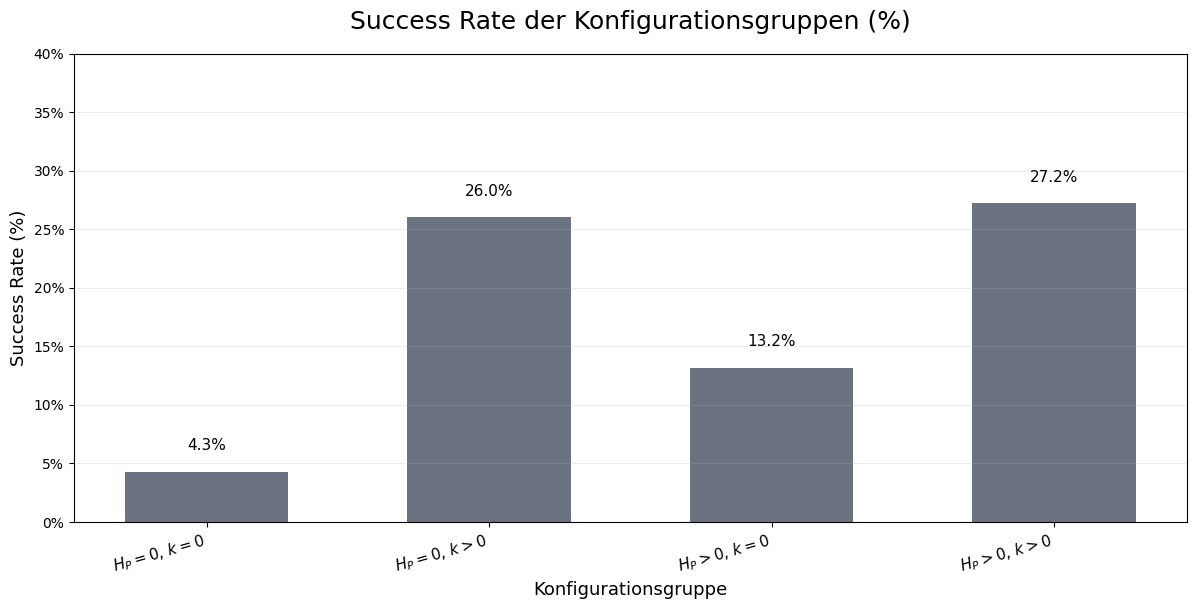

Wrote thesis_results_output/figures/fig_configuration_group_utility_standard_bars.png


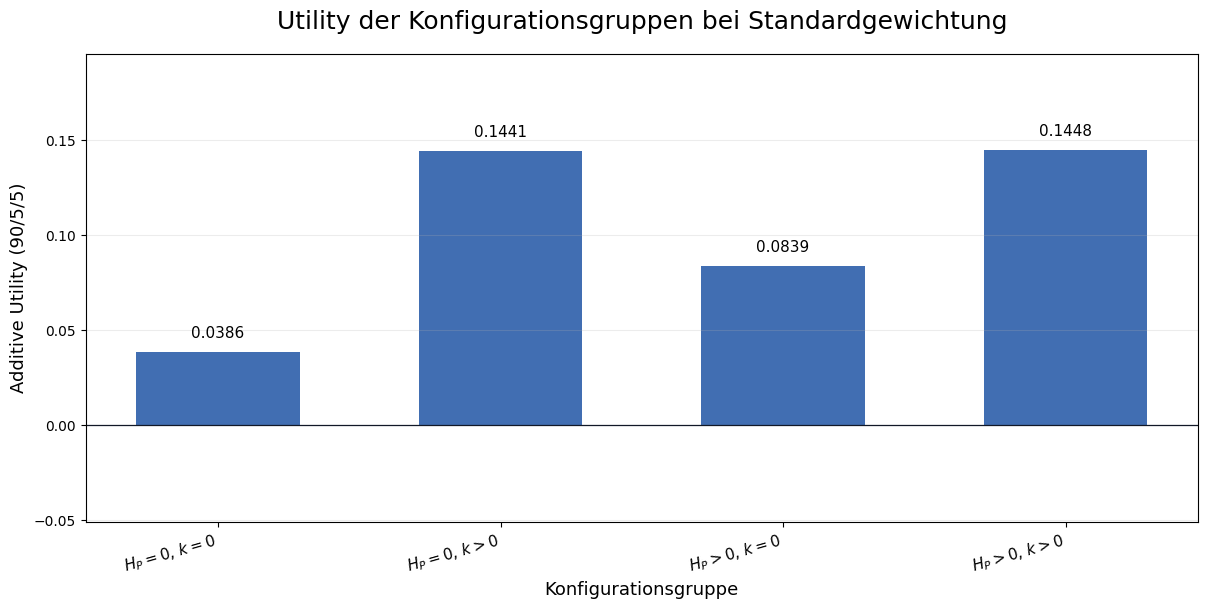

Wrote thesis_results_output/figures/fig_configuration_group_utility_only_standard_bars.png


,configuration,configuration_label,success_rate,success_rate_pct,runs,tasks,treatments
0,"H_P=0, k=0","$H_P=0$, $k=0$",0.042857,4.285714,210,210,1
1,"H_P=0, k>0","$H_P=0$, $k>0$",0.260317,26.031746,630,210,3
2,"H_P>0, k=0","$H_P>0$, $k=0$",0.131746,13.174603,630,210,3
3,"H_P>0, k>0","$H_P>0$, $k>0$",0.271958,27.195767,1890,210,9


,Konfigurationsgruppe,Success Rate (%),Utility,Tokens Mittelwert,Kosten Mittelwert USD,Laufzeit Mittelwert s,Rang
0,"$H_P=0$, $k=0$",4.3,0.0386,113107,0.0174,60.2,4
1,"$H_P=0$, $k>0$",26.0,0.1441,754254,0.1154,287.0,2
2,"$H_P>0$, $k=0$",13.2,0.0839,366254,0.0563,145.2,3
3,"$H_P>0$, $k>0$",27.2,0.1448,842377,0.1289,305.6,1


,scenario,alpha,beta,gamma,configuration,runs,tasks,treatments,success_rate_pct,mean_tokens,mean_cost_usd,mean_runtime_s,utility,rank
0,accuracy_first,0.90,0.050,0.050,"H_P=0, k=0",210,210,1,4.285714,113106.528571,0.017373,60.247648,0.038571,4
1,accuracy_first,0.90,0.050,0.050,"H_P=0, k>0",630,210,3,26.031746,754253.731746,0.115446,287.020313,0.144119,2
2,accuracy_first,0.90,0.050,0.050,"H_P>0, k=0",630,210,3,13.174603,366253.536508,0.056290,145.214211,0.083902,3
3,accuracy_first,0.90,0.050,0.050,"H_P>0, k>0",1890,210,9,27.195767,842377.377249,0.128930,305.624798,0.144762,1
4,balanced_efficiency,0.75,0.125,0.125,"H_P=0, k=0",210,210,1,4.285714,113106.528571,0.017373,60.247648,0.032143,1
5,balanced_efficiency,0.75,0.125,0.125,"H_P=0, k>0",630,210,3,26.031746,754253.731746,0.115446,287.020313,-0.030180,3
6,balanced_efficiency,0.75,0.125,0.125,"H_P>0, k=0",630,210,3,13.174603,366253.536508,0.056290,145.214211,0.012135,2
7,balanced_efficiency,0.75,0.125,0.125,"H_P>0, k>0",1890,210,9,27.195767,842377.377249,0.128930,305.624798,-0.046032,4
8,cost_sensitive,0.80,0.150,0.050,"H_P=0, k=0",210,210,1,4.285714,113106.528571,0.017373,60.247648,0.034286,2
9,cost_sensitive,0.80,0.150,0.050,"H_P=0, k>0",630,210,3,26.031746,754253.731746,0.115446,287.020313,0.030171,3


**Textbaustein.** Auf Ebene der vier Konfigurationsgruppen erreicht je nach Gewichtungsprofil die folgende Gruppe die hoechste Utility: `accuracy_first`: `H_P>0, k>0` mit U=0.1448; `balanced_efficiency`: `H_P=0, k=0` mit U=0.0321; `cost_sensitive`: `H_P>0, k=0` mit U=0.0360; `time_sensitive`: `H_P>0, k=0` mit U=0.0361. Die Success Rates werden separat in `configuration_group_success_only.tex` ausgewiesen.

In [24]:
def hk_configuration_group(row: pd.Series) -> str:
    if int(row["h"]) == 0 and int(row["k"]) == 0:
        return "H_P=0, k=0"
    if int(row["h"]) == 0 and int(row["k"]) > 0:
        return "H_P=0, k>0"
    if int(row["h"]) > 0 and int(row["k"]) == 0:
        return "H_P>0, k=0"
    return "H_P>0, k>0"

configuration_order = ["H_P=0, k=0", "H_P=0, k>0", "H_P>0, k=0", "H_P>0, k>0"]
configuration_latex_labels = {
    "H_P=0, k=0": r"$H_P=0$, $k=0$",
    "H_P=0, k>0": r"$H_P=0$, $k>0$",
    "H_P>0, k=0": r"$H_P>0$, $k=0$",
    "H_P>0, k>0": r"$H_P>0$, $k>0$",
}
configuration_meaning = {
    "H_P=0, k=0": "Full-Horizon, keine planmaessige Pruefung",
    "H_P=0, k>0": "Full-Horizon mit planmaessiger Pruefung",
    "H_P>0, k=0": "begrenzter Planungshorizont ohne planmaessige Pruefung",
    "H_P>0, k>0": "begrenzter Planungshorizont mit planmaessiger Pruefung",
}

CONFIGURATION_OUTPUTS = [
    "configuration_group_success_only.csv",
    "configuration_group_success_only.tex",
    "configuration_group_utility_standard.csv",
    "configuration_group_utility_by_scenario.csv",
    "configuration_group_metrics_standard.csv",
    "configuration_group_metrics_standard.tex",
    "configuration_utility_summary.tex",
    "configuration_utility_by_persona.tex",
]
for name in CONFIGURATION_OUTPUTS:
    (TABLE_DIR / name).unlink(missing_ok=True)
for name in ["fig_configuration_group_utility_standard_bars.png", "fig_configuration_group_utility_only_standard_bars.png"]:
    (FIG_DIR / name).unlink(missing_ok=True)

configuration_groups = cost_df.assign(configuration=cost_df.apply(hk_configuration_group, axis=1))
configuration_base = (
    configuration_groups.groupby("configuration", dropna=False)
    .agg(
        runs=("task_id", "count"),
        tasks=("task_id", "nunique"),
        treatments=("hk", "nunique"),
        success_rate=("success", "mean"),
        mean_tokens=("total_tokens", "mean"),
        median_tokens=("total_tokens", "median"),
        mean_runtime_s=("total_runtime_s", "mean"),
        median_runtime_s=("total_runtime_s", "median"),
        mean_planner_calls=("planner_calls", "mean"),
        mean_executor_calls=("executor_calls", "mean"),
        mean_runtime_replans=("runtime_replans", "mean"),
        mean_cost_usd=("estimated_token_cost_usd", "mean"),
    )
    .reindex(configuration_order)
    .reset_index()
)
configuration_base["Bedeutung"] = configuration_base["configuration"].map(configuration_meaning)
configuration_base["success_rate_pct"] = configuration_base["success_rate"] * 100
configuration_base["T_norm"] = minmax_norm(configuration_base["mean_tokens"])
configuration_base["runtime_norm"] = minmax_norm(configuration_base["mean_runtime_s"])

configuration_utility_rows = []
for scenario, weights in WEIGHT_SCENARIOS.items():
    tmp = configuration_base.copy()
    tmp["scenario"] = scenario
    tmp["alpha"] = weights["alpha"]
    tmp["beta"] = weights["beta"]
    tmp["gamma"] = weights["gamma"]
    tmp["utility"] = tmp["alpha"] * tmp["success_rate"] - tmp["beta"] * tmp["T_norm"] - tmp["gamma"] * tmp["runtime_norm"]
    tmp["rank"] = tmp["utility"].rank(method="min", ascending=False).astype(int)
    configuration_utility_rows.append(tmp)

configuration_utility_long = pd.concat(configuration_utility_rows, ignore_index=True)
configuration_utility_long["configuration"] = pd.Categorical(configuration_utility_long["configuration"], categories=configuration_order, ordered=True)
configuration_utility_long = configuration_utility_long.sort_values(["scenario", "configuration"]).reset_index(drop=True)
configuration_utility_long["configuration"] = configuration_utility_long["configuration"].astype(str)

configuration_success_only = configuration_base[["configuration", "success_rate", "success_rate_pct", "runs", "tasks", "treatments"]].copy()
configuration_success_only["configuration_label"] = configuration_success_only["configuration"].map(configuration_latex_labels)
configuration_success_only = configuration_success_only[["configuration", "configuration_label", "success_rate", "success_rate_pct", "runs", "tasks", "treatments"]]

configuration_utility_standard = configuration_utility_long[configuration_utility_long["scenario"].eq("accuracy_first")][[
    "configuration", "success_rate", "success_rate_pct", "mean_tokens", "mean_cost_usd", "mean_runtime_s", "utility", "rank"
]].copy()
configuration_utility_standard["configuration_label"] = configuration_utility_standard["configuration"].map(configuration_latex_labels)
configuration_utility_standard = configuration_utility_standard[["configuration", "configuration_label", "success_rate", "success_rate_pct", "mean_tokens", "mean_cost_usd", "mean_runtime_s", "utility", "rank"]]

configuration_metrics_standard = configuration_utility_standard[["configuration_label", "success_rate_pct", "utility", "mean_tokens", "mean_cost_usd", "mean_runtime_s", "rank"]].copy()
configuration_metrics_standard.columns = ["Konfigurationsgruppe", "Success Rate (%)", "Utility", "Tokens Mittelwert", "Kosten Mittelwert USD", "Laufzeit Mittelwert s", "Rang"]
configuration_metrics_standard["Success Rate (%)"] = configuration_metrics_standard["Success Rate (%)"].round(1)
configuration_metrics_standard["Utility"] = configuration_metrics_standard["Utility"].round(4)
configuration_metrics_standard["Tokens Mittelwert"] = configuration_metrics_standard["Tokens Mittelwert"].round(0).astype(int)
configuration_metrics_standard["Kosten Mittelwert USD"] = configuration_metrics_standard["Kosten Mittelwert USD"].round(4)
configuration_metrics_standard["Laufzeit Mittelwert s"] = configuration_metrics_standard["Laufzeit Mittelwert s"].round(1)

configuration_success_only.to_csv(TABLE_DIR / "configuration_group_success_only.csv", index=False)
configuration_utility_standard.to_csv(TABLE_DIR / "configuration_group_utility_standard.csv", index=False)
configuration_utility_long.to_csv(TABLE_DIR / "configuration_group_utility_by_scenario.csv", index=False)
configuration_metrics_standard.to_csv(TABLE_DIR / "configuration_group_metrics_standard.csv", index=False)

configuration_metrics_tex = configuration_metrics_standard.copy()
configuration_metrics_tex["Success Rate in \\\\%"] = configuration_metrics_tex["Success Rate (%)"].map(lambda value: f"{value:.1f}".replace(".", ","))
configuration_metrics_tex["Utility"] = configuration_metrics_tex["Utility"].map(lambda value: f"{value:.4f}".replace(".", ","))
configuration_metrics_tex["Tokens Mittelwert"] = configuration_metrics_tex["Tokens Mittelwert"].map(lambda value: f"{int(value):,}".replace(",", r"\\,"))
configuration_metrics_tex["Kosten Mittelwert USD"] = configuration_metrics_tex["Kosten Mittelwert USD"].map(lambda value: f"{value:.4f}".replace(".", ","))
configuration_metrics_tex["Laufzeit Mittelwert s"] = configuration_metrics_tex["Laufzeit Mittelwert s"].map(lambda value: f"{value:.1f}".replace(".", ","))
configuration_metrics_tex = configuration_metrics_tex.drop(columns=["Success Rate (%)"])
configuration_metrics_tex = configuration_metrics_tex[["Konfigurationsgruppe", "Success Rate in \\\\%", "Utility", "Tokens Mittelwert", "Kosten Mittelwert USD", "Laufzeit Mittelwert s", "Rang"]]
configuration_metrics_tex.to_latex(
    TABLE_DIR / "configuration_group_metrics_standard.tex",
    index=False,
    escape=False,
    caption="Metriken der uebergeordneten Konfigurationsgruppen bei Standardgewichtung",
    label="tab:configuration-group-metrics-standard",
)

configuration_success_latex = configuration_success_only.copy()
configuration_success_latex["Success Rate in \\\\%"] = configuration_success_latex["success_rate_pct"].map(lambda value: f"{value:.1f}".replace(".", ","))
configuration_success_latex = configuration_success_latex[["configuration_label", "Success Rate in \\\\%"]]
configuration_success_latex.columns = ["Konfigurationsgruppe", "Success Rate in \\\\%"]
configuration_success_latex.to_latex(
    TABLE_DIR / "configuration_group_success_only.tex",
    index=False,
    escape=False,
    column_format="lr",
    caption="Success Rates der uebergeordneten Konfigurationsgruppen",
    label="tab:configuration-group-success-only",
)

def plot_configuration_success_rate(df: pd.DataFrame) -> None:
    if plt is None:
        return
    plot_df = df.set_index("configuration").reindex(configuration_order).reset_index()
    fig, ax = plt.subplots(figsize=(12.5, 7.2))
    labels = [configuration_latex_labels[value] for value in plot_df["configuration"]]
    x = np.arange(len(plot_df))
    values = plot_df["success_rate_pct"].values
    bars = ax.bar(x, values, color="#6B7280", width=0.58)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 1.6, f"{value:.1f}%", ha="center", va="bottom", fontsize=11, clip_on=False)
    ax.set_title("Success Rate der Konfigurationsgruppen (%)", fontsize=18, pad=18)
    ax.set_xlabel("Konfigurationsgruppe", fontsize=13)
    ax.set_ylabel("Success Rate (%)", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=16, ha="right", fontsize=11, clip_on=False)
    ax.set_ylim(0, max(40.0, np.ceil((float(np.nanmax(values)) + 3.0) / 10.0) * 10.0))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax.grid(axis="y", alpha=0.24)
    fig.subplots_adjust(left=0.09, right=0.98, top=0.87, bottom=0.22)
    out_path = FIG_DIR / "fig_configuration_group_utility_standard_bars.png"
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path.relative_to(ROOT)}")

def plot_configuration_utility_only(df: pd.DataFrame) -> None:
    if plt is None:
        return
    plot_df = df.set_index("configuration").reindex(configuration_order).reset_index()
    fig, ax = plt.subplots(figsize=(12.5, 7.2))
    labels = [configuration_latex_labels[value] for value in plot_df["configuration"]]
    x = np.arange(len(plot_df))
    values = plot_df["utility"].values
    bars = ax.bar(x, values, color="#416eb2", width=0.58)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.006, f"{value:.4f}", ha="center", va="bottom", fontsize=11, clip_on=False)
    ax.axhline(0, color="#111827", linewidth=0.9)
    ax.set_title("Utility der Konfigurationsgruppen bei Standardgewichtung", fontsize=18, pad=18)
    ax.set_xlabel("Konfigurationsgruppe", fontsize=13)
    ax.set_ylabel("Additive Utility (90/5/5)", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=16, ha="right", fontsize=11, clip_on=False)
    ymin = min(0.0, float(np.nanmin(values)))
    ymax = float(np.nanmax(values))
    pad = max(0.02, (ymax - ymin) * 0.35)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.grid(axis="y", alpha=0.24)
    fig.subplots_adjust(left=0.09, right=0.98, top=0.87, bottom=0.22)
    out_path = FIG_DIR / "fig_configuration_group_utility_only_standard_bars.png"
    fig.savefig(out_path, dpi=240, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out_path.relative_to(ROOT)}")

plot_configuration_success_rate(configuration_utility_standard)
plot_configuration_utility_only(configuration_utility_standard)

display(configuration_success_only)
display(configuration_metrics_standard)
display(configuration_utility_long[["scenario", "alpha", "beta", "gamma", "configuration", "runs", "tasks", "treatments", "success_rate_pct", "mean_tokens", "mean_cost_usd", "mean_runtime_s", "utility", "rank"]])

best_config_utility = configuration_utility_long.sort_values(["scenario", "utility"], ascending=[True, False]).groupby("scenario", as_index=False).head(1)[["scenario", "configuration", "utility", "success_rate_pct", "mean_tokens", "mean_runtime_s", "mean_cost_usd"]]
display(Markdown(
    "**Textbaustein.** Auf Ebene der vier Konfigurationsgruppen erreicht je nach Gewichtungsprofil die folgende Gruppe die hoechste Utility: "
    + "; ".join(f"`{row.scenario}`: `{row.configuration}` mit U={row.utility:.4f}" for row in best_config_utility.itertuples(index=False))
    + ". Die Success Rates werden separat in `configuration_group_success_only.tex` ausgewiesen."
))




## Zusammenfassung der Ergebnisse

Diese Zelle erzeugt eine kompakte Ergebniszusammenfassung aus den wichtigsten Tabellen. Sie ist als Rohmaterial gedacht und sollte vor der Uebernahme in die Arbeit sprachlich geglaettet und mit konkreten Abbildungsverweisen versehen werden.



In [25]:
summary_points = []
summary_points.append(f"Die Analyse umfasst {len(summary_df):,} Runs, {summary_df['task_id'].nunique()} Tasks und {summary_df['hk'].nunique()} H/k-Treatments.")
summary_points.append(f"Fuer {int(task_treatment_counts['complete_16_treatments'].sum())} von {len(task_treatment_counts)} Tasks liegen alle Treatments vor.")
summary_points.append(f"Die globale Success Rate betraegt {summary_df['success'].mean():.1%}.")
summary_points.append(f"Bestes Treatment nach Success Rate: {best_success['hk']} mit {best_success['success_rate']:.1%}.")
summary_points.append(f"Marginal beste Auspraegungen: H={int(best_h['h'])} mit {best_h['success_rate']:.1%}; k={int(best_k['k'])} mit {best_k['success_rate']:.1%}.")
min_cost_success_rate = float(hk_success.loc[hk_success["hk"].eq(min_cost["hk"]), "success_rate"].iloc[0])
summary_points.append(f"Das Treatment {min_cost['hk']} weist mit durchschnittlich {min_cost['mean_cost_usd']:.4f} USD den geringsten geschaetzten Kostenaufwand pro Lauf auf; zugleich erreicht es {min_cost_success_rate:.1%} Success Rate.")
summary_points.append(f"Kuerzeste mediane Laufzeit: {fastest['hk']} mit {fastest['median_runtime_s']:.1f} Sekunden.")
summary_points.append(f"Hoechste Replanning-Rate: {max_replan['hk']} mit {max_replan['replan_rate']:.1%}; hoechste Replanning-Quote je Pruefung: {best_replan_per_check['hk']} mit {best_replan_per_check['replanning_quote_je_pruefung']:.1%}.")
summary_points.append(f"Robustester Utility-Gewinner im Sensitivitaetsgitter: {stable['winner_hk']} mit {stable['win_share_pct']:.1f}% Gewinneranteil.")
if 'target_threshold_sensitivity' in globals() and not target_threshold_sensitivity.empty:
    summary_points.append("Die alternativen Zielerfuellungsschwellen werden nur diagnostisch ausgewertet und nicht als offizielle Success Rate interpretiert.")

display(Markdown("\n".join(f"- {point}" for point in summary_points)))

display(Markdown(
    """
**EXP-RQ1.** Berichte hier die beobachteten Unterschiede in Success Rate, Kontrollverhalten, Replanning und Fehlerprofilen.  
**EXP-RQ2.** Berichte hier die Unterschiede in Tokenverbrauch, Laufzeit, Modellaufrufen, Kostenproxy und Utility.
""".strip()
))


- Die Analyse umfasst 3,360 Runs, 210 Tasks und 16 H/k-Treatments.
- Fuer 210 von 210 Tasks liegen alle Treatments vor.
- Die globale Success Rate betraegt 22.9%.
- Bestes Treatment nach Success Rate: h5/k5 mit 31.4%.
- Marginal beste Auspraegungen: H=2 mit 26.3%; k=5 mit 28.6%.
- Das Treatment h0/k0 weist mit durchschnittlich 0.0174 USD den geringsten geschaetzten Kostenaufwand pro Lauf auf; zugleich erreicht es 4.3% Success Rate.
- Kuerzeste mediane Laufzeit: h0/k0 mit 44.6 Sekunden.
- Hoechste Replanning-Rate: h5/k2 mit 85.7%; hoechste Replanning-Quote je Pruefung: h2/k0 mit 87.2%.
- Robustester Utility-Gewinner im Sensitivitaetsgitter: h5/k5 mit 38.7% Gewinneranteil.
- Die alternativen Zielerfuellungsschwellen werden nur diagnostisch ausgewertet und nicht als offizielle Success Rate interpretiert.

**EXP-RQ1.** Berichte hier die beobachteten Unterschiede in Success Rate, Kontrollverhalten, Replanning und Fehlerprofilen.  
**EXP-RQ2.** Berichte hier die Unterschiede in Tokenverbrauch, Laufzeit, Modellaufrufen, Kostenproxy und Utility.

# Diskussion und Limitationen

Die folgenden Punkte strukturieren die Diskussion. Sie sind bewusst als auswertungsnahe Stichpunkte formuliert und sollten im finalen Text mit den konkreten Tabellen und Abbildungen aus den vorherigen Abschnitten verbunden werden.

## Diskussion

- **Trade-off zwischen Success Rate und Effizienz.** Die H/k-Treatments unterscheiden sich nicht nur in ihrer Success Rate, sondern auch in Tokenverbrauch, Laufzeit und Anzahl der Modellaufrufe. Die Utility-Auswertung macht diesen Zielkonflikt explizit.
- **Rolle von H.** Ein groesserer Planungshorizont kann strategische Kohärenz erhoehen, kann aber auch dazu fuehren, dass ein laengerer Plan auf veralteten Annahmen basiert, wenn sich die Webseite anders entwickelt als erwartet.
- **Rolle von k.** Ein kleineres Kontrollintervall erzeugt haeufigere Prozesspruefungen und kann Fehler frueher sichtbar machen, verursacht aber potenziell mehr Replanning-Overhead. Ein groesseres `k` laesst den Executor laenger autonom handeln, kann aber No-Progress-Phasen spaeter erkennen.
- **Runtime-Verifier vs. Official Evaluator.** Der Runtime-Verifier ist ein Steuerungsinstrument waehrend des Laufs. Die finale Success Ratesbewertung bleibt dem offiziellen WebArena-Verified-Evaluator vorbehalten.
- **Task- und Site-Abhaengigkeit.** Unterschiedliche Sites und Tasktypen koennen unterschiedliche Fehlerprofile erzeugen. Deshalb sind globale Ergebnisse zusammen mit stratifizierten Tabellen nach Site, Tasktyp und, ergaenzend, Intent-Laenge zu interpretieren.
- **Prozessmetriken als Erklaerungsebene.** Replans, Loops, No-Progress-Signale und Failure Classes erklaeren, warum ein Treatment gut oder schlecht abschneidet, sind aber keine eigenstaendige Success Ratesmetrik.

## Limitationen

- **Kostenproxy statt echter Abrechnung.** Die API-Kosten basieren auf Tokenzaehlern und Preisannahmen. Sie eignen sich fuer relative Vergleiche, ersetzen aber keine abrechnungsgenaue Cloud-Kostenanalyse.
- **Wall-Clock Time ist umgebungsabhaengig.** Laufzeit enthaelt Modelllatenz, lokale Browser-/Docker-Latenz, Site-Zustand und Netzwerk-/Proxy-Effekte. Sie ist deshalb reproduzierbar zu protokollieren, aber nicht vollstaendig modellisoliert.
- **Evaluator- und Benchmark-Spezifika.** WebArena-Verified bewertet ueber konkrete Agentenantworten und Netzwerkereignisse. Near-Misses oder semantisch plausible Zwischenergebnisse koennen offiziell fehlschlagen, wenn sie nicht exakt dem Evaluatorvertrag entsprechen.
- **Taskauswahl.** Die Treatmentmatrix ist fuer die 210 ausgewaehlten Tasks vollstaendig. Die Untersuchung ist jedoch auf Single-Site-Tasks aus vier Webanwendungen beschraenkt; die 48 Multi-Site-Tasks des verwendeten Hard-Subsets wurden nicht beruecksichtigt.
- **Prompt- und Architekturstand.** Die Ergebnisse gelten fuer die dokumentierte v3-Architektur, die verwendeten Prompts, die Google-Vertex-Modellkonfiguration und die aufgezeichnete Codeversion.
- **HTML-/Grounding-Reduktion.** Die Reduktion des DOM/HTML-Kontexts senkt Rauschen und Kosten, kann aber relevante Elemente verlieren, wenn Ranking oder Sichtbarkeitsheuristiken unguenstig greifen.

## Ueberleitung zur finalen Bewertung

Aus den Ergebnissen sollte am Ende nicht nur ein einzelnes bestes Treatment abgeleitet werden. Sinnvoller ist eine differenzierte Bewertung: Welches Treatment maximiert Success Rate, welches minimiert Kosten oder Laufzeit, und welches bleibt unter plausiblen Utility-Gewichtungen robust? Diese Dreiteilung passt direkt zur Ergebnisstruktur aus Success Rate, Effizienzmetriken und Sensitivitaetsanalyse.

